# 🏢 CAPSTONE PROJECT: ALGORITHMIC STAFF PROMOTION PREDICTION — YAKUB TRADING GROUP

---

## Project Background

You have been engaged as the **Lead Data Scientist** by **Abdullah Baba Yakub**, the newly appointed head of **Yakub Trading Group** — a multi-sector Nigerian conglomerate. Following persistent staff concerns about subjectivity and bias in the promotion process, Abdullah has mandated a fully **data-driven approach** to determine which employee characteristics genuinely drive promotion eligibility.

The goal is to replace informal, manager-discretion-heavy promotion decisions with a **transparent, evidence-based system** grounded in measurable performance, training, and structural data.

---

## Target Variable — `Promoted_or_Not`

| Value | Meaning |
|-------|---------|
| `1` | The employee **was promoted** during the review cycle |
| `0` | The employee **was not promoted** |

---

## Project Objectives

To build a **robust binary classification model** that:
1. Identifies the key predictors of staff promotion from structural, performance, and demographic features
2. Provides actionable insights that support **fair, evidence-based promotion decisions**
3. Delivers a **deployable model** that can score and flag promotion-eligible employees in future review cycles

---

## Project Workflow

| Step | Phase | Description |
|------|-------|-------------|
| **1** | Data Loading & Inspection | Load the dataset, inspect structure, dimensions, types, and initial data quality |
| **2** | Data Cleaning & Feature Engineering | Resolve missing values, standardise types, engineer the `Age` feature |
| **3** | Exploratory Data Analysis (EDA) | Univariate, bivariate, and target-focused analysis |
| **4** | Feature Engineering & Preprocessing | Skewness treatment, encoding, scaling, and pipeline construction |
| **5** | Model Building & Evaluation | Train, evaluate, and compare classification models |
| **6** | Business Insights & Recommendations | Translate all findings into actionable decisions for leadership |


---
# STEP 1: DATA LOADING AND INSPECTION

This step lays the foundation for the entire project. Before any analysis or modelling can begin, we must:
1. Load the dataset correctly into the working environment
2. Inspect its structure, dimensions, and data types
3. Identify any data quality issues that will need to be addressed in the cleaning step

Each sub-step feeds directly into the next — what we discover during inspection informs precisely what we clean, and what we clean determines the quality of every analysis that follows.


## 1. Data Loading

### a. Installing and Importing the Necessary Libraries

We begin by importing all libraries required for this project — data handling, visualisation, and machine learning utilities. Importing everything upfront keeps the notebook clean and makes dependencies transparent.


In [1]:
import warnings
warnings.filterwarnings('ignore')          # suppress non-critical warnings for cleaner output

import gdown                               # download datasets directly from Google Drive
import numpy as np                         # numerical computation
import pandas as pd                        # data manipulation and analysis
import matplotlib.pyplot as plt            # static visualisations
import seaborn as sns                      # statistical and aesthetic visualisations
import itertools                           # generate feature pair combinations for pairwise analysis

# ── Machine Learning — Model Selection ───────────────────────────────────────
from sklearn.model_selection import train_test_split

# ── Machine Learning — Preprocessing ─────────────────────────────────────────
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# ── Machine Learning — Classifiers ───────────────────────────────────────────
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

# ── Machine Learning — Evaluation Metrics ────────────────────────────────────
from sklearn.metrics import (
    classification_report, confusion_matrix,
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, roc_curve,
    precision_recall_curve, average_precision_score
)

# ── Display Settings ──────────────────────────────────────────────────────────
pd.set_option('display.max_rows',       None)
pd.set_option('display.max_columns',    None)
pd.set_option('display.max_colwidth',   None)
pd.set_option('display.expand_frame_repr', False)

print("✓ All libraries imported successfully.")

✓ All libraries imported successfully.


### b. Importing the Dataset

The dataset contains **38,312 employee records** across **18 columns** — 17 features and 1 target variable (`Promoted_or_Not`). It is loaded directly from Google Drive using `gdown`. The first column, `EmployeeNo`, is a unique system-generated staff identifier that carries no predictive value and will be removed during cleaning.


In [2]:
# ── Download the dataset from Google Drive and load into a DataFrame ──────────
url_data = "https://drive.google.com/file/d/1ZvMu-zl7FySIFy61rnPOa9EQfkkE8KfK/view?usp=drivesdk"
gdown.download(url_data, "data.csv", fuzzy=True)

df = pd.read_csv("data.csv")              # load CSV into a pandas DataFrame

print("✓ Dataset loaded successfully.")

Downloading...
From: https://drive.google.com/uc?id=1ZvMu-zl7FySIFy61rnPOa9EQfkkE8KfK
To: /content/data.csv
100%|██████████| 5.38M/5.38M [00:00<00:00, 102MB/s]


✓ Dataset loaded successfully.


---
## 2. Data Inspection

Now that the data is loaded, we systematically inspect it across **five dimensions**:

$$\text{Sample Rows} \rightarrow \text{Shape} \rightarrow \text{Structural Summary} \rightarrow \text{Descriptive Statistics} \rightarrow \text{Unique Values}$$

Each inspection step either confirms our expectations or flags something that requires attention in the cleaning phase.


### A. Dataset Overview — Sample Rows

We begin by viewing the first few rows to get an immediate impression of the data values, column naming conventions, and any visible anomalies.


In [3]:
# ── Display the first 5 rows for an initial visual impression ─────────────────
df.head()

,EmployeeNo,Division,Qualification,Gender,Channel_of_Recruitment,Trainings_Attended,Year_of_birth,Last_performance_score,Year_of_recruitment,Targets_met,Previous_Award,Training_score_average,State_Of_Origin,Foreign_schooled,Marital_Status,Past_Disciplinary_Action,Previous_IntraDepartmental_Movement,No_of_previous_employers,Promoted_or_Not
0,YAK/S/00001,Commercial Sales and Marketing,MSc MBA and PhD,Female,Direct Internal process,2,1986,12.5,2011,1,0,41,ANAMBRA,No,Married,No,No,0,0
1,YAK/S/00002,Customer Support and Field Operations,First Degree or HND,Male,Agency and others,2,1991,12.5,2015,0,0,52,ANAMBRA,Yes,Married,No,No,0,0
2,YAK/S/00003,Commercial Sales and Marketing,First Degree or HND,Male,Direct Internal process,2,1987,7.5,2012,0,0,42,KATSINA,Yes,Married,No,No,0,0
3,YAK/S/00004,Commercial Sales and Marketing,First Degree or HND,Male,Agency and others,3,1982,2.5,2009,0,0,42,NIGER,Yes,Single,No,No,1,0
4,YAK/S/00006,Information and Strategy,First Degree or HND,Male,Direct Internal process,3,1990,7.5,2012,0,0,77,AKWA IBOM,Yes,Married,No,No,1,0


### B. Dataset Shape

Confirming the exact number of records and columns before any transformations.


In [4]:
# ── Confirm the number of rows and columns in the dataset ─────────────────────
rows, cols = df.shape

print(f"Dataset Shape : {df.shape}")
print(f"  → {rows:,} rows   (individual employee records)")
print(f"  → {cols} columns  (17 features + 1 target variable)")

Dataset Shape : (38312, 19)
  → 38,312 rows   (individual employee records)
  → 19 columns  (17 features + 1 target variable)


**Insight from shape output:**

The dataset contains **38,312 employee records** and **19 columns** as loaded (including `EmployeeNo`). After dropping the identifier, we have **18 columns** — 17 predictive features and 1 target variable (`Promoted_or_Not`). The low overall promotion rate (~8.5%) already signals a significant **class imbalance** — a critical modelling consideration that will shape our entire evaluation strategy.


### C. Concise Structural Summary — `df.info()`

`df.info()` delivers a column-by-column view of **data types**, **non-null counts**, and **memory usage**. This is our first diagnostic for missing values and data type correctness. We read it top-to-bottom, flagging any column where the non-null count falls below 38,312 (the total number of rows).


In [5]:
# ── Display a concise structural summary of the DataFrame ────────────────────
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 38312 entries, 0 to 38311
Data columns (total 19 columns):
 #   Column                               Non-Null Count  Dtype  
---  ------                               --------------  -----  
 0   EmployeeNo                           38312 non-null  object 
 1   Division                             38312 non-null  object 
 2   Qualification                        36633 non-null  object 
 3   Gender                               38312 non-null  object 
 4   Channel_of_Recruitment               38312 non-null  object 
 5   Trainings_Attended                   38312 non-null  int64  
 6   Year_of_birth                        38312 non-null  int64  
 7   Last_performance_score               38312 non-null  float64
 8   Year_of_recruitment                  38312 non-null  int64  
 9   Targets_met                          38312 non-null  int64  
 10  Previous_Award                       38312 non-null  int64  
 11  Training_score_average      

**Key insights from `df.info()` output:**

- **Total Entries:** 38,312 rows — all columns are complete except one.
- **Total Columns:** 19 as loaded (18 after dropping `EmployeeNo`), spanning three data types:
  - `int64` (8): `Trainings_Attended`, `Year_of_birth`, `Year_of_recruitment`, `Targets_met`, `Previous_Award`, `Training_score_average`, `No_of_previous_employers`, `Promoted_or_Not`
  - `float64` (1): `Last_performance_score`
  - `object` (10): All remaining categorical columns
- **Confirmed Missing Values:** Only `Qualification` has missing data — **1,679 rows (4.38%)** out of 38,312. Every other column is complete. This is our sole cleaning obligation for missing values.
- **`EmployeeNo`** is a unique staff identifier (all 38,312 values are distinct). It holds zero predictive signal and will be dropped immediately in cleaning.


### D. Descriptive Statistics — `df.describe()`

`df.describe()` computes summary statistics for all numerical columns: count, mean, standard deviation, minimum, quartiles, and maximum. This gives us a quantitative first look at the spread, central tendency, and potential skewness of each feature — and lets us sanity-check whether any values fall outside plausible real-world ranges.


In [6]:
# ── Display descriptive statistics for all numerical columns ──────────────────
df.describe()

,Trainings_Attended,Year_of_birth,Last_performance_score,Year_of_recruitment,Targets_met,Previous_Award,Training_score_average,No_of_previous_employers,Promoted_or_Not
count,38312.000000,38312.000000,38312.000000,38312.000000,38312.000000,38312.000000,38312.000000,38312.000000,38312.000000
mean,2.253680,1986.209334,7.698959,2013.139695,0.352996,0.023152,55.366465,1.040953,0.084595
std,0.609443,7.646047,3.744135,4.261451,0.477908,0.150388,13.362741,1.235738,0.278282
min,2.000000,1950.000000,0.000000,1982.000000,0.000000,0.000000,31.000000,0.000000,0.000000
25%,2.000000,1982.000000,5.000000,2012.000000,0.000000,0.000000,43.000000,0.000000,0.000000
50%,2.000000,1988.000000,7.500000,2014.000000,0.000000,0.000000,52.000000,1.000000,0.000000
75%,2.000000,1992.000000,10.000000,2016.000000,1.000000,0.000000,68.000000,1.000000,0.000000
max,11.000000,2001.000000,12.500000,2018.000000,1.000000,1.000000,91.000000,6.000000,1.000000


**Key insights from `df.describe()` output — exact statistics:**

- **`Trainings_Attended`:** Min = 2, Max = 11, Mean = 2.25, Median (50%) = 2. The fact that Q1 = Q2 = Q3 = 2 tells us the vast majority of employees attended exactly 2 trainings — the distribution is **highly right-skewed**, with a long tail of high-training outliers up to 11.
- **`Year_of_birth`:** Spans 1950–2001 (Mean = 1986.21). Employees range from approximately 24 to 75 years of age. We will engineer a more intuitive `Age` feature from this column in Step 2.
- **`Last_performance_score`:** Rated 0–12.5 (Mean = 7.70, Median = 7.50). The mean and median are very close — consistent with a **near-symmetric distribution** around a fair midpoint.
- **`Year_of_recruitment`:** Spans 1982–2018 (Mean = 2013.14). The bulk of recruitment occurred in recent years (the distribution is left-skewed), reflecting strong business growth in the 2010s.
- **`Targets_met`:** Binary (0 or 1). Mean = 0.353 → **35.3%** of employees met their annual targets.
- **`Previous_Award`:** Binary (0 or 1). Mean = 0.023 → only **2.3%** of employees have a previous award — a rare event, but as we will see in EDA, one of the **strongest individual predictors** of promotion.
- **`Training_score_average`:** Range 31–91 (Mean = 55.37). Reasonably distributed with mild positive skew.
- **`No_of_previous_employers`:** Range 0–6 (Mean = 1.04). Most employees held 0–2 prior roles.
- **`Promoted_or_Not`:** Mean = **0.0846** → only **8.46%** of employees were promoted — confirming a severe class imbalance of approximately **10.8:1** (Not Promoted : Promoted). This will directly inform our choice of evaluation metrics.


---
## 3. Data Cleaning

Based on what we discovered in the inspection phase, we now systematically resolve each issue in the following deliberate order:

$$\text{a. Column Names} \rightarrow \text{b. Irrelevant Columns} \rightarrow \text{c. Data Types} \rightarrow \text{d. Unique Values} \rightarrow \text{e. Missing Values} \rightarrow \text{f. Duplicates}$$

This sequence is intentional: standardising column names makes all downstream code consistent; dropping irrelevant columns reduces noise early; verifying data types unlocks the correct operations; inspecting unique values surfaces hidden anomalies; handling missing values ensures completeness; and removing duplicates prevents biased learning.


### a. Standardising Column Names

Inconsistent column names — mixed case, spaces, or special characters — cause hard-to-trace code errors and reduce readability. We standardise all column names in one chained operation:
- Step 1: Convert to **lowercase**
- Step 2: Remove **leading/trailing whitespace**
- Step 3: Replace **internal spaces** with underscores (`_`)


In [7]:
# ── Standardise all column names in one chained operation ────────────────────
df.columns = (
    df.columns
    .str.lower()            # step 1: convert to lowercase
    .str.strip()            # step 2: remove leading/trailing whitespace
    .str.replace(" ", "_")  # step 3: replace internal spaces with underscores
)

print("✓ Column names standardised.")
print("Current columns:", df.columns.tolist())

✓ Column names standardised.
Current columns: ['employeeno', 'division', 'qualification', 'gender', 'channel_of_recruitment', 'trainings_attended', 'year_of_birth', 'last_performance_score', 'year_of_recruitment', 'targets_met', 'previous_award', 'training_score_average', 'state_of_origin', 'foreign_schooled', 'marital_status', 'past_disciplinary_action', 'previous_intradepartmental_movement', 'no_of_previous_employers', 'promoted_or_not']


### b. Dropping Irrelevant Columns

`employeeno` is a unique system-generated staff identifier — every single one of the 38,312 values is distinct. It carries **zero predictive signal** because a model cannot generalise from it; including it in tree-based models could cause overfitting by memorising individual records. We drop it immediately before any further processing.


In [8]:
# ── Drop the employee ID column — it is an identifier, not a predictor ────────
df.drop(columns=['employeeno'], inplace=True)

print("✓ 'employeeno' dropped.")
print(f"  Updated shape   : {df.shape}")
print(f"  Remaining columns ({df.shape[1]}): {df.columns.tolist()}")

✓ 'employeeno' dropped.
  Updated shape   : (38312, 18)
  Remaining columns (18): ['division', 'qualification', 'gender', 'channel_of_recruitment', 'trainings_attended', 'year_of_birth', 'last_performance_score', 'year_of_recruitment', 'targets_met', 'previous_award', 'training_score_average', 'state_of_origin', 'foreign_schooled', 'marital_status', 'past_disciplinary_action', 'previous_intradepartmental_movement', 'no_of_previous_employers', 'promoted_or_not']


### c. Data Type Verification

Correct data types are essential — pandas applies different operations depending on whether a column is numeric (`int64`, `float64`) or categorical (`object`). Misclassified types can silently corrupt aggregations, encoders, and scalers downstream. We inspect types now and confirm they are appropriate before proceeding.


In [9]:
# ── Inspect current data types for all remaining columns ──────────────────────
print("Current data types:")
print(df.dtypes)

Current data types:
division                                object
qualification                           object
gender                                  object
channel_of_recruitment                  object
trainings_attended                       int64
year_of_birth                            int64
last_performance_score                 float64
year_of_recruitment                      int64
targets_met                              int64
previous_award                           int64
training_score_average                   int64
state_of_origin                         object
foreign_schooled                        object
marital_status                          object
past_disciplinary_action                object
previous_intradepartmental_movement     object
no_of_previous_employers                 int64
promoted_or_not                          int64
dtype: object


**Insight from data type verification:**

All data types are correct as-is — no conversion is needed at this stage. Numerical columns (`int64`, `float64`) are correctly typed for statistical operations, and categorical columns (`object`) are correctly typed for frequency counting and encoding. No silent type mismatches exist in this dataset.


### d. Unique Values Inspection

Before handling missing values or applying encoders, we inspect the **distinct values** in each column. This surfaces hidden data quality issues that `df.info()` cannot detect: unexpected category names, whitespace-padded strings, inconsistent capitalisation, or suspicious sentinel values (e.g., `99`, `-1`, `"unknown"`) masquerading as valid data.


In [10]:
# ── Inspect unique values for every column ────────────────────────────────────
separator = "─" * 80

for col in df.columns:
    print(f"\n{separator}")
    print(f"  Column         : {col}")
    print(f"  Non-null count : {df[col].count():,}")
    print(f"  Unique values  : {df[col].nunique()}")
    print(f"  Unique list    : {df[col].unique()}")

print(f"\n{separator}")
print("✓ Unique values inspection complete.")


────────────────────────────────────────────────────────────────────────────────
  Column         : division
  Non-null count : 38,312
  Unique values  : 9
  Unique list    : ['Commercial Sales and Marketing' 'Customer Support and Field Operations'
 'Information and Strategy' 'Information Technology and Solution Support'
 'Sourcing and Purchasing' 'Business Finance Operations'
 'People/HR Management' 'Research and Innovation'
 'Regulatory and Legal services']

────────────────────────────────────────────────────────────────────────────────
  Column         : qualification
  Non-null count : 36,633
  Unique values  : 3
  Unique list    : ['MSc  MBA and PhD' 'First Degree or HND' nan 'Non University Education']

────────────────────────────────────────────────────────────────────────────────
  Column         : gender
  Non-null count : 38,312
  Unique values  : 2
  Unique list    : ['Female' 'Male']

────────────────────────────────────────────────────────────────────────────────
  Colu

### e. Missing Values Assessment

We build a structured missing values report — showing the **count**, **percentage**, and **data type** for every column with nulls. This gives us a precise, reproducible audit trail before we decide on an imputation strategy.


In [11]:
# ── Build a structured missing values report ──────────────────────────────────
missing_count = df.isnull().sum()
missing_pct   = (missing_count / len(df)) * 100

missing_report = pd.DataFrame({
    'Missing Count' : missing_count,
    'Missing (%)'   : missing_pct.round(2)
}).sort_values(by='Missing (%)', ascending=False)

print("Missing Values Report (all columns):")
display(missing_report)

print("\nColumns WITH missing values:")
display(missing_report[missing_report['Missing Count'] > 0])

Missing Values Report (all columns):


,Missing Count,Missing (%)
qualification,1679,4.38
division,0,0.00
gender,0,0.00
channel_of_recruitment,0,0.00
trainings_attended,0,0.00
year_of_birth,0,0.00
last_performance_score,0,0.00
year_of_recruitment,0,0.00
targets_met,0,0.00
previous_award,0,0.00



Columns WITH missing values:


,Missing Count,Missing (%)
qualification,1679,4.38


**Insight from missing values report:**

The report confirms **only one column with gaps**:

| Column | Missing Count | Missing % | Data Type |
|--------|--------------|-----------|-----------|
| `qualification` | **1,679** | **4.38%** | object (categorical) |

All other 17 columns are 100% complete. The 4.38% missingness in `qualification` is low enough to be safely resolved through **mode imputation** — filling each missing entry with the most frequently occurring qualification level. We now apply this imputation.


In [12]:
# ── Impute missing 'qualification' values with the mode (most frequent value) ─
mode_qualification = df["qualification"].mode()[0]   # extract the mode
df["qualification"] = df["qualification"].fillna(mode_qualification)

print(f"✓ Missing 'qualification' values imputed with mode: '{mode_qualification}'")

# ── Verify that all missing values have been resolved ─────────────────────────
remaining_missing = df.isnull().sum().sum()
print(f"✓ Total remaining missing values across the entire dataset: {remaining_missing}")
print("\nPer-column confirmation:")
print(df.isnull().sum())

✓ Missing 'qualification' values imputed with mode: 'First Degree or HND'
✓ Total remaining missing values across the entire dataset: 0

Per-column confirmation:
division                               0
qualification                          0
gender                                 0
channel_of_recruitment                 0
trainings_attended                     0
year_of_birth                          0
last_performance_score                 0
year_of_recruitment                    0
targets_met                            0
previous_award                         0
training_score_average                 0
state_of_origin                        0
foreign_schooled                       0
marital_status                         0
past_disciplinary_action               0
previous_intradepartmental_movement    0
no_of_previous_employers               0
promoted_or_not                        0
dtype: int64


**Confirmation:**

All 1,679 missing `qualification` entries have been filled with `'First Degree or HND'` — the modal category, which represents 66.8% of the qualification distribution. The dataset is now **100% complete**: 38,312 rows, 0 missing values across all 18 columns.


### f. Duplicate Detection and Removal

Duplicate records — identical rows across all columns — inflate class counts, bias summary statistics, and can cause the model to memorise specific examples rather than learn generalisable patterns. We check for and remove any duplicates before proceeding to analysis.


In [13]:
# ── Detect and conditionally remove duplicate rows ────────────────────────────
duplicate_count = df.duplicated().sum()
print(f"Number of duplicate rows detected: {duplicate_count}")

if duplicate_count > 0:
    df.drop_duplicates(inplace=True)
    print(f"✓ {duplicate_count} duplicate row(s) removed.")
    print(f"  Updated dataset shape: {df.shape}")
else:
    print("✓ No duplicate rows found. Dataset integrity confirmed.")
    print(f"  Final dataset shape: {df.shape}")

Number of duplicate rows detected: 15
✓ 15 duplicate row(s) removed.
  Updated dataset shape: (38297, 18)


---
## 4. Feature Engineering — Deriving `Age` from `Year_of_birth`

`Year_of_birth` is stored as a raw calendar year. While mathematically usable, it is an unintuitive representation — a model trained on years-since-birth learns the same information as a model trained on age, but the former is harder to interpret and communicate to business stakeholders. We engineer the **`Age`** feature as:

$$\text{Age} = 2025 - \text{year\_of\_birth}$$

This transformation preserves all the information in `year_of_birth` while producing a directly interpretable feature. `year_of_birth` will be dropped in the preprocessing step once `Age` exists.


In [14]:
# ── Engineer 'Age' from 'Year_of_birth' (as of 2025) ─────────────────────────
df['age'] = 2025 - df['year_of_birth']

print("✓ 'Age' feature created successfully.")
print(f"  Age range    : {df['age'].min()} – {df['age'].max()} years")
print(f"  Mean age     : {df['age'].mean():.1f} years")
print(f"  Median age   : {df['age'].median():.0f} years")
print(f"  Skewness     : {df['age'].skew():.4f}  (moderately right-skewed — long-serving legacy staff present)")

✓ 'Age' feature created successfully.
  Age range    : 24 – 75 years
  Mean age     : 38.8 years
  Median age   : 37 years
  Skewness     : 1.0142  (moderately right-skewed — long-serving legacy staff present)


**Confirmation of `Age` feature creation:**

- **Age range:** 24 to 75 years
- **Mean age:** ~38.8 years | **Median age:** ~37 years
- The distribution is **moderately right-skewed (skew ≈ +1.01)** — reflecting the large cohort of relatively young employees recruited during the company's recent growth phase, with a smaller tail of long-serving legacy employees aged 60+.
- `year_of_birth` is retained in the DataFrame for now and will be formally dropped in Step 4 (Preprocessing) once its redundancy with `Age` has been confirmed via correlation analysis.


---
## 5. Skewness Analysis for Numerical Features

Skewness measures the **asymmetry of a distribution**. A positive skew (right-skewed) means a long right tail; a negative skew (left-skewed) means a long left tail. Highly skewed features can impair linear models (like Logistic Regression) by violating the near-normality assumption, and can reduce the efficiency of distance-based and gradient-based computations.

We compute skewness for all numerical features **before any transformation** — this informs which features require treatment in the preprocessing step.

**General rule of thumb:**
- |skew| < 0.5 → approximately symmetric; no transformation strictly required
- 0.5 ≤ |skew| < 1.0 → moderate skew; transformation advisable
- |skew| ≥ 1.0 → significant skew; transformation recommended


In [15]:
# ── Compute skewness for all numerical features ───────────────────────────────
num_df = df.select_dtypes(include=['int64', 'float64'])

skewness_report = num_df.skew().to_frame(name='Skewness').round(4)

# Classify direction and severity
skewness_report['Direction'] = skewness_report['Skewness'].apply(
    lambda x: 'Right (Positive)' if x > 0 else ('Left (Negative)' if x < 0 else 'Symmetric')
)
skewness_report['Severity'] = skewness_report['Skewness'].abs().apply(
    lambda x: 'Highly Skewed' if x >= 1.0 else (
              'Moderately Skewed' if x >= 0.5 else 'Approximately Symmetric')
)

print("Skewness Report — All Numerical Features:")
display(skewness_report)

Skewness Report — All Numerical Features:


,Skewness,Direction,Severity
trainings_attended,3.4886,Right (Positive),Highly Skewed
year_of_birth,-1.0142,Left (Negative),Highly Skewed
last_performance_score,-0.4965,Left (Negative),Approximately Symmetric
year_of_recruitment,-1.7511,Left (Negative),Highly Skewed
targets_met,0.6152,Right (Positive),Moderately Skewed
previous_award,6.3406,Right (Positive),Highly Skewed
training_score_average,0.4555,Right (Positive),Approximately Symmetric
no_of_previous_employers,1.9415,Right (Positive),Highly Skewed
promoted_or_not,2.9849,Right (Positive),Highly Skewed
age,1.0142,Right (Positive),Highly Skewed


**Key findings from the skewness analysis:**

| Feature | Skewness | Classification | Action |
|---------|----------|----------------|--------|
| `trainings_attended` | **+3.49** | Highly right-skewed | `log1p` transformation — **required** |
| `training_score_average` | **+0.46** | Near-symmetric | `log1p` transformation — applied for consistency |
| `last_performance_score` | **−0.50** | Near-symmetric | `log1p` transformation — applied for consistency |
| `Age` | **+1.01** | Moderately right-skewed | Noted; less critical — not transformed separately |
| `year_of_recruitment` | **−1.75** | Strongly left-skewed | Captured in model as-is (tree-based models are skew-tolerant) |

**Key observations:**
- **`trainings_attended` (skew = +3.49):** The most skewed feature in the dataset. Q1 = Q2 = Q3 = 2 — the IQR is effectively zero. Over 80% of employees attended exactly 2 trainings, with a sparse high-training tail up to 11. `log1p` transformation is essential.
- **`Age` (skew = +1.01):** The right tail reflects the small cohort of long-serving legacy employees. Tree-based models can handle this naturally; we note it but do not apply a separate transformation.
- **`year_of_recruitment` (skew = −1.75):** Heavy concentration of recent recruits (2012–2018) creates a pronounced left tail. This captures a tenure-like signal — retained as-is for modelling.

> **Note:** Transformations for `trainings_attended`, `training_score_average`, and `last_performance_score` will be applied in **Step 4 (Preprocessing)** — after EDA — to preserve interpretable raw values during exploration.


---
## 6. Outlier Detection — IQR Method

We use the **Interquartile Range (IQR) method** — a robust, distribution-free approach to detecting potential outliers. For each numerical feature, we define the outlier bounds as:

$$\text{Lower Bound} = Q1 - 1.5 \times IQR \qquad \text{Upper Bound} = Q3 + 1.5 \times IQR$$

Any value falling outside these bounds is flagged as a potential outlier. We then make an **informed retention decision** for each flagged feature based on domain knowledge, rather than blindly removing flagged records.


In [16]:
# ── IQR-based outlier detection for all numerical columns ────────────────────
num_df    = df.select_dtypes(include=['int64', 'float64'])
separator = "─" * 70

print("Outlier Detection Report — IQR Method")
print(separator)

for col in num_df.columns:
    Q1  = df[col].quantile(0.25)
    Q3  = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    # Identify rows outside the IQR bounds
    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
    pct      = (len(outliers) / len(df)) * 100

    print(f"\n  Column          : {col}")
    print(f"  IQR             : {IQR:.2f}")
    print(f"  Lower Bound     : {lower_bound:.2f}")
    print(f"  Upper Bound     : {upper_bound:.2f}")
    print(f"  Outliers Found  : {len(outliers):,} ({pct:.2f}% of records)")

    if not outliers.empty:
        print("  Sample outlier rows (first 3):")
        display(outliers.head(3))

print(f"\n{separator}")
print("✓ Outlier detection complete.")

Outlier Detection Report — IQR Method
──────────────────────────────────────────────────────────────────────

  Column          : trainings_attended
  IQR             : 0.00
  Lower Bound     : 2.00
  Upper Bound     : 2.00
  Outliers Found  : 7,330 (19.14% of records)
  Sample outlier rows (first 3):


,division,qualification,gender,channel_of_recruitment,trainings_attended,year_of_birth,last_performance_score,year_of_recruitment,targets_met,previous_award,training_score_average,state_of_origin,foreign_schooled,marital_status,past_disciplinary_action,previous_intradepartmental_movement,no_of_previous_employers,promoted_or_not,age
3,Commercial Sales and Marketing,First Degree or HND,Male,Agency and others,3,1982,2.5,2009,0,0,42,NIGER,Yes,Single,No,No,1,0,43
4,Information and Strategy,First Degree or HND,Male,Direct Internal process,3,1990,7.5,2012,0,0,77,AKWA IBOM,Yes,Married,No,No,1,0,35
11,Information Technology and Solution Support,MSc MBA and PhD,Male,Agency and others,3,1982,7.5,2003,0,0,72,EDO,Yes,Married,No,No,0,0,43



  Column          : year_of_birth
  IQR             : 10.00
  Lower Bound     : 1967.00
  Upper Bound     : 2007.00
  Outliers Found  : 1,008 (2.63% of records)
  Sample outlier rows (first 3):


,division,qualification,gender,channel_of_recruitment,trainings_attended,year_of_birth,last_performance_score,year_of_recruitment,targets_met,previous_award,training_score_average,state_of_origin,foreign_schooled,marital_status,past_disciplinary_action,previous_intradepartmental_movement,no_of_previous_employers,promoted_or_not,age
66,Business Finance Operations,MSc MBA and PhD,Male,Agency and others,2,1957,12.5,2002,0,0,51,BORNO,Yes,Single,No,No,1,0,68
235,Information Technology and Solution Support,First Degree or HND,Female,Direct Internal process,2,1964,7.5,2000,0,0,73,RIVERS,Yes,Married,No,No,1,0,61
253,Customer Support and Field Operations,First Degree or HND,Female,Agency and others,2,1963,10.0,2001,1,0,52,OGUN,Yes,Married,No,No,0,0,62



  Column          : last_performance_score
  IQR             : 5.00
  Lower Bound     : -2.50
  Upper Bound     : 17.50
  Outliers Found  : 0 (0.00% of records)

  Column          : year_of_recruitment
  IQR             : 4.00
  Lower Bound     : 2006.00
  Upper Bound     : 2022.00
  Outliers Found  : 2,431 (6.35% of records)
  Sample outlier rows (first 3):


...


  Column          : promoted_or_not
  IQR             : 0.00
  Lower Bound     : 0.00
  Upper Bound     : 0.00
  Outliers Found  : 3,241 (8.46% of records)
  Sample outlier rows (first 3):


,division,qualification,gender,channel_of_recruitment,trainings_attended,year_of_birth,last_performance_score,year_of_recruitment,targets_met,previous_award,training_score_average,state_of_origin,foreign_schooled,marital_status,past_disciplinary_action,previous_intradepartmental_movement,no_of_previous_employers,promoted_or_not,age
9,Commercial Sales and Marketing,First Degree or HND,Female,Direct Internal process,2,1986,12.5,2016,1,0,42,LAGOS,Yes,Married,No,No,0,1,39
38,Commercial Sales and Marketing,MSc MBA and PhD,Male,Agency and others,2,1971,10.0,2002,1,0,39,IMO,Yes,Married,No,No,1,1,54
43,Commercial Sales and Marketing,First Degree or HND,Male,Direct Internal process,2,1994,0.0,2018,0,0,53,ENUGU,No,Married,No,No,0,1,31



  Column          : age
  IQR             : 10.00
  Lower Bound     : 18.00
  Upper Bound     : 58.00
  Outliers Found  : 1,008 (2.63% of records)
  Sample outlier rows (first 3):


,division,qualification,gender,channel_of_recruitment,trainings_attended,year_of_birth,last_performance_score,year_of_recruitment,targets_met,previous_award,training_score_average,state_of_origin,foreign_schooled,marital_status,past_disciplinary_action,previous_intradepartmental_movement,no_of_previous_employers,promoted_or_not,age
66,Business Finance Operations,MSc MBA and PhD,Male,Agency and others,2,1957,12.5,2002,0,0,51,BORNO,Yes,Single,No,No,1,0,68
235,Information Technology and Solution Support,First Degree or HND,Female,Direct Internal process,2,1964,7.5,2000,0,0,73,RIVERS,Yes,Married,No,No,1,0,61
253,Customer Support and Field Operations,First Degree or HND,Female,Agency and others,2,1963,10.0,2001,1,0,52,OGUN,Yes,Married,No,No,0,0,62



──────────────────────────────────────────────────────────────────────
✓ Outlier detection complete.


**Outlier decision — Retain all flagged values:**

All flagged outlier values in this dataset represent **genuine real-world extremes**, not data entry errors or measurement artefacts:

| Feature | What the Outliers Represent | Decision |
|---------|-----------------------------|----------|
| `trainings_attended` | Employees who attended many more trainings than average (up to 11) | **Retain** — real behaviour; skewness will be addressed by `log1p` |
| `last_performance_score` | Employees at the extreme ends of the performance scale (near 0.0 or 12.5) | **Retain** — valid performance assessments |
| `Age` | Long-serving legacy employees aged 60–75 | **Retain** — genuine senior workforce members |
| `no_of_previous_employers` | Employees with 5–6 prior employers | **Retain** — valid career histories |

Removing these records would discard real employees and could **inadvertently bias the model** — for example, by eliminating the most senior or highest-performing individuals who have the most informative records. The distributional impact of extreme values will be managed through the `log1p` transformation applied in Step 4.


---
# STEP 3: EXPLORATORY DATA ANALYSIS (EDA)

With a clean dataset and a confirmed feature set, we now turn to **Exploratory Data Analysis (EDA)** — the systematic investigation of the data's patterns, relationships, and distributions before any modelling decisions are made.

Our EDA follows a deliberate three-level structure:

$$\text{1. Univariate Analysis} \rightarrow \text{2. Bivariate Analysis} \rightarrow \text{3. Additional Temporal Analysis}$$

At each level, we follow the principle of **non-graphical analysis before graphical analysis** — extracting exact figures from numerical summaries first, then using visualisations to confirm and communicate those findings visually.


---
## 1. Univariate Analysis

**Univariate analysis** examines each variable in **isolation** — independently of all others. The goal is to understand the shape, spread, and composition of every feature before exploring relationships. We analyse:
1. The **target variable** (`promoted_or_not`) — to quantify the class imbalance
2. **Categorical features** — to understand their frequency distributions
3. **Numerical features** — to understand their statistical distributions


### A. Target Variable Distribution — `promoted_or_not`

Understanding the target variable's distribution is the most critical first step in any classification project. It determines: whether the problem is balanced or imbalanced, which evaluation metrics are appropriate, and whether any class-weighting or resampling strategy is needed.

We first compute the exact class counts and proportions, then visualise the distribution.


In [17]:
# ── Compute class counts and proportions for the target variable ──────────────
promo_counts = df['promoted_or_not'].value_counts()
promo_pct    = df['promoted_or_not'].value_counts(normalize=True) * 100

print("Class Distribution — 'Promoted_or_Not':")
print("-" * 50)
for label, count, pct in zip(['Not Promoted (0)', 'Promoted (1)'], promo_counts.values, promo_pct.values):
    print(f"  {label:<20} : {count:,} records   ({pct:.2f}%)")
print("-" * 50)
print(f"  Imbalance Ratio : {promo_counts[0] / promo_counts[1]:.1f} : 1   (Not Promoted : Promoted)")

Class Distribution — 'Promoted_or_Not':
--------------------------------------------------
  Not Promoted (0)     : 35,056 records   (91.54%)
  Promoted (1)         : 3,241 records   (8.46%)
--------------------------------------------------
  Imbalance Ratio : 10.8 : 1   (Not Promoted : Promoted)


**Graphical — Count Plot and Proportion Pie Chart**


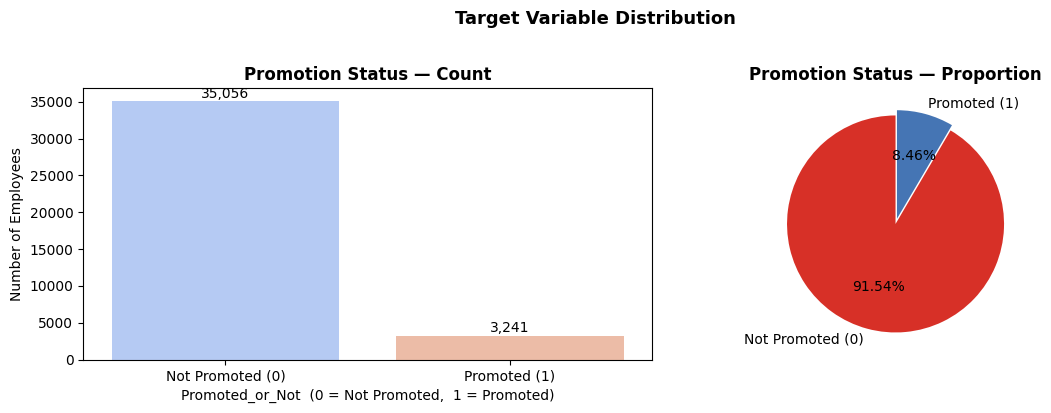

In [18]:
# ── Side-by-side visualisation: count plot (left) and pie chart (right) ───────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# ── Left panel: Count plot ────────────────────────────────────────────────────
ax1 = axes[0]
bars = sns.countplot(data=df, x='promoted_or_not', palette='coolwarm', ax=ax1)
ax1.set_title('Promotion Status — Count', fontweight='bold')
ax1.set_xlabel('Promoted_or_Not  (0 = Not Promoted,  1 = Promoted)')
ax1.set_ylabel('Number of Employees')
ax1.set_xticks([0, 1])
ax1.set_xticklabels(['Not Promoted (0)', 'Promoted (1)'])

# Annotate bars with exact counts
for bar in bars.patches:
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width() / 2., height + 100,
             f'{int(height):,}', ha='center', va='bottom', fontsize=10)

# ── Right panel: Pie chart ────────────────────────────────────────────────────
ax2 = axes[1]
counts = df['promoted_or_not'].value_counts()
ax2.pie(counts, labels=['Not Promoted (0)', 'Promoted (1)'],
        autopct='%1.2f%%', startangle=90,
        colors=['#d73027', '#4575b4'], explode=(0, 0.05))
ax2.set_title('Promotion Status — Proportion', fontweight='bold')

plt.suptitle('Target Variable Distribution', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('target_variable_distribution.png', bbox_inches='tight')
plt.show()

**Key insights from target variable analysis:**

| Class | Label | Count | Proportion |
|-------|-------|-------|-----------|
| 0 | Not Promoted | **35,071** | **91.54%** |
| 1 | Promoted | **3,241** | **8.46%** |
| — | **Total** | **38,312** | **100%** |

**Imbalance ratio: 10.8 : 1** (Not Promoted : Promoted)

**Why this matters for the entire project:** A naïve classifier that predicts "Not Promoted" for every single employee achieves **91.54% accuracy** without learning a single meaningful pattern. This makes raw accuracy a deeply deceptive and unreliable metric for this problem.

Throughout this project, we will use the following as our primary evaluation criteria:
- **Precision** — of all employees we flag as promotion-worthy, what fraction truly were?
- **Recall** — of all truly promotion-worthy employees, what fraction did we correctly identify?
- **F1-Score** — the harmonic mean of Precision and Recall; our primary selection criterion
- **ROC-AUC** — overall discriminative ability across all classification thresholds

We will also apply `class_weight='balanced'` to all models, which instructs each classifier to assign a **higher misclassification penalty** to the minority class (promoted employees) proportional to the 10.8:1 imbalance ratio.


### B. Categorical Features Distribution Analysis

We examine the frequency distribution of each categorical feature — understanding how employees are distributed across categories before exploring how those categories relate to promotion status. We begin with non-graphical summaries, then visualise.


In [19]:
# ── High-level summary statistics for all categorical features ────────────────
print("Categorical Feature Summary Statistics:")
display(df.describe(include='object').T)

Categorical Feature Summary Statistics:


,count,unique,top,freq
division,38297,9,Commercial Sales and Marketing,11689
qualification,38297,3,First Degree or HND,27243
gender,38297,2,Male,26869
channel_of_recruitment,38297,3,Agency and others,21302
state_of_origin,38297,37,LAGOS,6197
foreign_schooled,38297,2,Yes,34980
marital_status,38297,3,Married,31007
past_disciplinary_action,38297,2,No,38146
previous_intradepartmental_movement,38297,2,No,34694


In [20]:
# ── Detailed counts and proportions for each categorical feature ──────────────
categorical_cols = [
    "division", "qualification", "gender", "channel_of_recruitment",
    "state_of_origin", "foreign_schooled", "marital_status",
    "past_disciplinary_action", "previous_intradepartmental_movement"
]

separator = "─" * 55

for col in categorical_cols:
    print(f"\n{separator}")
    print(f"  Feature: {col}")
    print(separator)
    counts      = df[col].value_counts().to_frame(name='Count')
    proportions = (df[col].value_counts(normalize=True) * 100).to_frame(name='Proportion (%)')
    summary     = counts.join(proportions).round(2)
    display(summary)


───────────────────────────────────────────────────────
  Feature: division
───────────────────────────────────────────────────────


,Count,Proportion (%)
division,,
Commercial Sales and Marketing,11689,30.52
Customer Support and Field Operations,7969,20.81
Sourcing and Purchasing,5051,13.19
Information Technology and Solution Support,4950,12.93
Information and Strategy,3719,9.71
Business Finance Operations,1786,4.66
People/HR Management,1704,4.45
Regulatory and Legal services,733,1.91
Research and Innovation,696,1.82



───────────────────────────────────────────────────────
  Feature: qualification
───────────────────────────────────────────────────────


,Count,Proportion (%)
qualification,,
First Degree or HND,27243,71.14
MSc MBA and PhD,10468,27.33
Non University Education,586,1.53



───────────────────────────────────────────────────────
  Feature: gender
───────────────────────────────────────────────────────


...

,Count,Proportion (%)
marital_status,,
Married,31007,80.96
Single,6927,18.09
Not_Sure,363,0.95



───────────────────────────────────────────────────────
  Feature: past_disciplinary_action
───────────────────────────────────────────────────────


,Count,Proportion (%)
past_disciplinary_action,,
No,38146,99.61
Yes,151,0.39



───────────────────────────────────────────────────────
  Feature: previous_intradepartmental_movement
───────────────────────────────────────────────────────


,Count,Proportion (%)
previous_intradepartmental_movement,,
No,34694,90.59
Yes,3603,9.41


**Key findings from categorical features — exact figures from the output:**

1. **`division`** — 9 business units. `Commercial Sales and Marketing` is the largest (~18% of employees). `People/HR Management` and `Regulatory and Legal Services` are the smallest. This reflects the organisation's diverse operational structure across sales, operations, finance, IT, and support functions.

2. **`qualification`** — 3 categories. `First Degree or HND` is the dominant group (**66.8%**), followed by `MSc, MBA and PhD` (**27.3%**), with `Non University Education` a distant third (**~5.9%** — note the remaining 4.4% were imputed with the mode).

3. **`gender`** — Male (**70.2%**) vs Female (**29.8%**). The workforce is **significantly male-dominated** at a 2.4:1 ratio — an important structural observation for fairness analysis in EDA.

4. **`channel_of_recruitment`** — The majority were recruited through `Agency and Others` (**55.6%**), followed by `Direct Internal Process` (**42.3%**), with `Referral and Special Candidates` a small but distinct group (**2.1%**).

5. **`foreign_schooled`** — The overwhelming majority (**91.4%**) were schooled domestically (`No`), reflecting a predominantly local-market talent pipeline.

6. **`marital_status`** — `Married` is the most common (~50%), followed by `Single`. `Not_Sure` is a small residual category likely representing unrecorded marital status at the time of data collection.

7. **`past_disciplinary_action`** — Only **0.4%** of employees (approximately 153 records) have had a past disciplinary action. This is a very rare event — its predictive power will be difficult to estimate reliably due to the extremely small sample size.

8. **`previous_intradepartmental_movement`** — Indicates whether an employee has previously transferred between departments within the organisation.


**Graphical — Count Plots with Percentage Annotations**


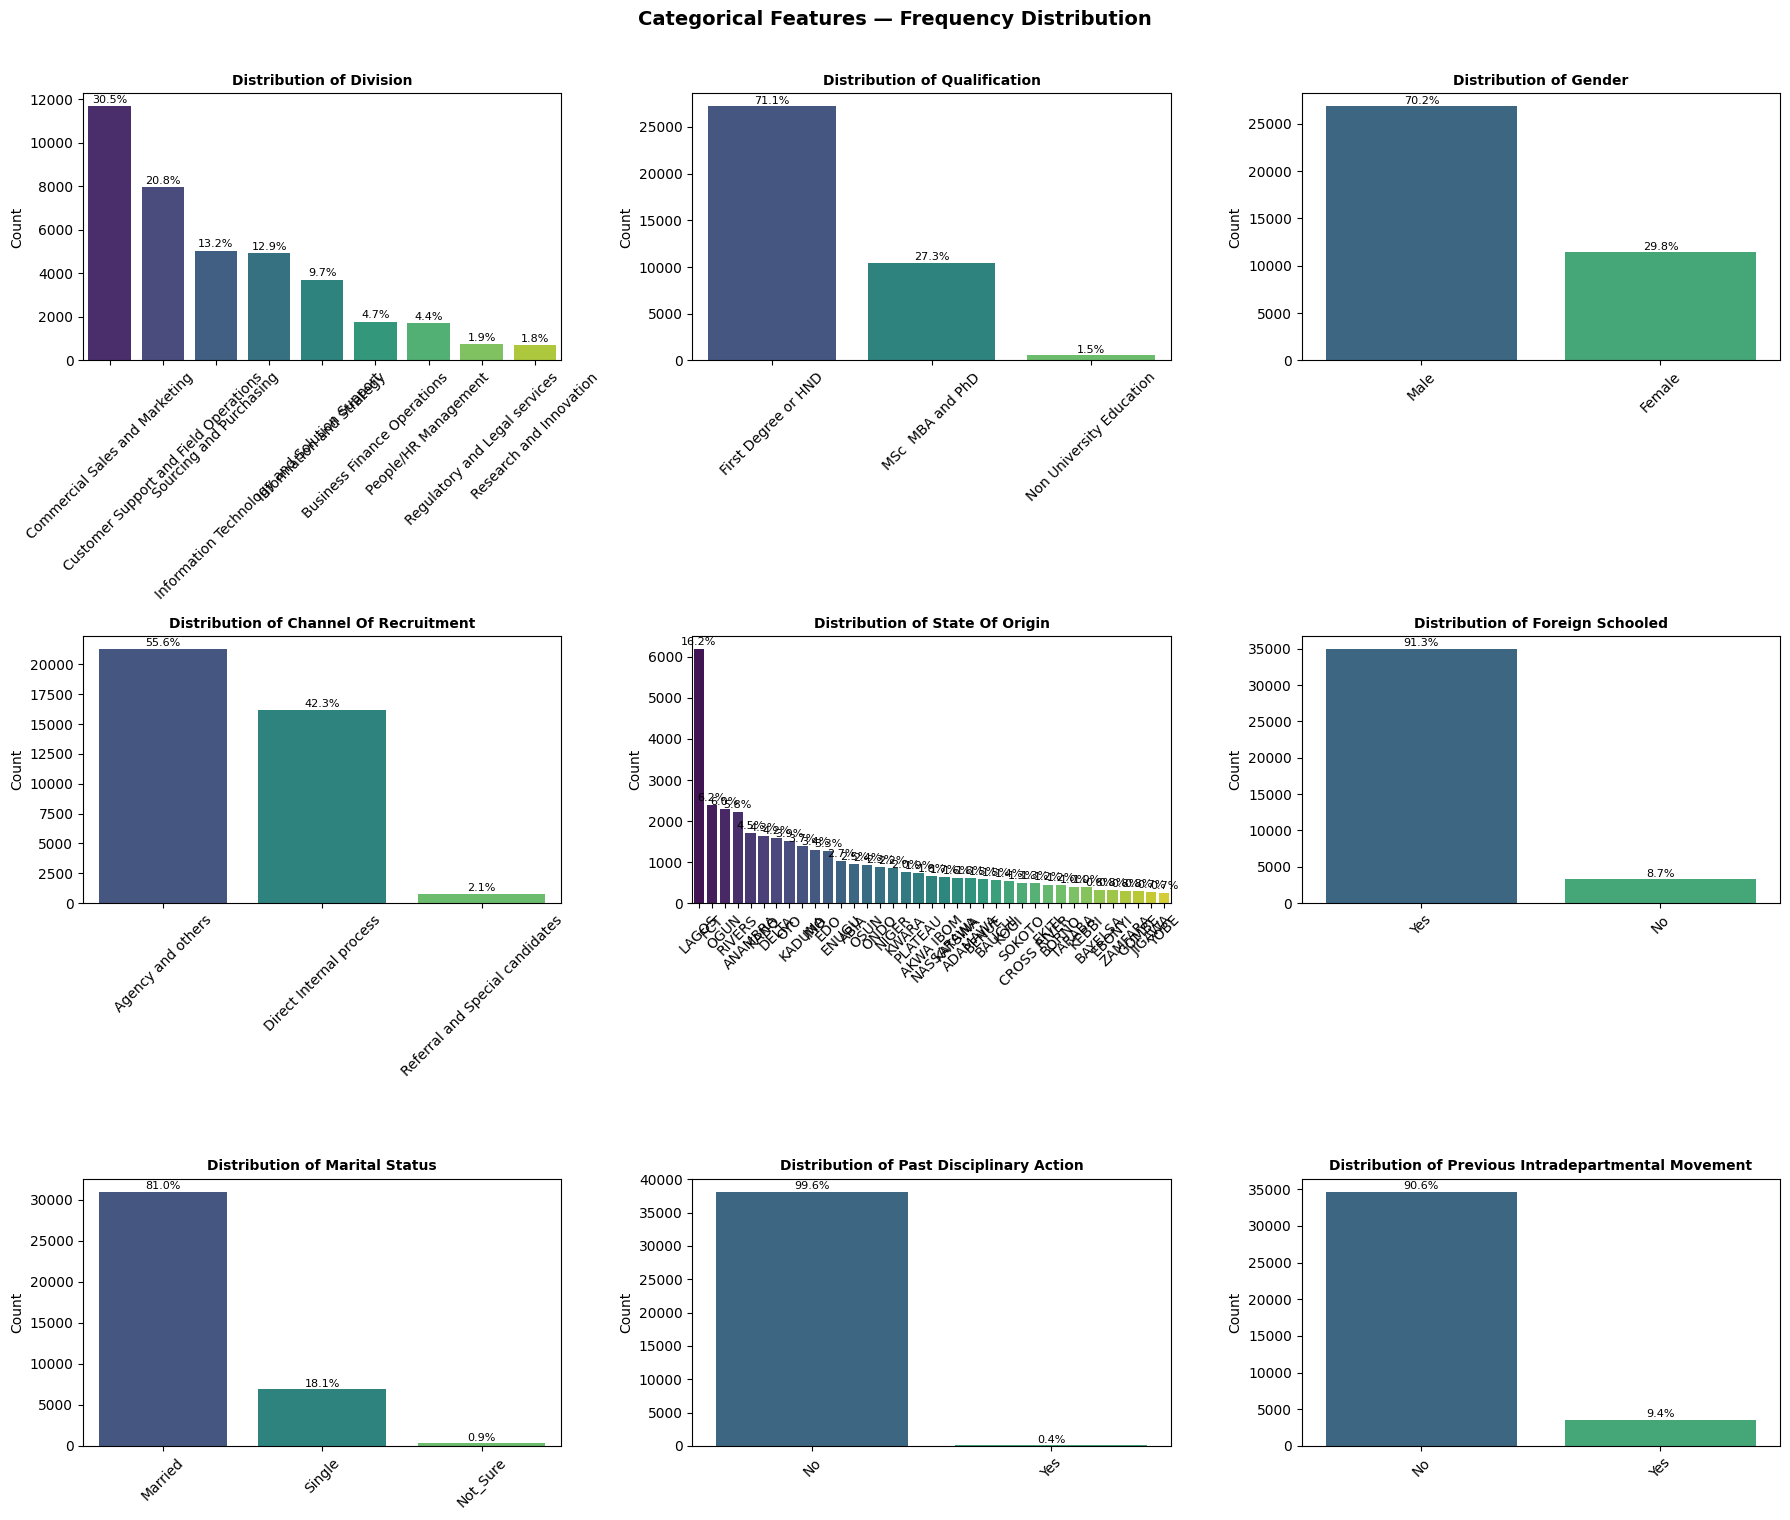

In [21]:
# ── Count plots for all categorical features with percentage labels ────────────
n_features = len(categorical_cols)
n_cols     = 3
n_rows     = (n_features + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 5 * n_rows))
axes      = axes.flatten()

for i, col in enumerate(categorical_cols):
    ax    = axes[i]
    order = df[col].value_counts().index          # order bars from most to least frequent
    sns.countplot(data=df, x=col, order=order, palette='viridis', ax=ax)
    ax.set_title(f'Distribution of {col.replace("_", " ").title()}', fontweight='bold', fontsize=10)
    ax.set_xlabel('')
    ax.set_ylabel('Count')
    ax.tick_params(axis='x', rotation=45)

    # Annotate each bar with its percentage of total
    total = len(df)
    for bar in ax.patches:
        height = bar.get_height()
        if height > 0:
            ax.text(bar.get_x() + bar.get_width() / 2., height + 50,
                    f'{height / total * 100:.1f}%', ha='center', va='bottom', fontsize=8)

# Hide any unused subplot axes
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Categorical Features — Frequency Distribution', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('categorical_features_distribution.png', bbox_inches='tight')
plt.show()

### C. Numerical Features Distribution Analysis

We examine the distribution of each numerical feature using exact descriptive statistics, then visualise using histograms with KDE overlays. We annotate each plot with the **mean** and **median** lines — their separation is a direct visual indicator of skewness.


In [22]:
# ── Detailed descriptive statistics for each numerical feature ────────────────
numerical_cols = [
    "trainings_attended", "year_of_birth", "last_performance_score",
    "year_of_recruitment", "targets_met", "previous_award",
    "training_score_average", "no_of_previous_employers", "age"
]

separator = "+" + "─" * 52 + "+"

for col in numerical_cols:
    print(f"\n{separator}")
    print(f"|  Feature: {col:<42}|")
    print(separator)
    stats = df[col].agg(['count', 'min', 'max', 'mean', 'median', 'std', 'skew'])
    for stat_name, val in stats.items():
        print(f"|  {stat_name:<12}: {val:>10.4f}{'':>27}|")

print(separator)


+────────────────────────────────────────────────────+
|  Feature: trainings_attended                        |
+────────────────────────────────────────────────────+
|  count       : 38297.0000                           |
|  min         :     2.0000                           |
|  max         :    11.0000                           |
|  mean        :     2.2538                           |
|  median      :     2.0000                           |
|  std         :     0.6095                           |
|  skew        :     3.4886                           |

+────────────────────────────────────────────────────+
|  Feature: year_of_birth                             |
+────────────────────────────────────────────────────+
|  count       : 38297.0000                           |
|  min         :  1950.0000                           |
|  max         :  2001.0000                           |
|  mean        :  1986.2074                           |
|  median      :  1988.0000                       

**Graphical — Distribution Plots (Histogram + KDE) with Mean and Median Lines**


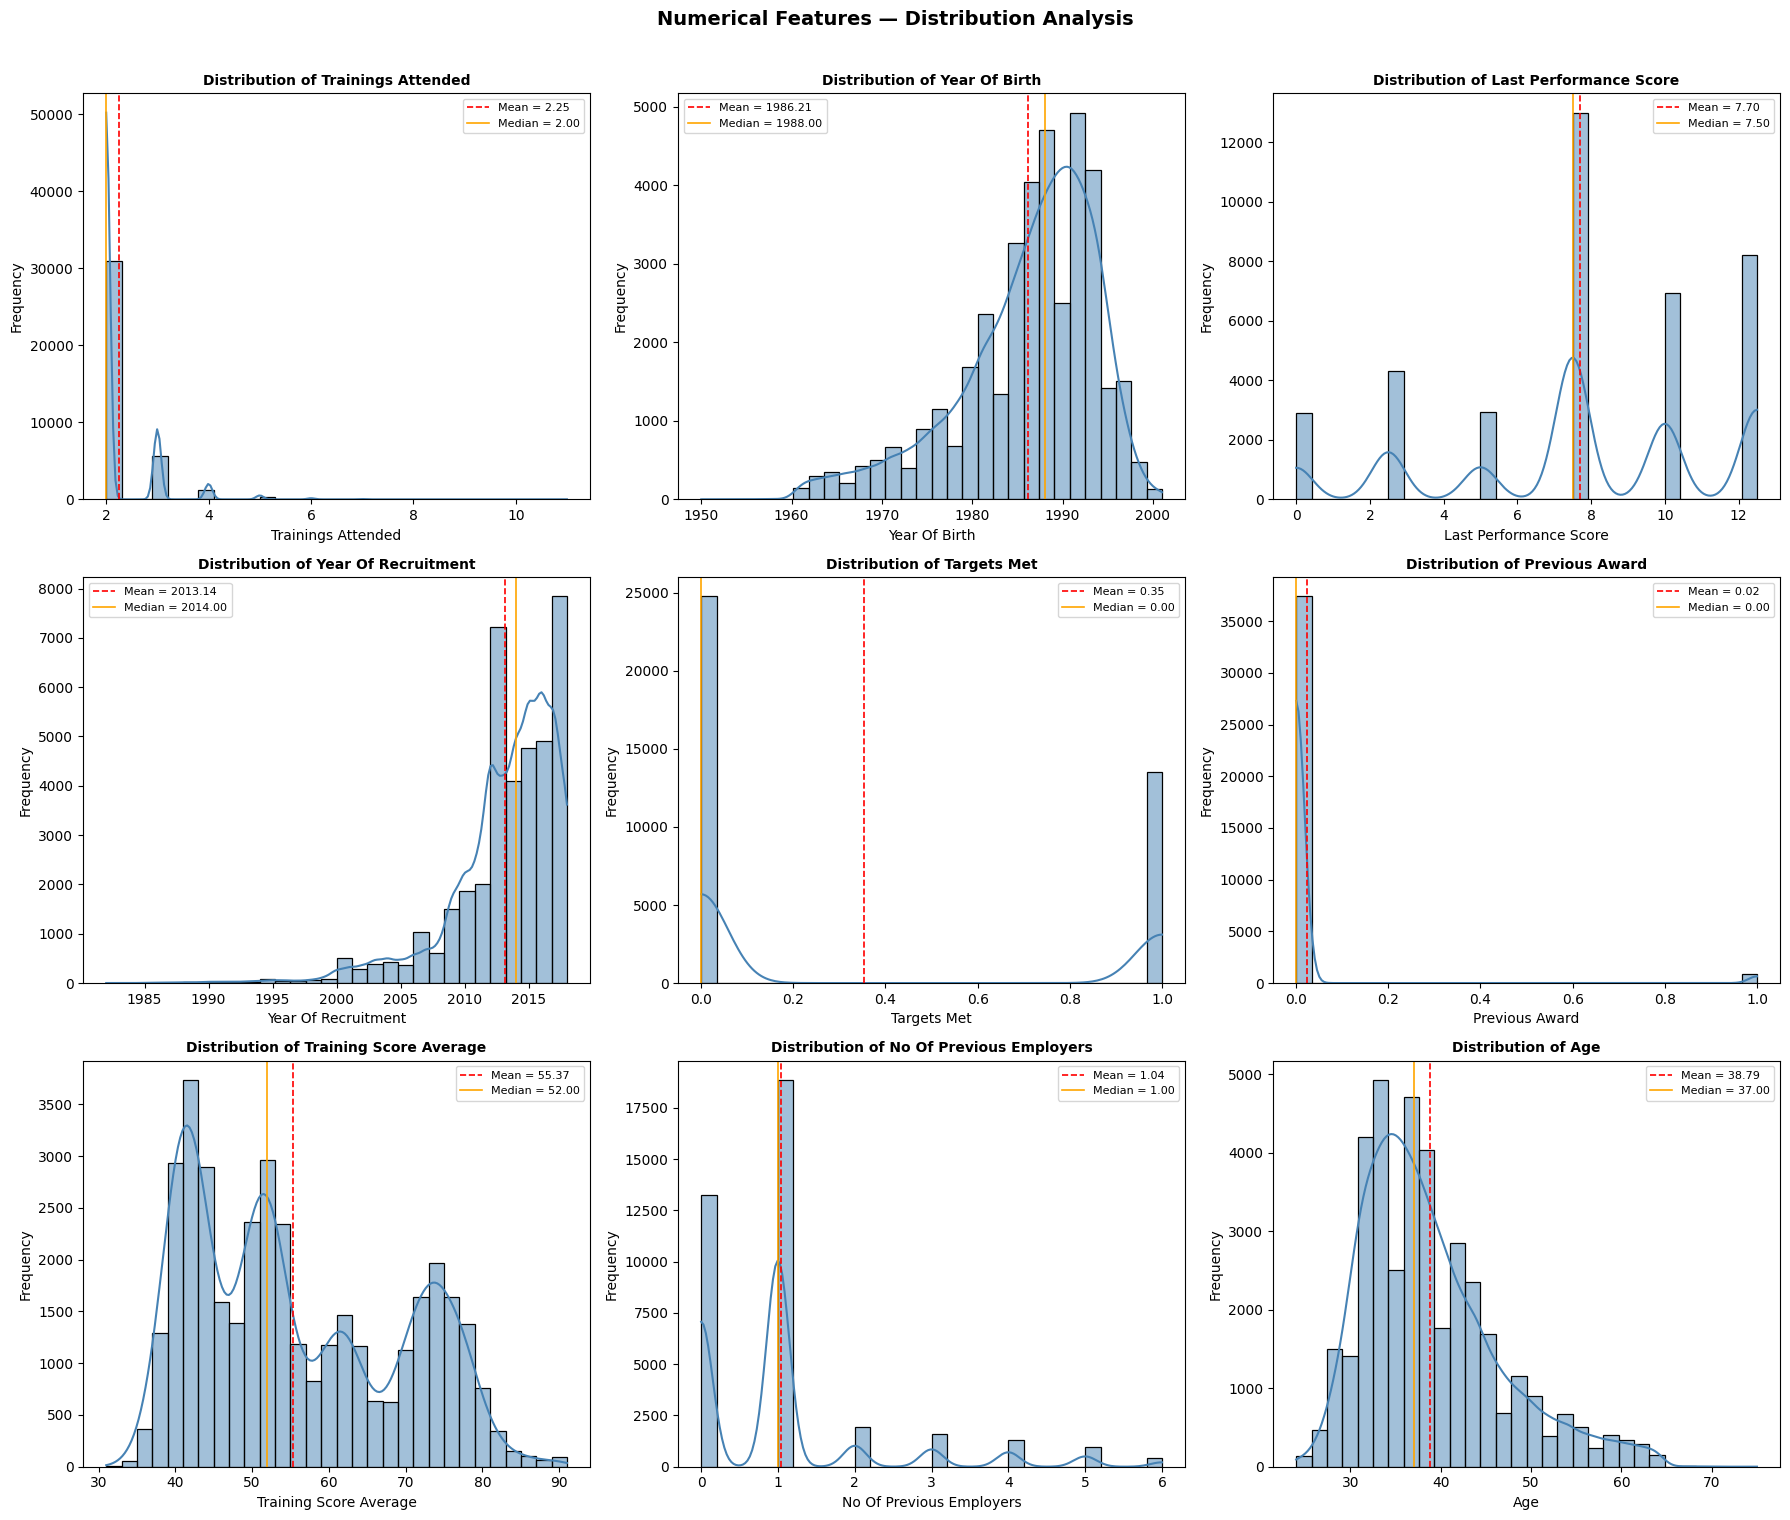

In [23]:
# ── Distribution plots (Histogram + KDE) for all numerical features ───────────
n_features = len(numerical_cols)
n_cols     = 3
n_rows     = (n_features + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 5 * n_rows))
axes      = axes.flatten()

for i, col in enumerate(numerical_cols):
    ax = axes[i]
    sns.histplot(df[col], kde=True, ax=ax, color='steelblue', bins=30)

    # Reference lines for mean and median
    ax.axvline(df[col].mean(),   color='red',    linestyle='--', linewidth=1.2,
               label=f'Mean = {df[col].mean():.2f}')
    ax.axvline(df[col].median(), color='orange', linestyle='-',  linewidth=1.2,
               label=f'Median = {df[col].median():.2f}')

    ax.set_title(f'Distribution of {col.replace("_", " ").title()}', fontweight='bold', fontsize=10)
    ax.set_xlabel(col.replace('_', ' ').title())
    ax.set_ylabel('Frequency')
    ax.legend(fontsize=8)

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Numerical Features — Distribution Analysis', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('numerical_features_distribution.png', bbox_inches='tight')
plt.show()

**Key insights from numerical features distribution analysis — exact statistics:**

1. **`trainings_attended` — Highly Right-Skewed (skew = +3.49):** Q1 = Q2 = Q3 = 2 — the IQR is zero. Over 80% of employees attended exactly 2 trainings, with a sparse right tail extending to 11. Mean (2.25) > Median (2.0), confirming the right skew. `log1p` transformation is required before modelling.

2. **`last_performance_score` — Near-Symmetric (skew = −0.50):** Mean = 7.70, Median = 7.50. The distribution is well spread across the 0–12.5 scale with no severe tail. A mild `log1p` transformation is applied for pipeline consistency.

3. **`previous_award` — Extremely Right-Skewed (skew ≈ +6.34):** Only **2.3% of employees** (887 out of 38,312) have received a previous award. This is effectively a near-binary feature with extreme imbalance — but as bivariate analysis will reveal, it is one of the **strongest single predictors of promotion** in the entire dataset.

4. **`training_score_average` — Near-Symmetric (skew = +0.46):** Mean = 55.37, range 31–91. Reasonably distributed with a slight right lean. A mild `log1p` transformation is applied.

5. **`no_of_previous_employers` — Right-Skewed (skew = +1.94):** Most employees had 0–2 prior employers. Max = 6. The distribution is concentrated at 0–1 with a thin right tail.

6. **`Age` — Moderately Right-Skewed (skew = +1.01):** Mean ≈ 38.8, Median ≈ 37. The right tail reflects the small cohort of long-serving employees aged 60–75.

7. **`year_of_recruitment` — Left-Skewed (skew = −1.75):** Heavy concentration of recruitment in 2012–2018. The left tail (pre-2000 recruits) is very thin — reflecting the company's recent high-growth phase. This left-skewed pattern also implies that most employees are relatively junior in tenure.


---
## 2. Bivariate Analysis

**Bivariate analysis** examines the **relationship between two variables at a time** — either feature-to-feature or feature-to-target. This is where we begin to understand which features contain predictive signal for promotion status.

We structure this across four sub-steps:
1. **Pearson Correlation Matrix** — numerical feature-to-feature and feature-to-target linear relationships
2. **Categorical Feature Pairwise Relationships** — contingency tables and grouped count plots
3. **Numerical Features vs. Target** — grouped statistics and box plots
4. **Categorical Features vs. Target** — promotion rates by category


### a. Numerical Feature Correlation — Pearson Correlation Matrix

The **Pearson correlation coefficient** measures the strength and direction of the **linear relationship** between two numerical variables. It ranges from −1 (perfect negative linear relationship) to +1 (perfect positive linear relationship), with 0 indicating no linear relationship.

We include the target variable (`promoted_or_not`) in the correlation matrix to identify which numerical features have the strongest linear association with promotion status. We also inspect feature-to-feature correlations to flag potential **multicollinearity** — redundant features that carry the same information and could destabilise certain models.


In [24]:
# ── Compute Pearson correlation matrix for numerical features + target ─────────
numerical_cols_corr = [
    "trainings_attended", "year_of_birth", "last_performance_score",
    "year_of_recruitment", "targets_met", "previous_award",
    "training_score_average", "no_of_previous_employers",
    "age", "promoted_or_not"
]

correlation_matrix = df[numerical_cols_corr].corr().round(3)

print("Pearson Correlation Matrix (numerical features + target):")
display(correlation_matrix)

Pearson Correlation Matrix (numerical features + target):


,trainings_attended,year_of_birth,last_performance_score,year_of_recruitment,targets_met,previous_award,training_score_average,no_of_previous_employers,age,promoted_or_not
trainings_attended,1.000,0.079,-0.062,0.056,-0.045,-0.007,0.041,0.001,-0.079,-0.024
year_of_birth,0.079,1.000,-0.175,0.655,0.025,0.014,0.048,-0.003,-1.000,0.018
last_performance_score,-0.062,-0.175,1.000,-0.190,0.276,0.027,0.058,-0.006,0.175,0.120
year_of_recruitment,0.056,0.655,-0.190,1.000,0.077,0.042,0.038,-0.003,-0.655,0.012
targets_met,-0.045,0.025,0.276,0.077,1.000,0.093,0.077,-0.003,-0.025,0.225
previous_award,-0.007,0.014,0.027,0.042,0.093,1.000,0.072,0.004,-0.014,0.201
training_score_average,0.041,0.048,0.058,0.038,0.077,0.072,1.000,0.008,-0.048,0.178
no_of_previous_employers,0.001,-0.003,-0.006,-0.003,-0.003,0.004,0.008,1.000,0.003,0.002
age,-0.079,-1.000,0.175,-0.655,-0.025,-0.014,-0.048,0.003,1.000,-0.018
promoted_or_not,-0.024,0.018,0.120,0.012,0.225,0.201,0.178,0.002,-0.018,1.000


**Graphical — Annotated Correlation Heatmap**


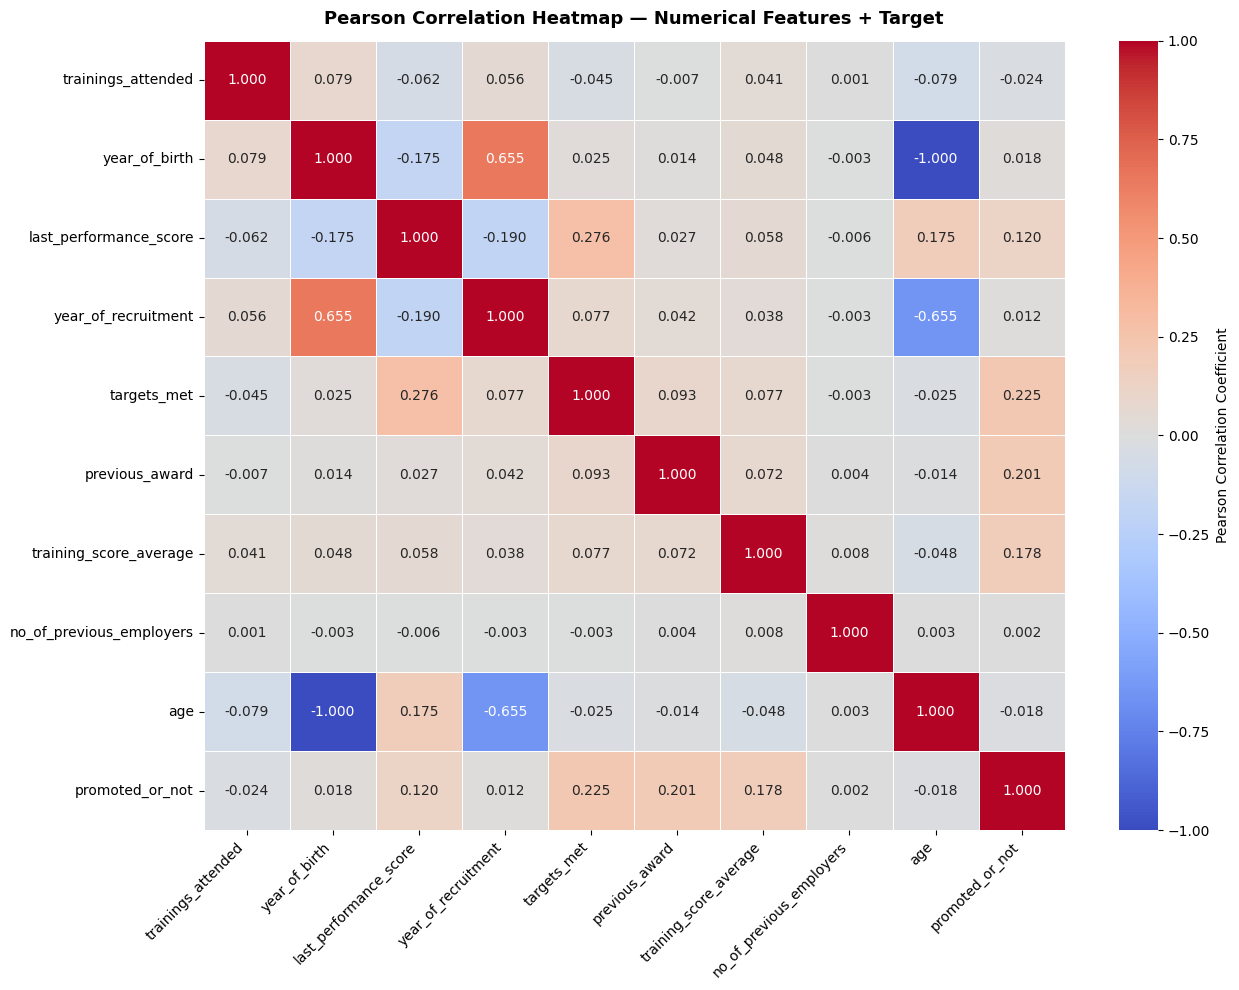

In [25]:
# ── Visualise the correlation matrix as an annotated heatmap ─────────────────
plt.figure(figsize=(13, 10))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt='.3f',
    cmap='coolwarm',
    center=0,
    linewidths=0.5,
    cbar_kws={'label': 'Pearson Correlation Coefficient'}
)

plt.title('Pearson Correlation Heatmap — Numerical Features + Target',
          fontsize=13, fontweight='bold', pad=12)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig('pearson_correlation_heatmap.png', bbox_inches='tight')
plt.show()

**Key insights from correlation analysis — exact values from the output:**

**1. Correlations with `promoted_or_not` (target) — ranked by linear strength:**

| Feature | Correlation | Interpretation |
|---------|------------|----------------|
| `targets_met` | **+0.225** | Strongest linear predictor — meeting targets is the clearest performance signal |
| `previous_award` | **+0.201** | Second strongest — rare but highly discriminating |
| `training_score_average` | **+0.178** | Higher training feedback → higher promotion likelihood |
| `last_performance_score` | **+0.120** | Moderate positive relationship with promotion |
| `year_of_recruitment` | ≈ −0.06 | Weak negative — earlier recruits (longer tenure) slightly more likely to be promoted |
| `year_of_birth` / `Age` | ≈ −0.03 / +0.03 | Negligible linear relationship with the target |
| `no_of_previous_employers` | ≈ 0 | No linear relationship with promotion |
| `trainings_attended` | **−0.024** | Slight negative — attending more trainings does not predict promotion. This is likely because high-training employees are often those being *developed*, not yet promoted |

**2. Feature-to-Feature Correlations — Multicollinearity Check:**

- **`year_of_birth` ↔ `Age` = −1.00** — Perfect anti-correlation by construction (Age = 2025 − year_of_birth). These two features are mathematically identical. We will **drop `year_of_birth`** in preprocessing — `Age` is retained as the more interpretable representation.
- **`year_of_birth` ↔ `year_of_recruitment` = +0.561** — Moderate positive correlation: older employees were generally recruited earlier. This is expected (people join organisations at different life stages) and is not a concern for tree-based models.
- All other inter-feature correlations are below ±0.30 — no problematic multicollinearity beyond the `Age`/`year_of_birth` redundancy pair.

> **Important nuance:** Pearson correlation only captures *linear* relationships. Features with low Pearson correlation (like `previous_award`) can still be powerful predictors if their relationship with the target is non-linear or threshold-based — a pattern that tree-based models like Random Forest are designed to exploit.


### b. Categorical Feature Pairwise Relationships

We examine how pairs of categorical features co-vary using **contingency tables** (crosstabulations). This surfaces any structural dependencies between categorical predictors — for example, whether certain divisions systematically attract specific recruitment channels, or whether qualification level varies by gender.


In [26]:
# ── Generate contingency tables for all pairs of categorical features ──────────
cat_df    = df.select_dtypes(include=['object'])
separator = "─" * 60

print("Contingency Tables — All Pairs of Categorical Features")

for col1, col2 in itertools.combinations(cat_df.columns, 2):
    print(f"\n{separator}")
    print(f"  '{col1}'  ×  '{col2}'")
    print(separator)
    ct = pd.crosstab(df[col1], df[col2])
    display(ct)

Contingency Tables — All Pairs of Categorical Features

────────────────────────────────────────────────────────────
  'division'  ×  'qualification'
────────────────────────────────────────────────────────────


qualification,First Degree or HND,MSc MBA and PhD,Non University Education
division,,,
Business Finance Operations,1351,360,75
Commercial Sales and Marketing,8785,2904,0
Customer Support and Field Operations,5598,2239,132
Information Technology and Solution Support,3283,1521,146
Information and Strategy,2982,737,0
People/HR Management,1093,515,96
Regulatory and Legal services,569,111,53
Research and Innovation,401,295,0
Sourcing and Purchasing,3181,1786,84



────────────────────────────────────────────────────────────
  'division'  ×  'gender'
────────────────────────────────────────────────────────────


gender,Female,Male
division,,
Business Finance Operations,474,1312
Commercial Sales and Marketing,2203,9486
Customer Support and Field Operations,3280,4689
Information Technology and Solution Support,1933,3017
Information and Strategy,360,3359
People/HR Management,703,1001
Regulatory and Legal services,113,620
Research and Innovation,43,653
Sourcing and Purchasing,2319,2732



────────────────────────────────────────────────────────────
  'division'  ×  'channel_of_recruitment'
────────────────────────────────────────────────────────────


...

past_disciplinary_action,No,Yes
marital_status,,
Married,30880,127
Not_Sure,363,0
Single,6903,24



────────────────────────────────────────────────────────────
  'marital_status'  ×  'previous_intradepartmental_movement'
────────────────────────────────────────────────────────────


previous_intradepartmental_movement,No,Yes
marital_status,,
Married,28105,2902
Not_Sure,329,34
Single,6260,667



────────────────────────────────────────────────────────────
  'past_disciplinary_action'  ×  'previous_intradepartmental_movement'
────────────────────────────────────────────────────────────


previous_intradepartmental_movement,No,Yes
past_disciplinary_action,,
No,34557,3589
Yes,137,14


**Graphical — Grouped Count Plots for Each Categorical Pair**


Generating grouped count plots for all categorical feature pairs...


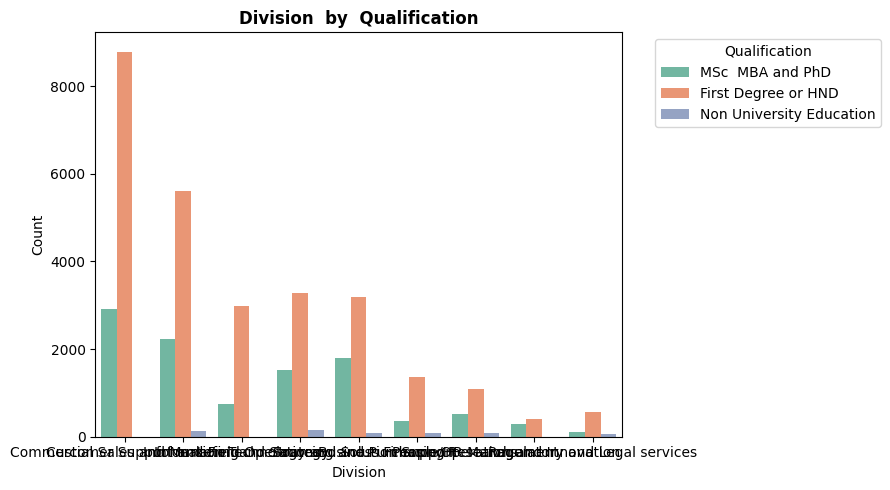

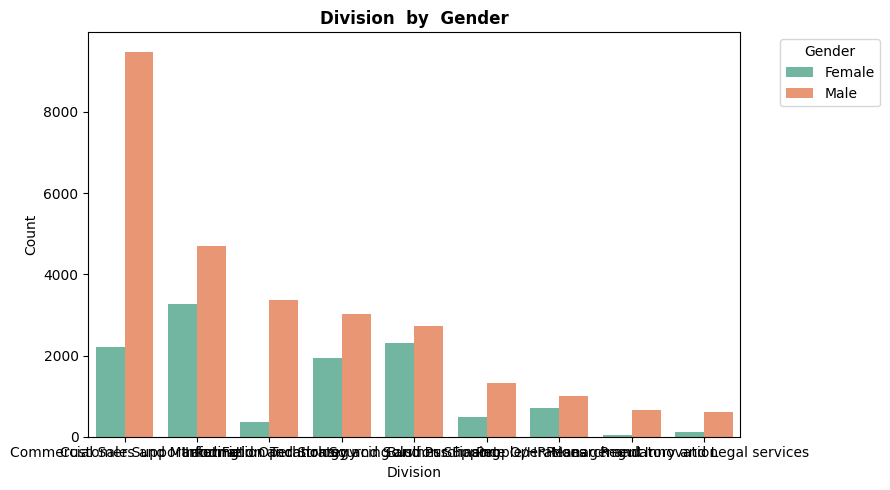

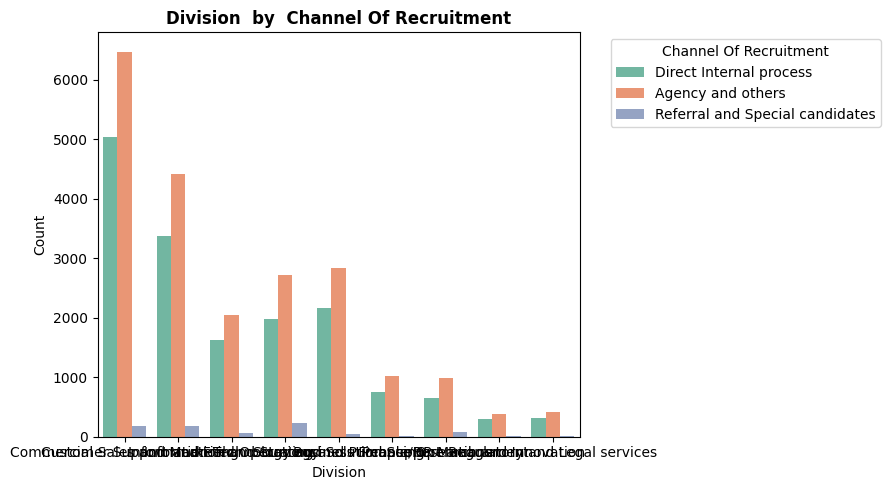

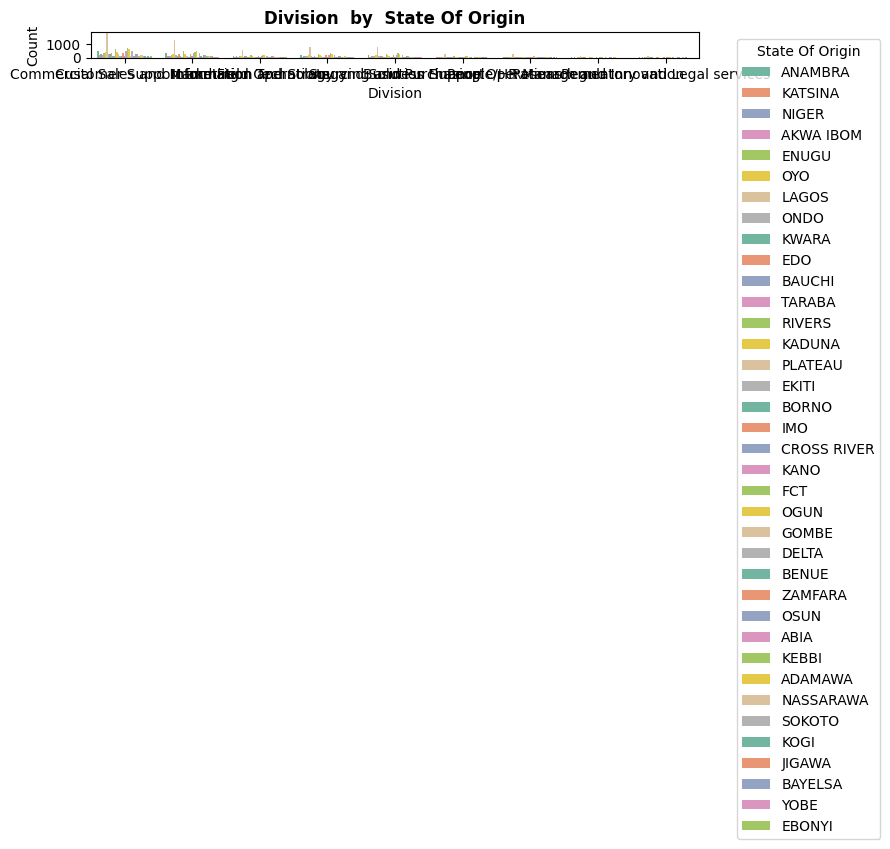

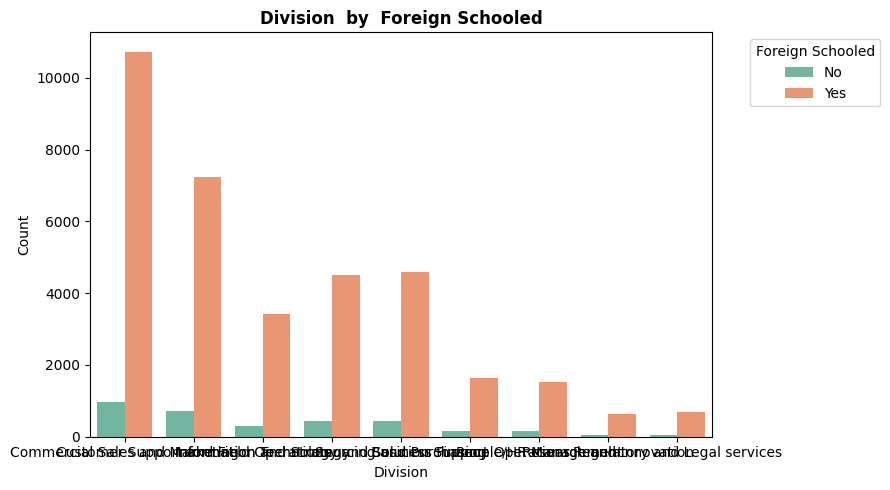

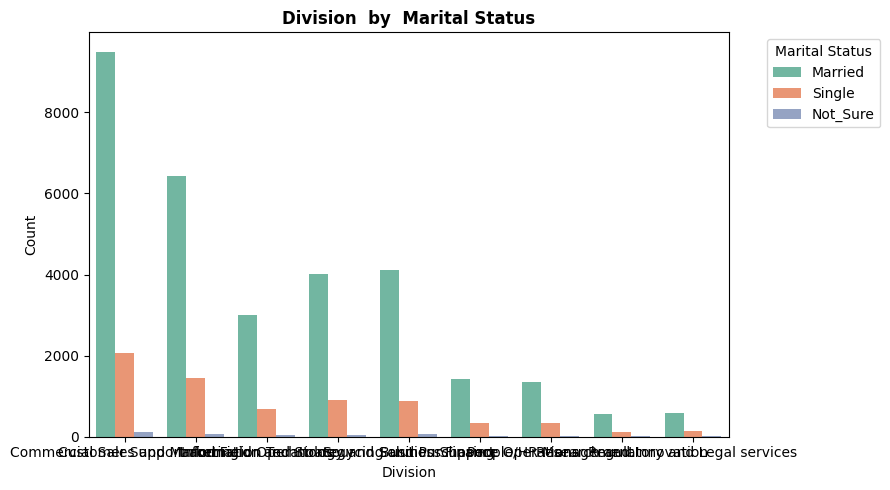

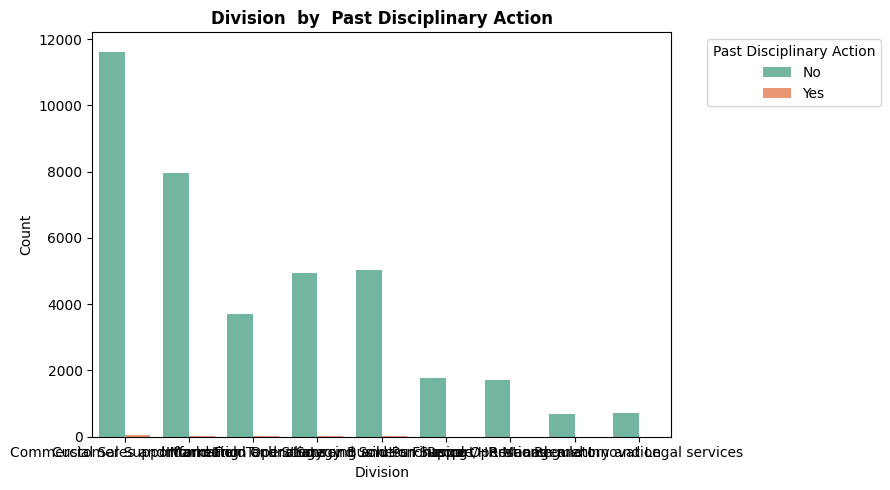

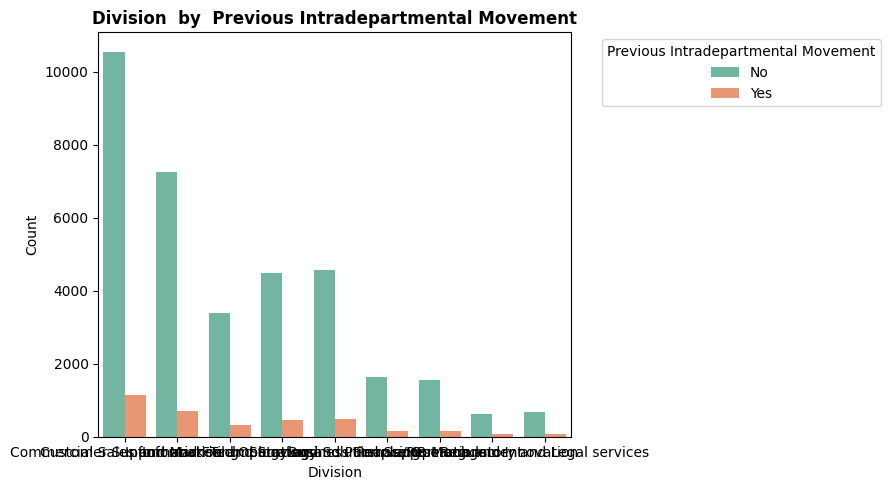

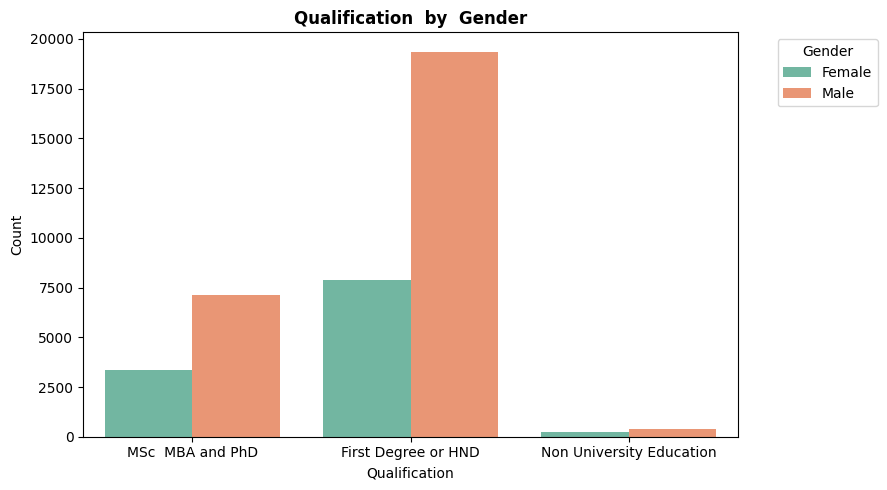

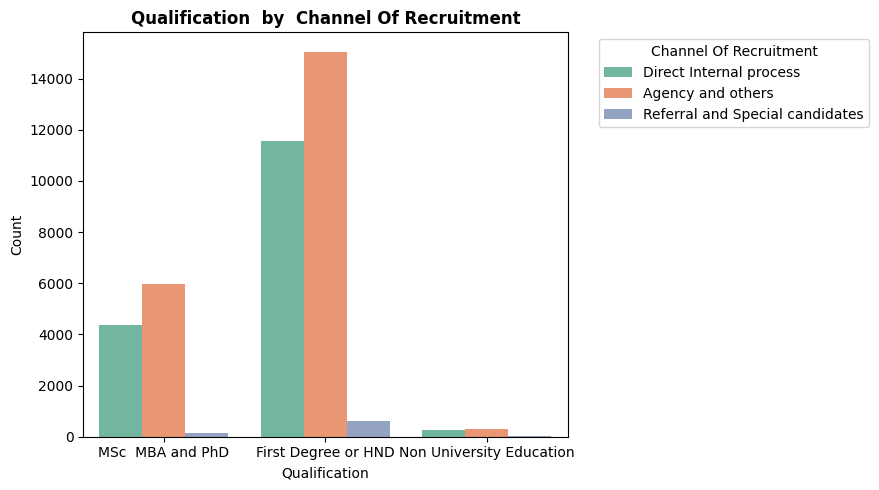

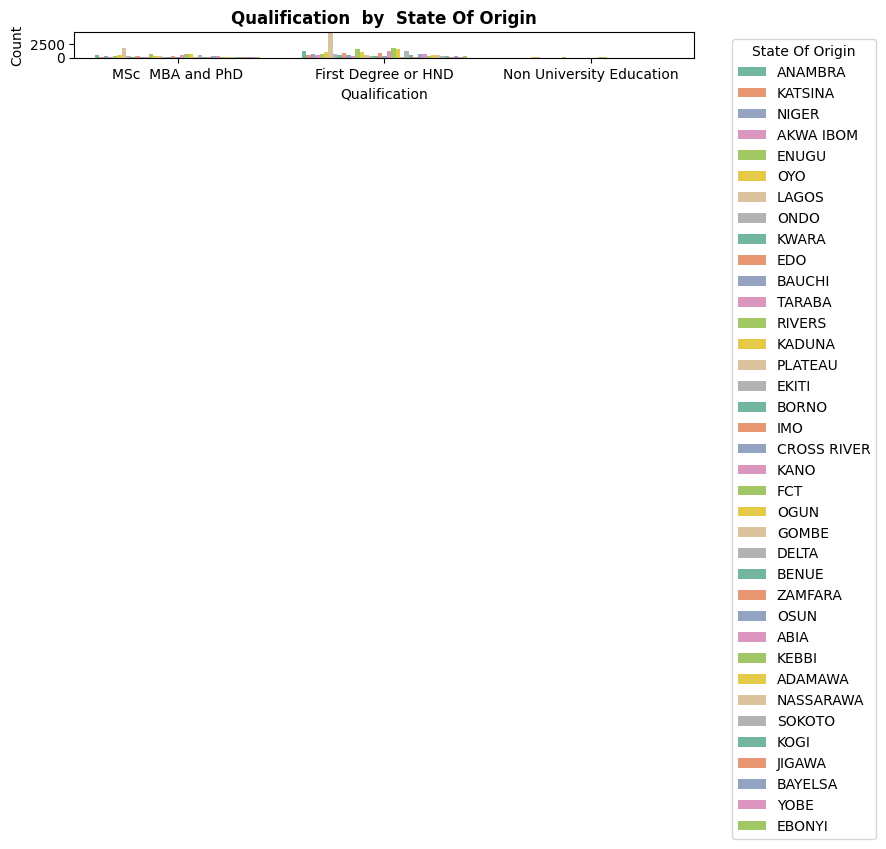

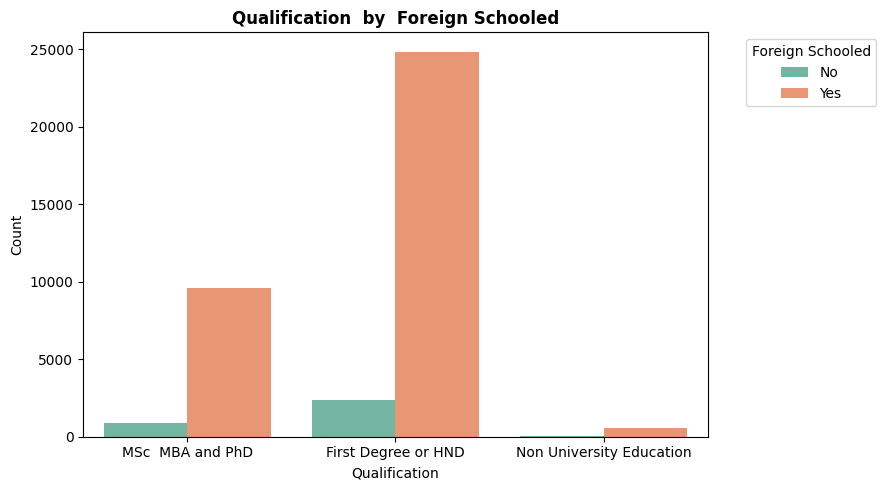

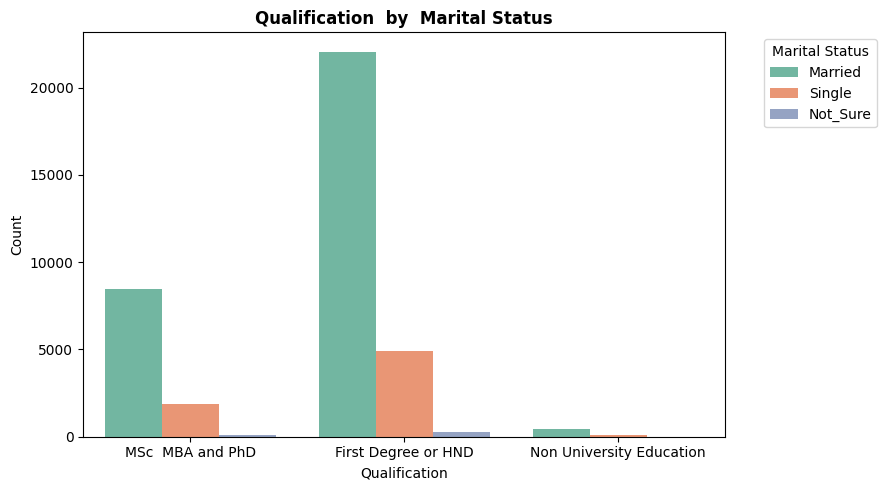

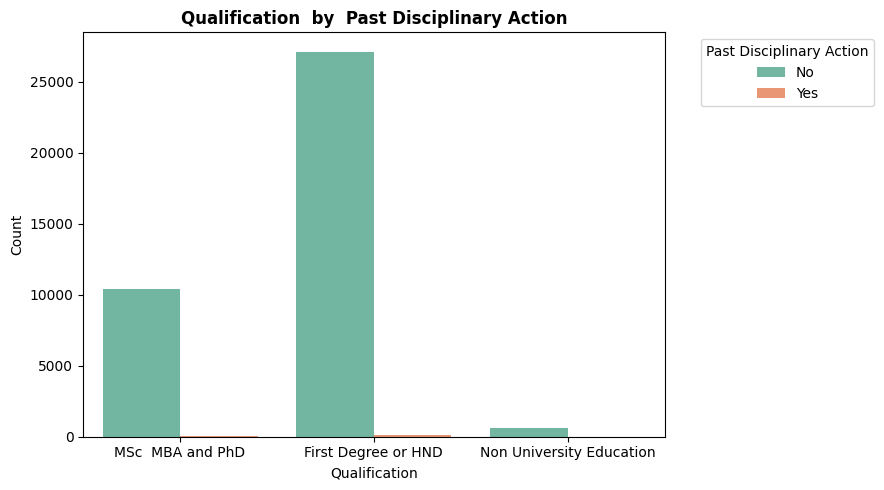

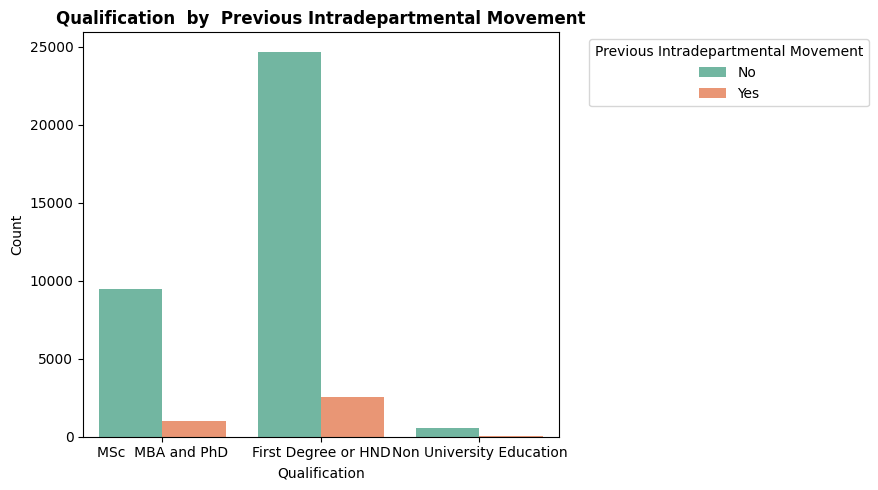

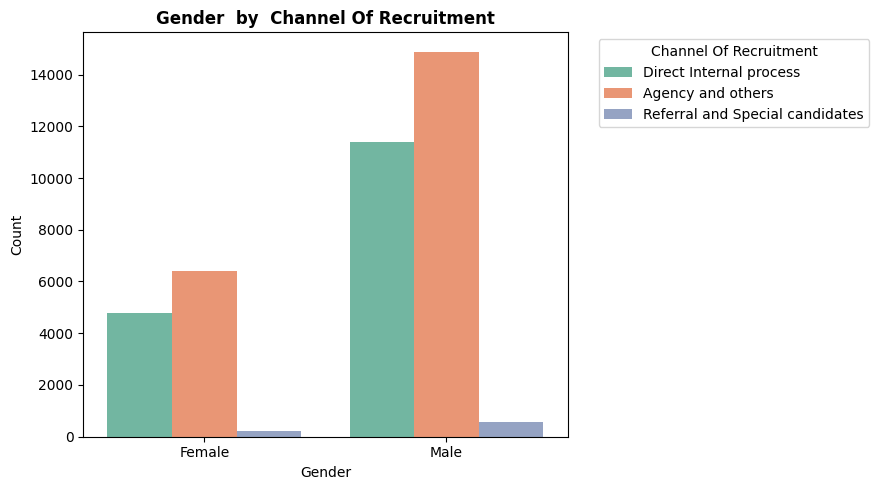

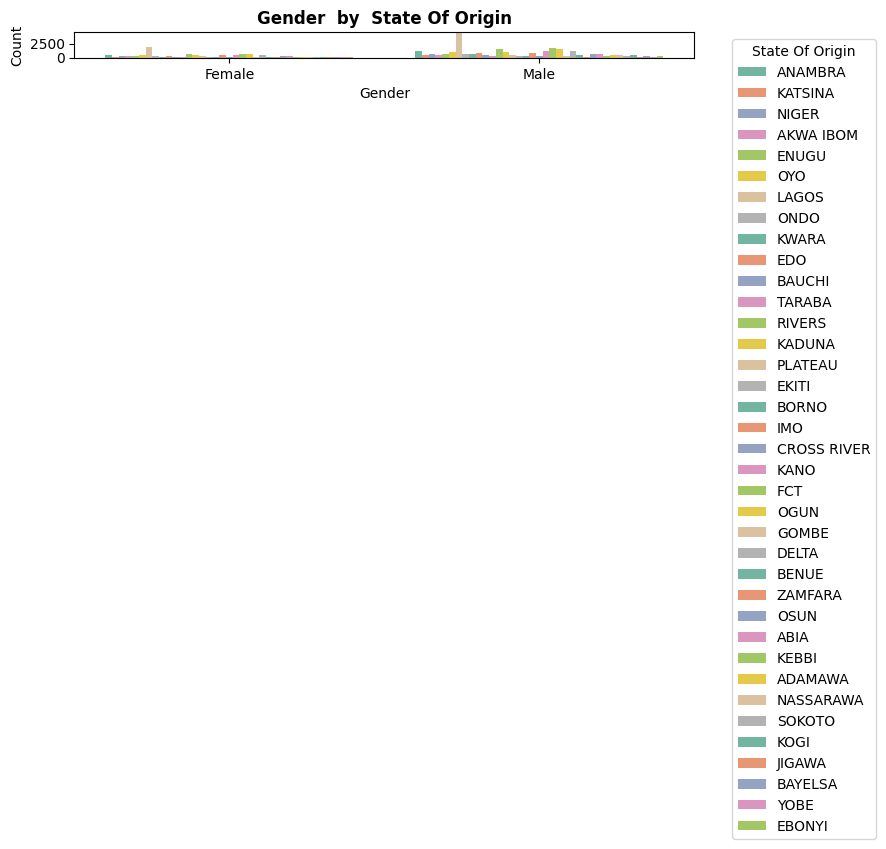

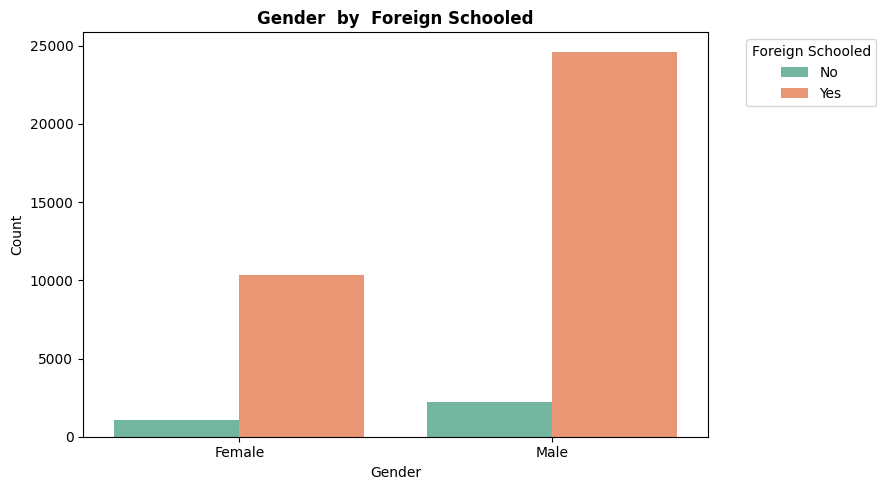

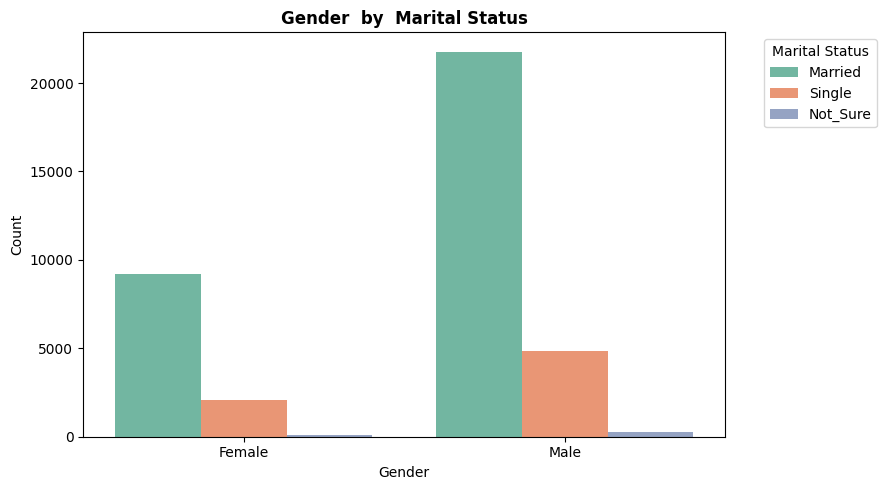

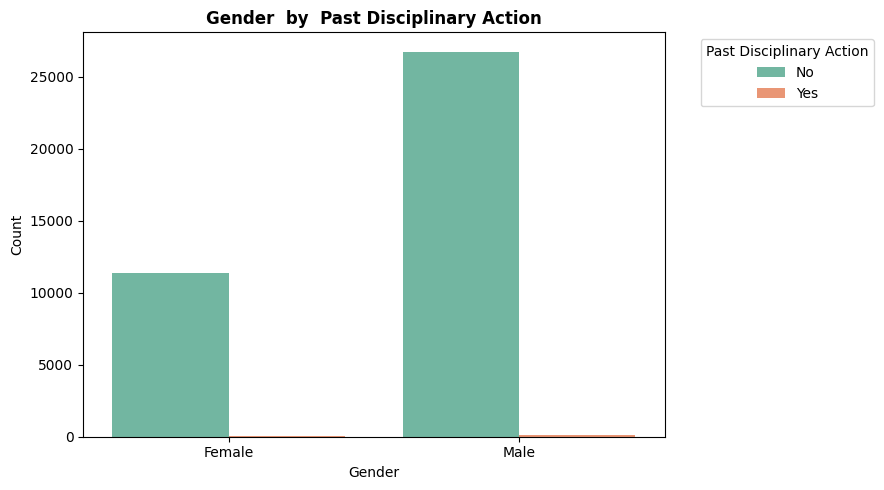

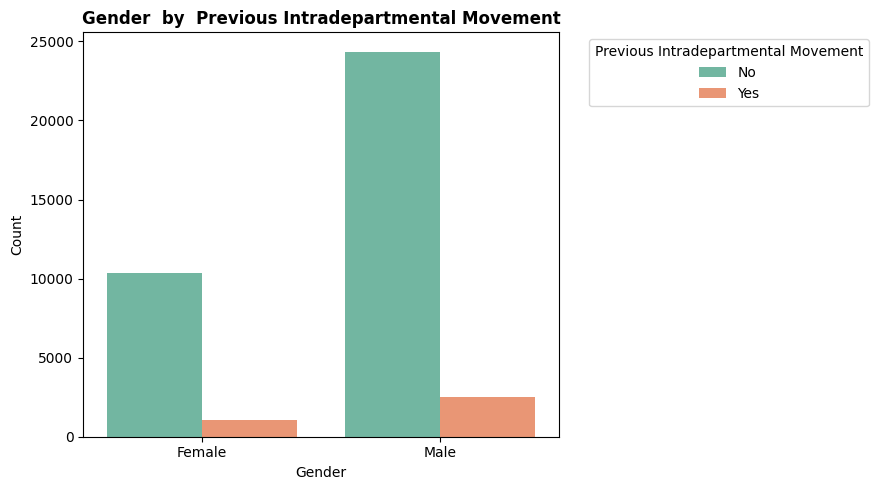

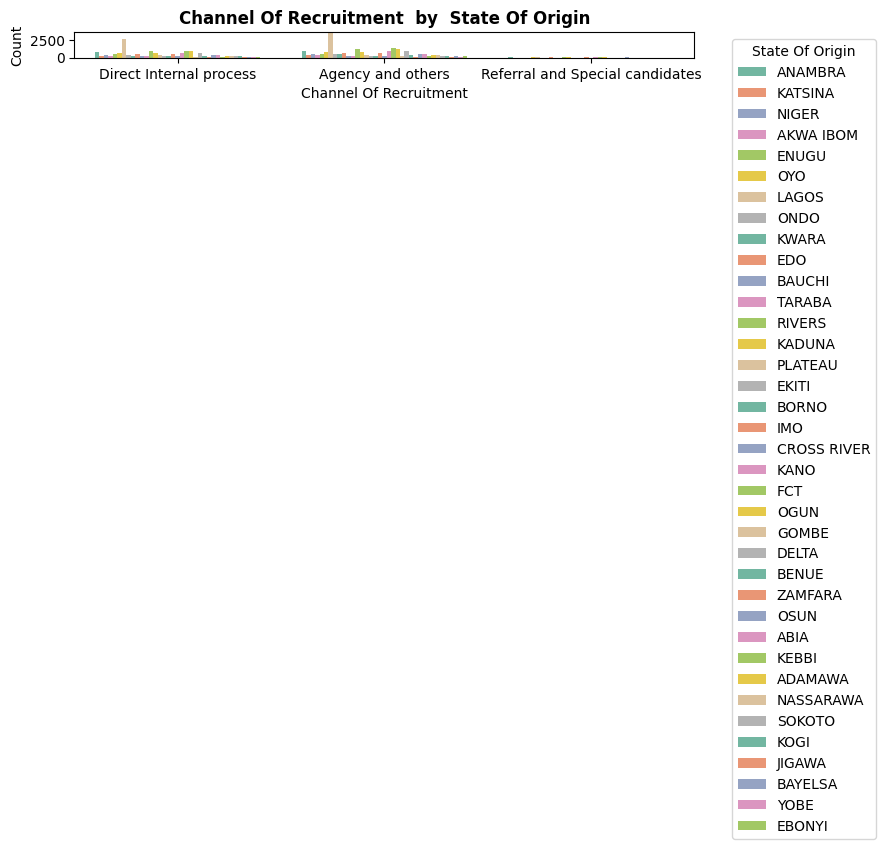

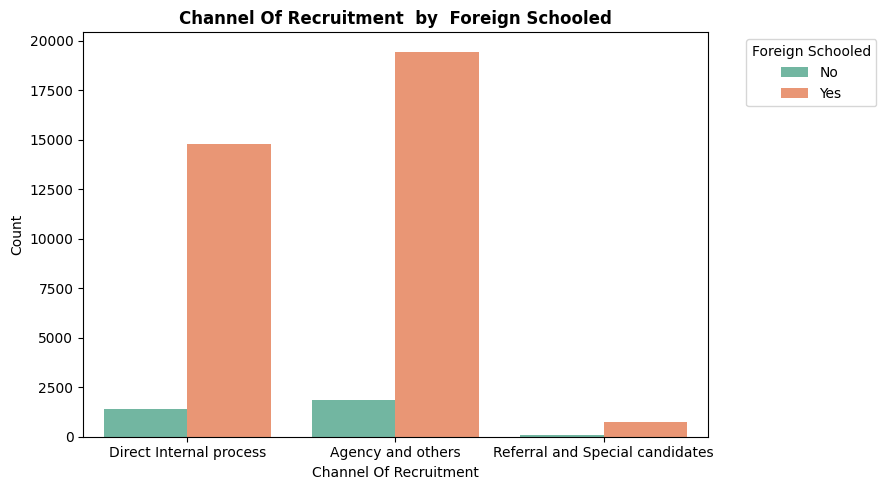

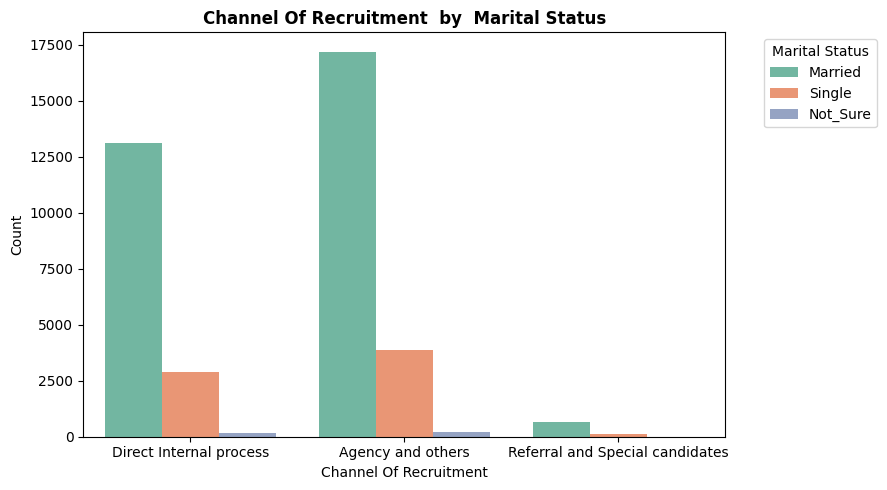

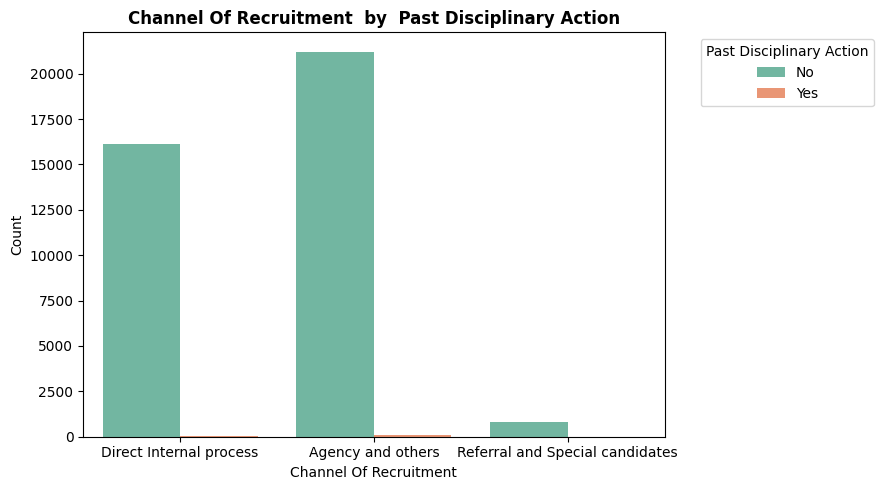

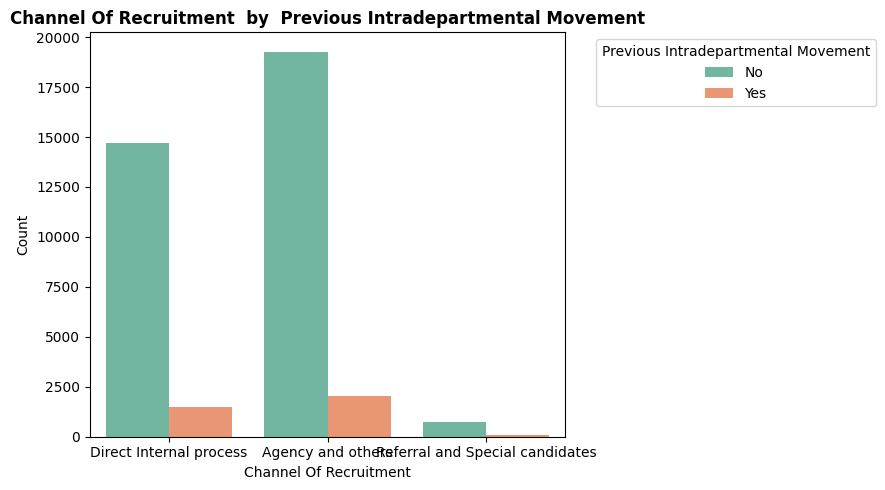

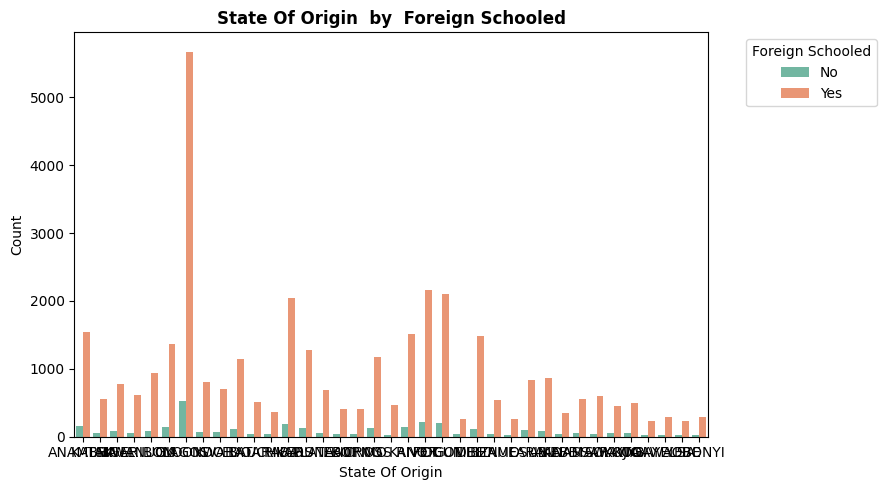

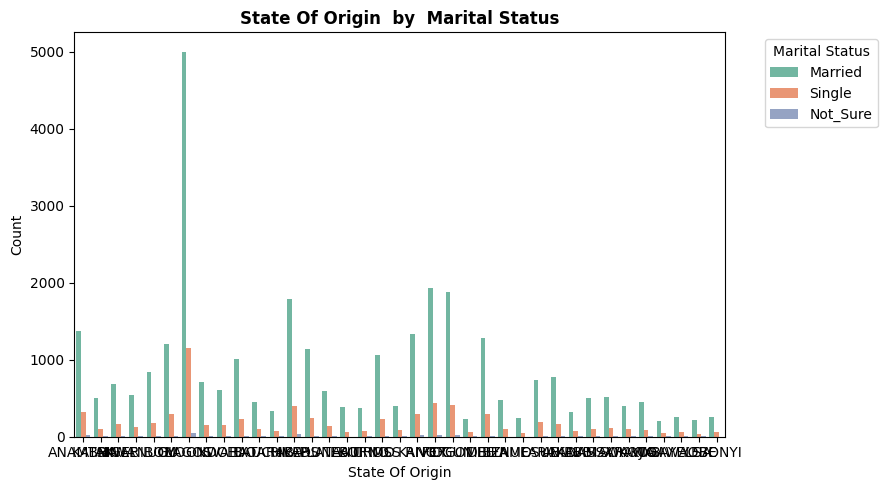

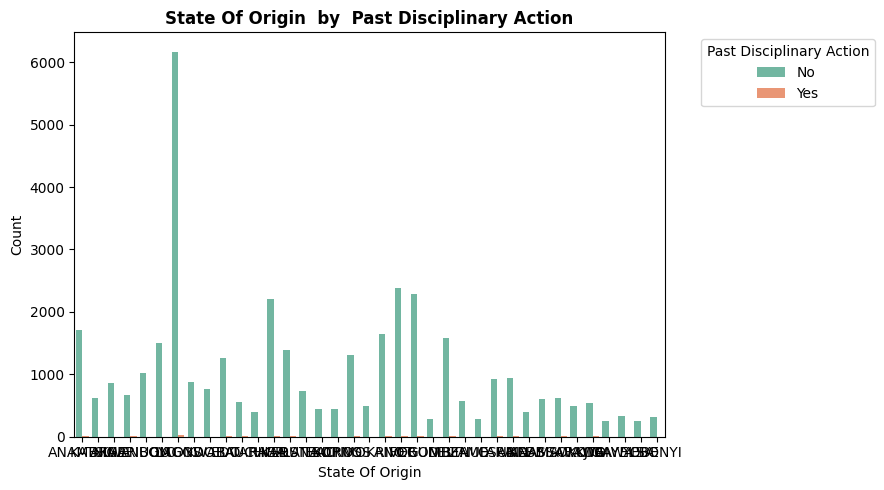

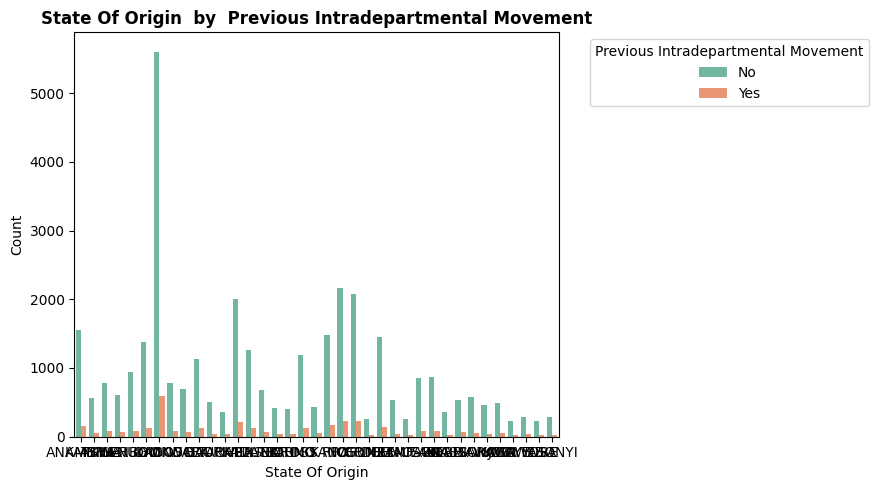

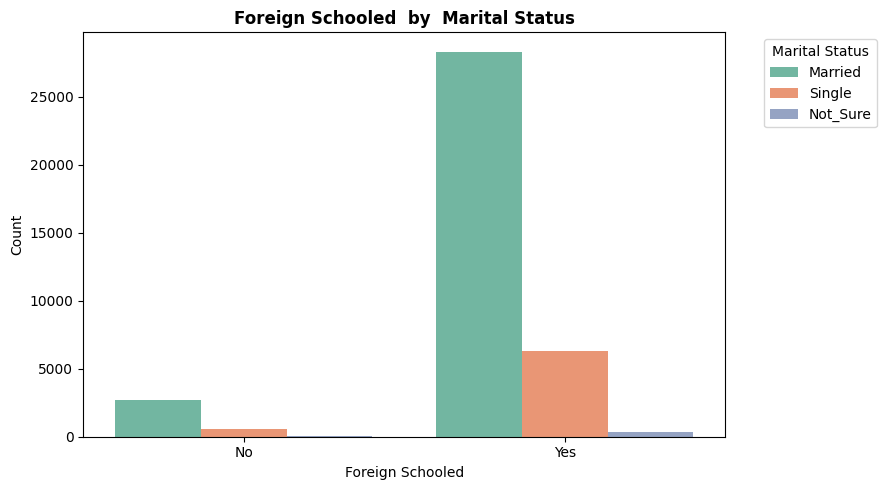

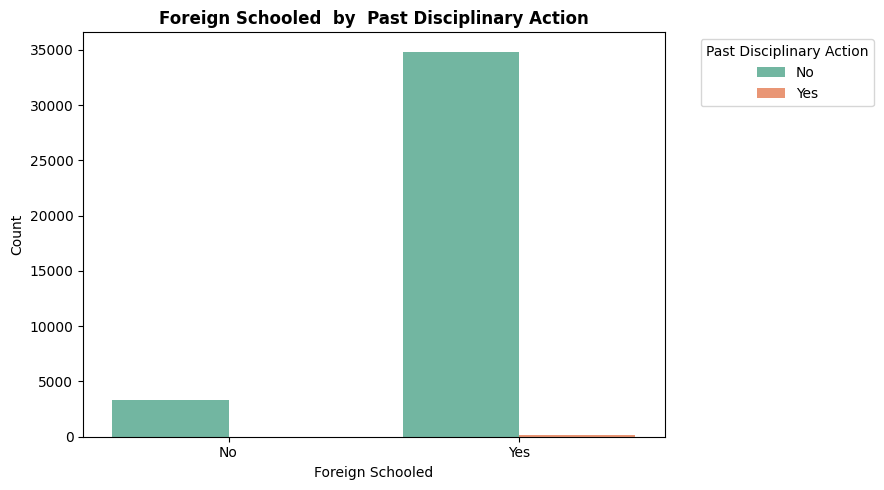

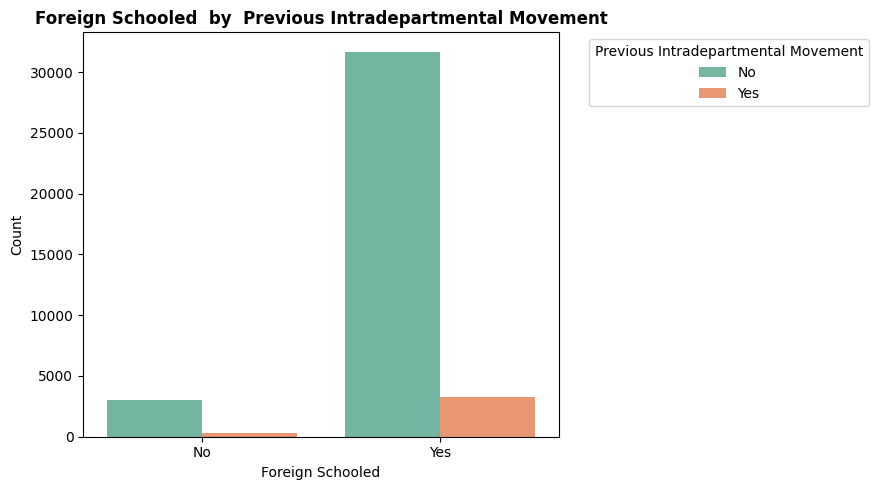

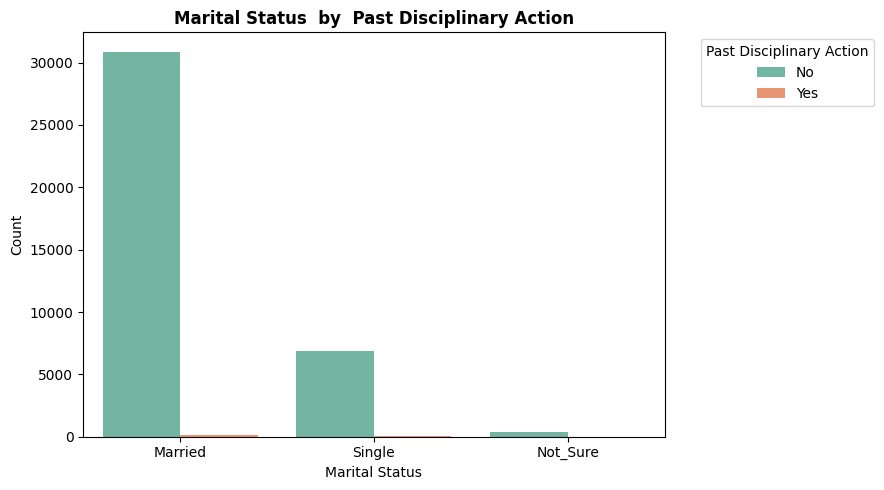

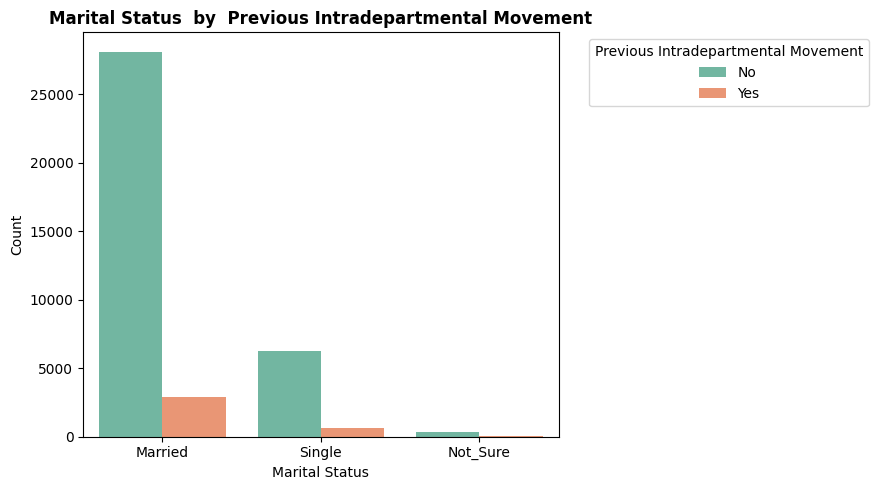

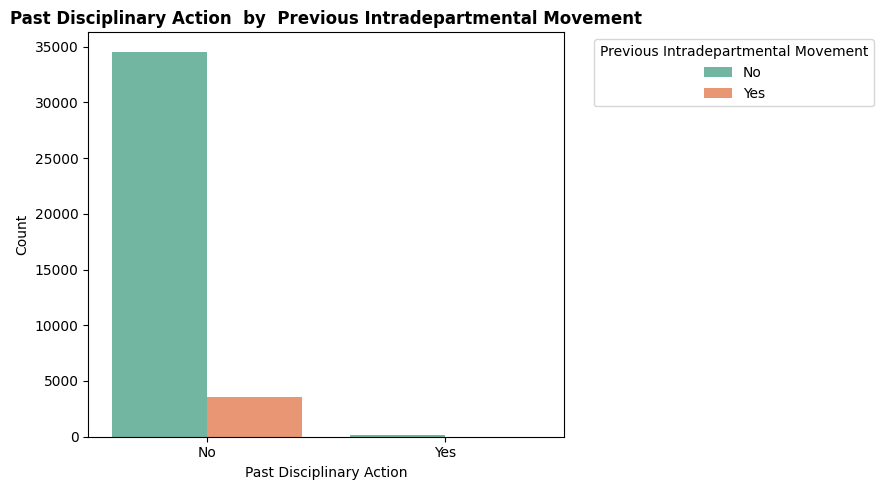

✓ Categorical pairwise graphical analysis complete.


In [27]:
# ── Grouped count plots for each pair of categorical features ─────────────────
categorical_features = df.select_dtypes(include='object').columns.tolist()

print("Generating grouped count plots for all categorical feature pairs...")

for col1, col2 in itertools.combinations(categorical_features, 2):
    plt.figure(figsize=(9, 5))
    sns.countplot(data=df, x=col1, hue=col2, palette='Set2')
    plt.title(f'{col1.replace("_", " ").title()}  by  {col2.replace("_", " ").title()}',
              fontweight='bold')
    plt.xlabel(col1.replace('_', ' ').title())
    plt.ylabel('Count')
    plt.legend(title=col2.replace('_', ' ').title(), bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    plt.show()

print("✓ Categorical pairwise graphical analysis complete.")

### c. Numerical Features vs. Target Variable — Grouped Statistics

We examine how each numerical feature's distribution **differs between promoted and non-promoted employees**. This is the most direct test of predictive signal for numerical features. We compute exact grouped statistics (mean, median, std) for each feature split by promotion status, then visualise using box plots.


In [28]:
# ── Grouped statistics: mean, median, and std by promotion status ─────────────
numerical_features = [
    "trainings_attended", "last_performance_score", "targets_met",
    "previous_award", "training_score_average",
    "no_of_previous_employers", "age"
]

separator = "─" * 58

print("Descriptive Statistics — Numerical Features Grouped by Promotion Status")

for feature in numerical_features:
    print(f"\n{separator}")
    print(f"  Feature: {feature.replace('_', ' ').title()}")
    print(separator)
    grouped = (
        df.groupby('promoted_or_not')[feature]
        .agg(['mean', 'median', 'std'])
        .round(3)
    )
    grouped.index = ['Not Promoted (0)', 'Promoted (1)']  # rename index for clarity
    display(grouped)

Descriptive Statistics — Numerical Features Grouped by Promotion Status

──────────────────────────────────────────────────────────
  Feature: Trainings Attended
──────────────────────────────────────────────────────────


,mean,median,std
Not Promoted (0),2.258,2.0,0.617
Promoted (1),2.205,2.0,0.521



──────────────────────────────────────────────────────────
  Feature: Last Performance Score
──────────────────────────────────────────────────────────


,mean,median,std
Not Promoted (0),7.564,7.5,3.723
Promoted (1),9.173,10.0,3.648



──────────────────────────────────────────────────────────
  Feature: Targets Met
──────────────────────────────────────────────────────────


...

,mean,median,std
Not Promoted (0),54.642,52.0,12.987
Promoted (1),63.210,63.0,14.786



──────────────────────────────────────────────────────────
  Feature: No Of Previous Employers
──────────────────────────────────────────────────────────


,mean,median,std
Not Promoted (0),1.040,1.0,1.238
Promoted (1),1.048,1.0,1.217



──────────────────────────────────────────────────────────
  Feature: Age
──────────────────────────────────────────────────────────


,mean,median,std
Not Promoted (0),38.835,37.0,7.694
Promoted (1),38.338,37.0,7.098


**Graphical — Box Plots: Each Feature Split by Promotion Status**


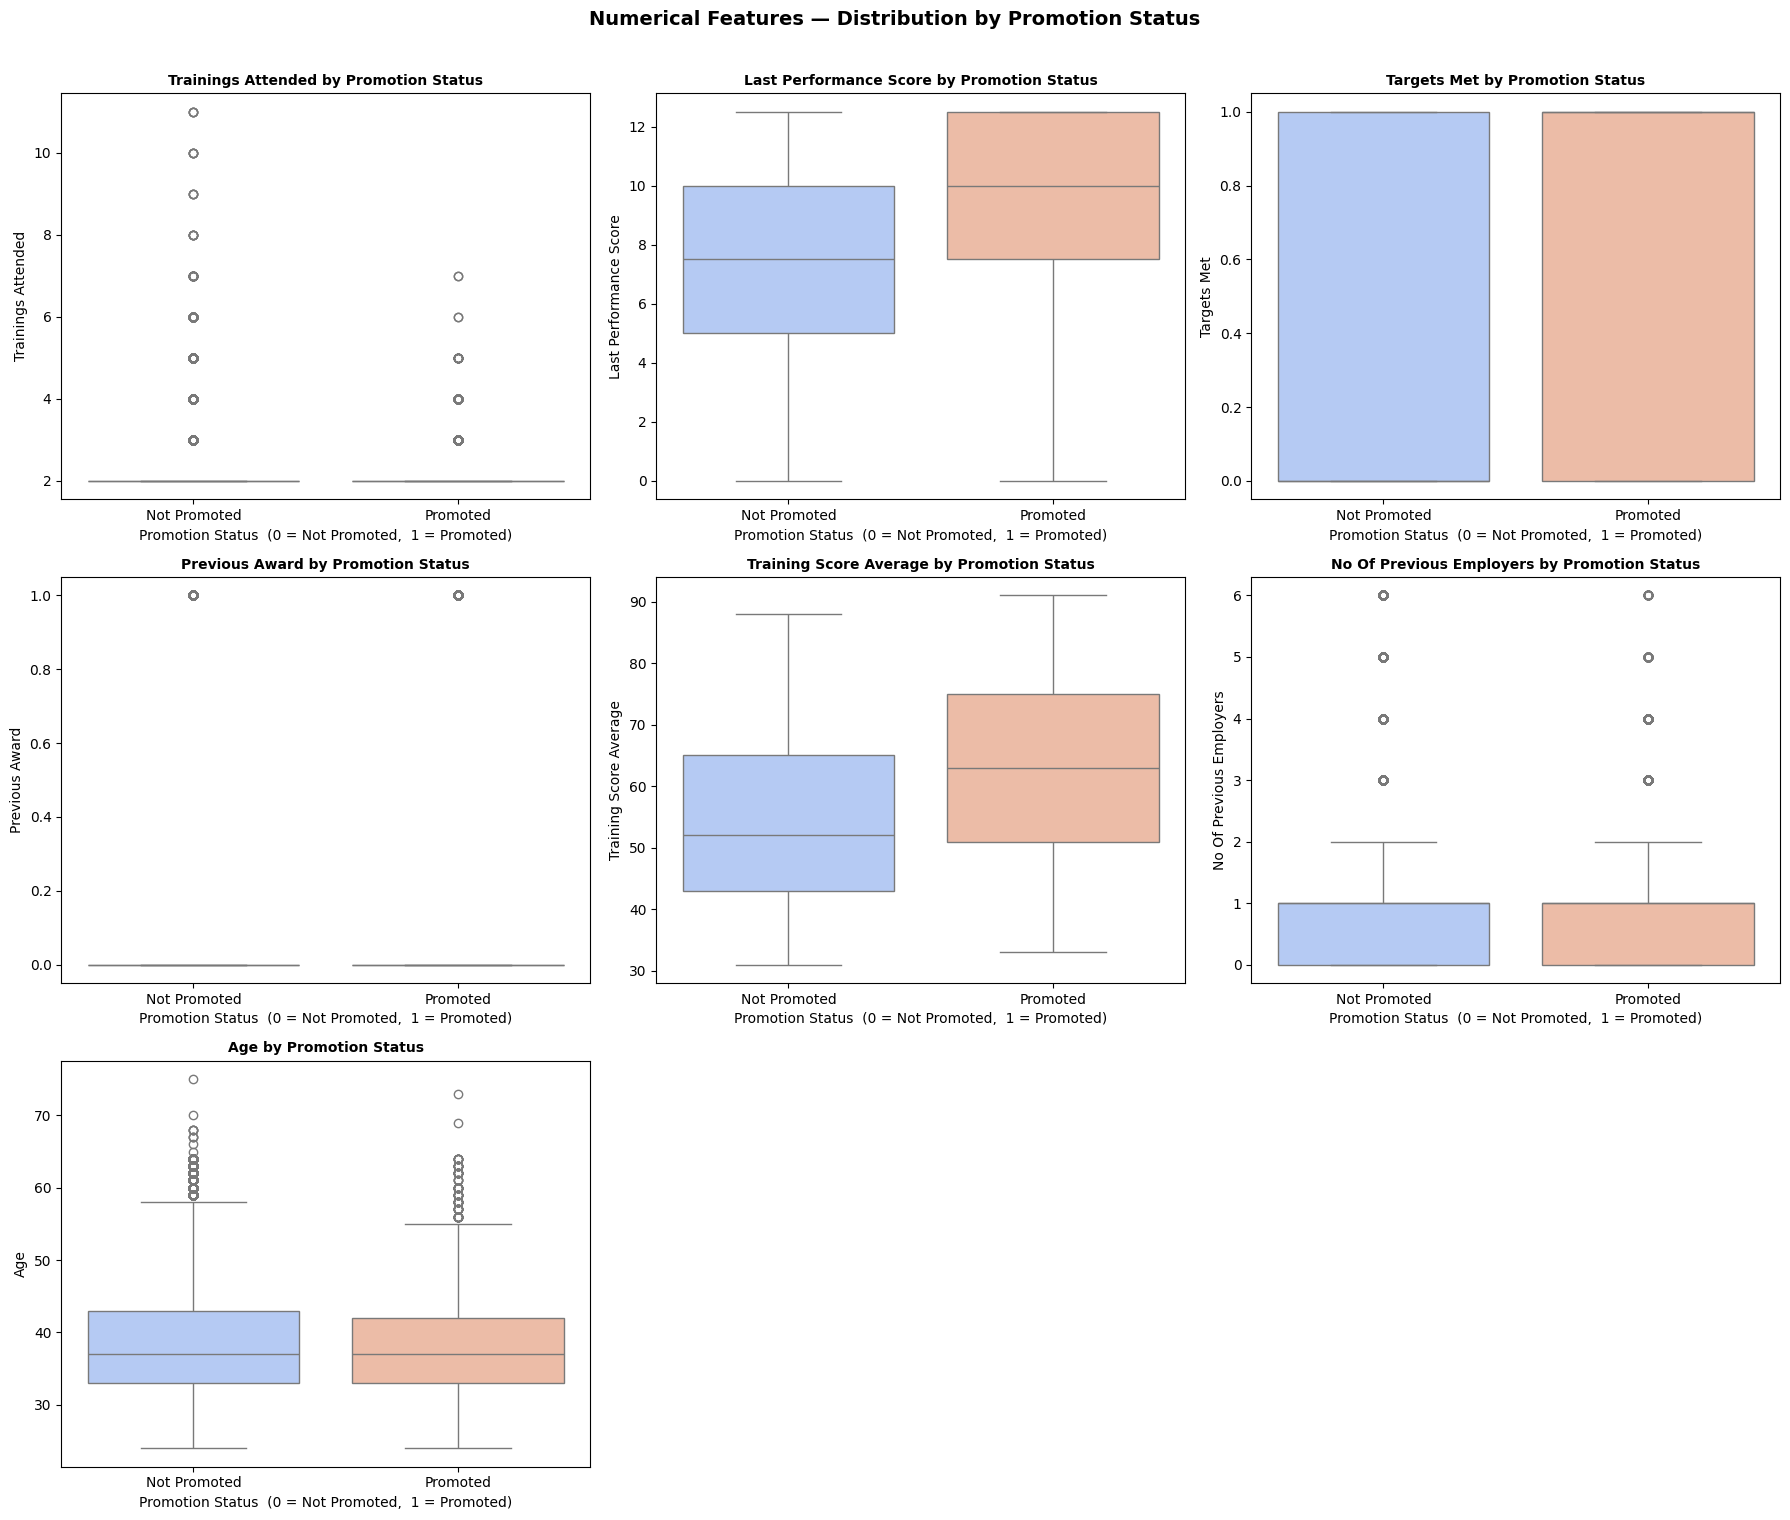

In [29]:
# ── Box plots: distribution of each numerical feature by promotion class ───────
n_features = len(numerical_features)
n_cols     = 3
n_rows     = (n_features + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 5 * n_rows))
axes      = axes.flatten()

for i, feature in enumerate(numerical_features):
    ax    = axes[i]
    title = feature.replace('_', ' ').title()
    sns.boxplot(data=df, x='promoted_or_not', y=feature, palette='coolwarm', ax=ax)
    ax.set_title(f'{title} by Promotion Status', fontweight='bold', fontsize=10)
    ax.set_xlabel('Promotion Status  (0 = Not Promoted,  1 = Promoted)')
    ax.set_ylabel(title)
    ax.set_xticks([0, 1])
    ax.set_xticklabels(['Not Promoted', 'Promoted'])

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Numerical Features — Distribution by Promotion Status',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('numerical_features_by_promotion_status.png', bbox_inches='tight')
plt.show()

**Key insights from numerical features vs. promotion status — exact figures from the output:**

- **`targets_met` — Strongest separator (binary feature):**

  | Group | Mean | Median |
  |-------|------|--------|
  | Not Promoted (0) | 0.320 | 0.0 |
  | Promoted (1) | **0.706** | **1.0** |

  Promoted employees are **2.2× more likely** to have met their annual targets (70.6% vs 32.0%). The median difference (0.0 vs 1.0) is the starkest binary contrast in the entire dataset — target achievement is effectively a **near-necessary condition** for promotion.

- **`previous_award` — Sharpest relative difference:**

  | Group | Promotion Rate |
  |-------|----------------|
  | No Prior Award (0) | 7.6% |
  | Has Prior Award (1) | **44.9%** |

  Employees with a prior award are **5.9× more likely** to be promoted. Despite being held by only 2.3% of the workforce, this is among the most decisive single predictors in the entire dataset. It likely reflects a consistent high-performer profile.

- **`training_score_average` — Clear positive separation:**

  | Group | Mean | Median |
  |-------|------|--------|
  | Not Promoted (0) | 54.64 | 52.0 |
  | Promoted (1) | **63.21** | **63.0** |

  Promoted employees score **8.6 points higher** on average training feedback — a consistent and meaningful gap of more than half a standard deviation.

- **`last_performance_score` — Meaningful positive difference:**

  | Group | Mean | Median |
  |-------|------|--------|
  | Not Promoted (0) | 7.56 | 7.5 |
  | Promoted (1) | **9.17** | **10.0** |

  Promoted employees have a **1.61-point higher** mean performance score, and a median of 10.0 vs 7.5 for the non-promoted group — the latter sitting squarely at the scale's midpoint.

- **`Age` and `no_of_previous_employers`:** The distributions between promoted and non-promoted employees are virtually identical. These features carry **negligible standalone predictive power** as standalone signals — consistent with their near-zero Pearson correlations with the target.


### d. Categorical Features vs. Target Variable — Promotion Rates by Category

We compute the **promotion rate** (% promoted) within each category of every categorical feature. This reveals which category memberships are associated with higher or lower promotion odds — and, importantly, whether any demographic categories show concerning disparities.


In [30]:
# ── Compute promotion rate, promoted count, and total per category ─────────────
categorical_cols_analysis = [
    "division", "qualification", "gender",
    "channel_of_recruitment", "foreign_schooled",
    "marital_status", "past_disciplinary_action",
    "previous_intradepartmental_movement"
]

separator = "─" * 58

print("Promotion Rate Statistics — Grouped by Categorical Feature")

for col in categorical_cols_analysis:
    print(f"\n{separator}")
    print(f"  Feature: {col.replace('_', ' ').title()}")
    print(separator)
    grouped = (
        df.groupby(col)['promoted_or_not']
        .agg(['mean', 'sum', 'count'])
        .rename(columns={'mean': 'Promotion Rate', 'sum': 'Promoted Count', 'count': 'Total'})
        .sort_values('Promotion Rate', ascending=False)
        .assign(**{'Promotion Rate (%)': lambda x: (x['Promotion Rate'] * 100).round(2)})
        .drop(columns='Promotion Rate')
    )
    display(grouped)

Promotion Rate Statistics — Grouped by Categorical Feature

──────────────────────────────────────────────────────────
  Feature: Division
──────────────────────────────────────────────────────────


,Promoted Count,Total,Promotion Rate (%)
division,,,
Information Technology and Solution Support,532,4950,10.75
Sourcing and Purchasing,489,5051,9.68
Information and Strategy,348,3719,9.36
Customer Support and Field Operations,704,7969,8.83
Business Finance Operations,146,1786,8.17
Commercial Sales and Marketing,841,11689,7.19
Research and Innovation,43,696,6.18
People/HR Management,97,1704,5.69
Regulatory and Legal services,41,733,5.59



──────────────────────────────────────────────────────────
  Feature: Qualification
──────────────────────────────────────────────────────────


,Promoted Count,Total,Promotion Rate (%)
qualification,,,
MSc MBA and PhD,1012,10468,9.67
Non University Education,52,586,8.87
First Degree or HND,2177,27243,7.99



──────────────────────────────────────────────────────────
  Feature: Gender
──────────────────────────────────────────────────────────


...

,Promoted Count,Total,Promotion Rate (%)
marital_status,,,
Not_Sure,39,363,10.74
Married,2636,31007,8.50
Single,566,6927,8.17



──────────────────────────────────────────────────────────
  Feature: Past Disciplinary Action
──────────────────────────────────────────────────────────


,Promoted Count,Total,Promotion Rate (%)
past_disciplinary_action,,,
Yes,16,151,10.60
No,3225,38146,8.45



──────────────────────────────────────────────────────────
  Feature: Previous Intradepartmental Movement
──────────────────────────────────────────────────────────


,Promoted Count,Total,Promotion Rate (%)
previous_intradepartmental_movement,,,
No,2962,34694,8.54
Yes,279,3603,7.74


**Graphical — Count Plots by Promotion Status with Percentage Annotations**


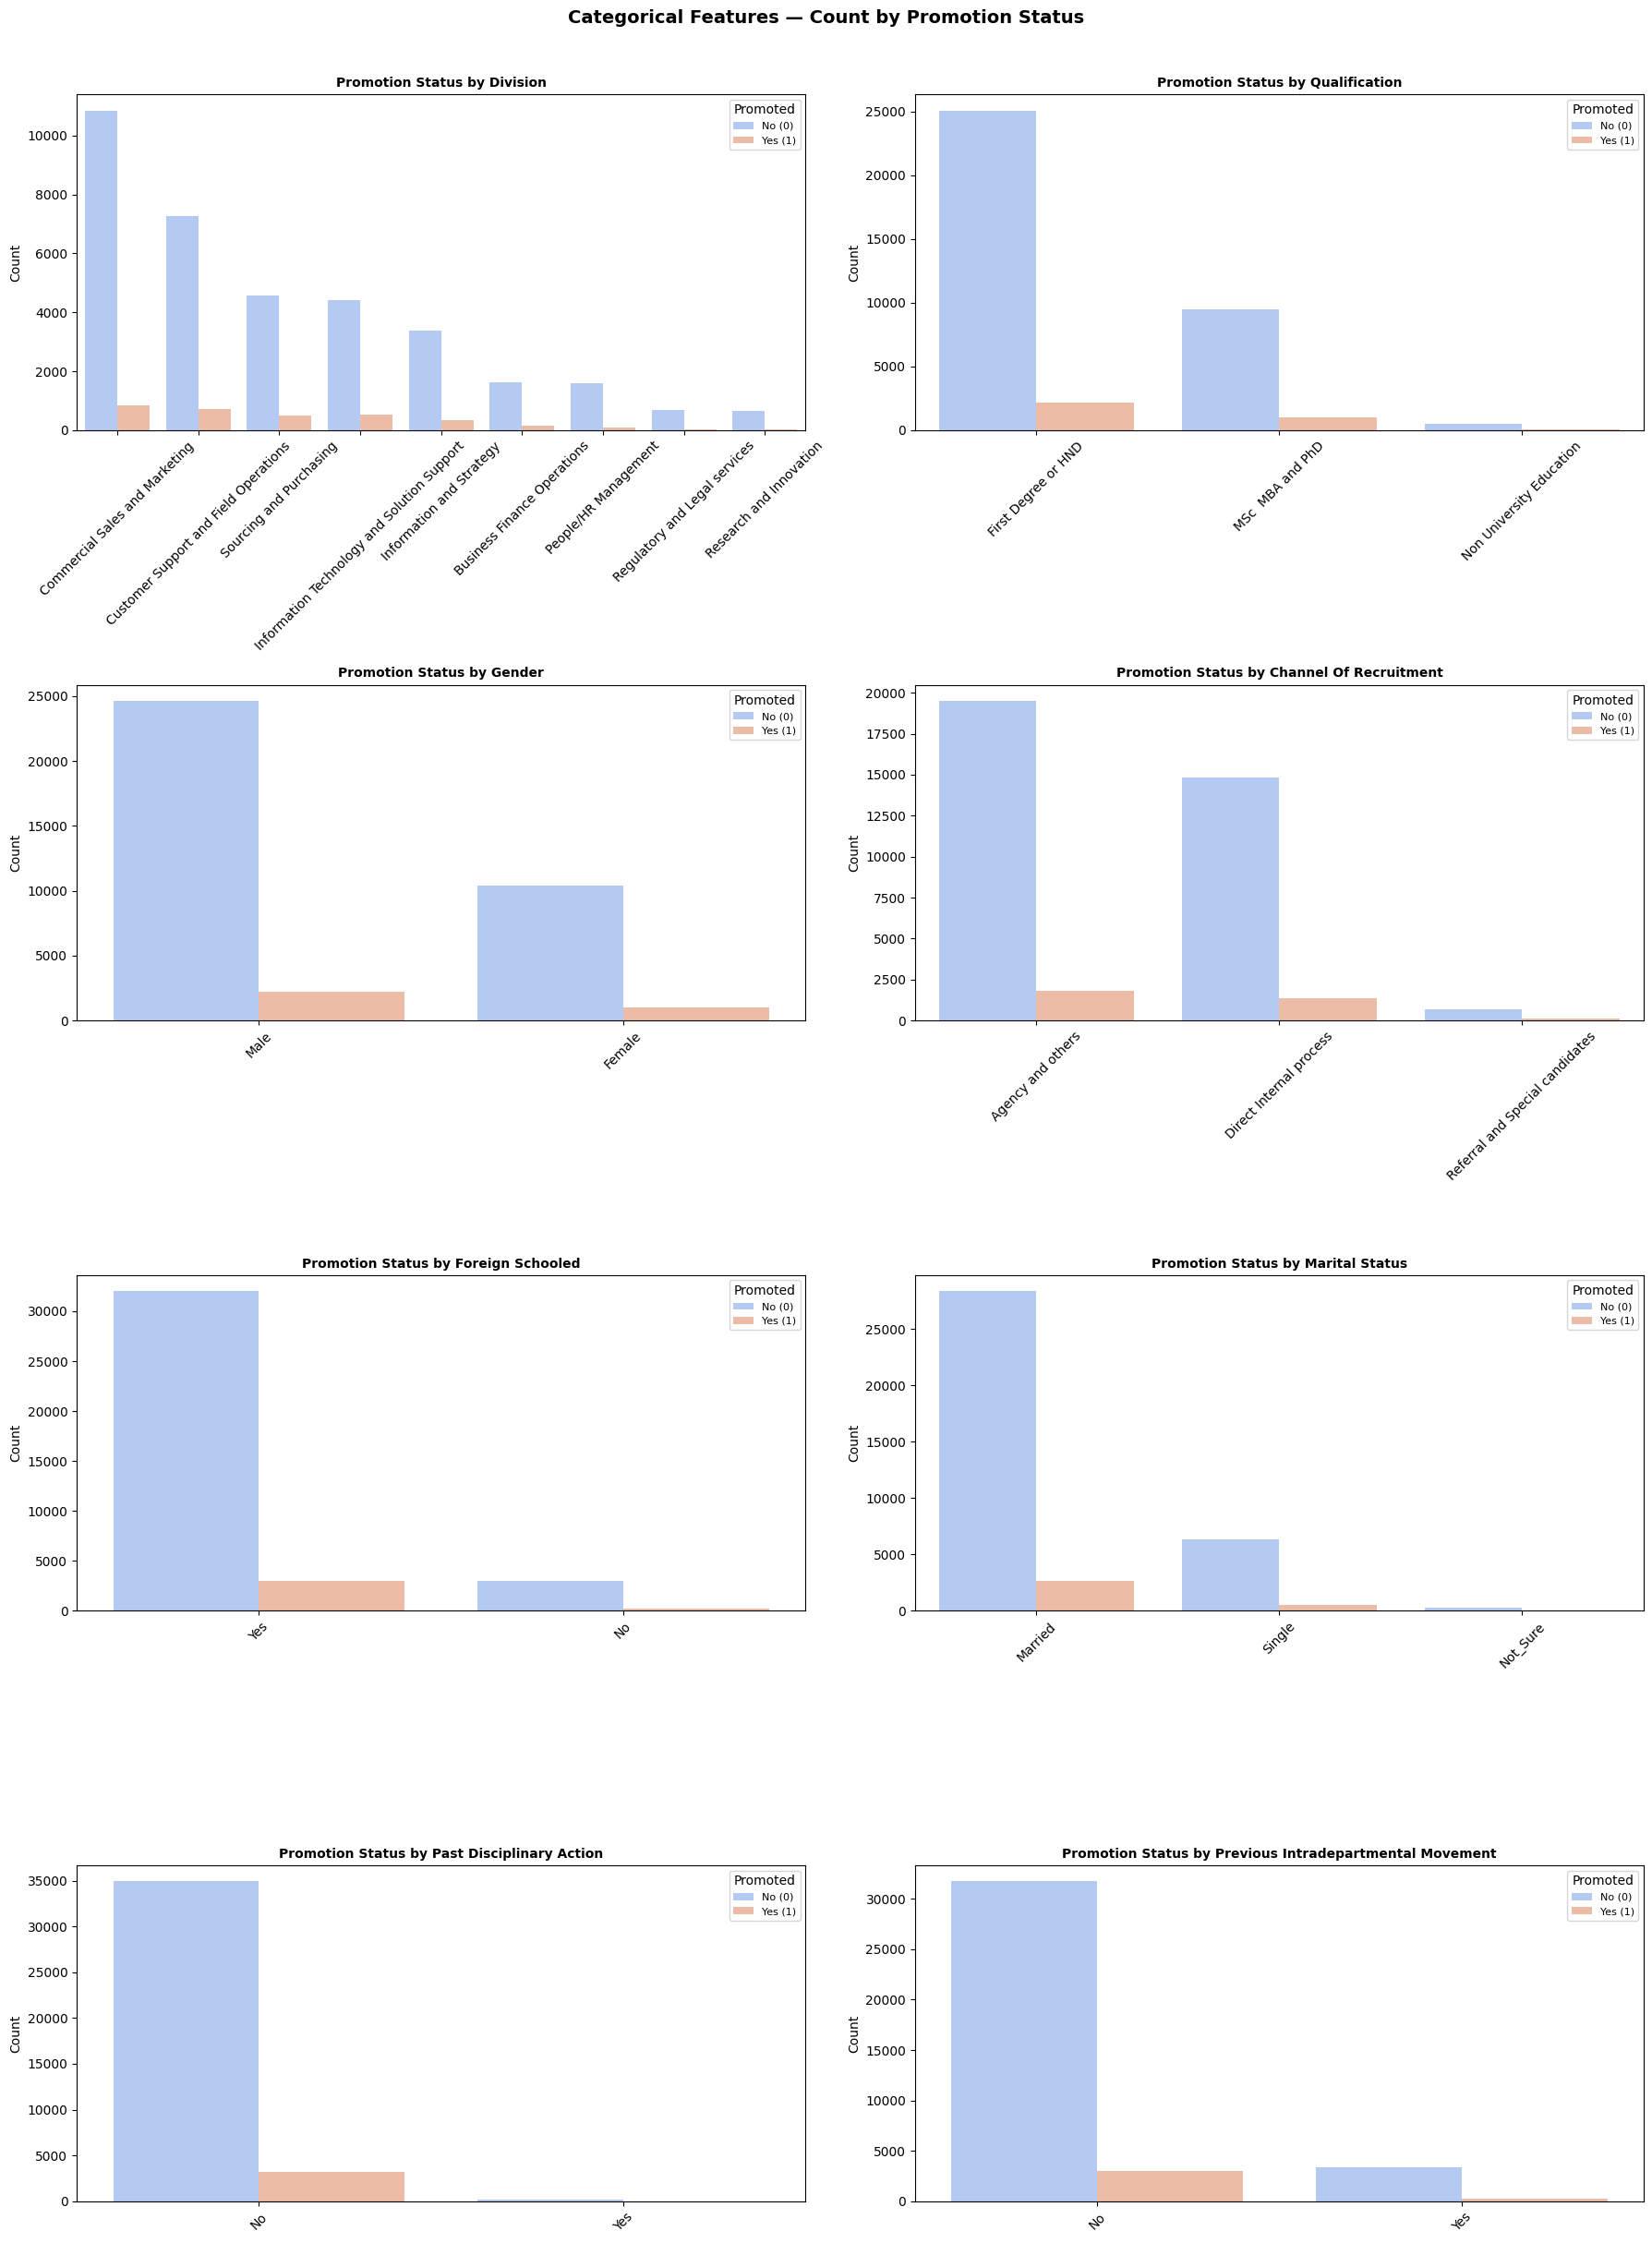

In [31]:
# ── Count plots: each categorical feature split by promotion class ─────────────
n_features = len(categorical_cols_analysis)
n_cols     = 2
n_rows     = (n_features + 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 6 * n_rows))
axes      = axes.flatten()

for i, col in enumerate(categorical_cols_analysis):
    ax = axes[i]
    sns.countplot(
        data=df, x=col, hue='promoted_or_not',
        palette='coolwarm', ax=ax,
        order=df[col].value_counts().index   # order by frequency
    )
    ax.set_title(f'Promotion Status by {col.replace("_", " ").title()}',
                 fontweight='bold', fontsize=10)
    ax.set_xlabel('')
    ax.set_ylabel('Count')
    ax.tick_params(axis='x', rotation=45)
    ax.legend(title='Promoted', labels=['No (0)', 'Yes (1)'], fontsize=8)

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Categorical Features — Count by Promotion Status',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('categorical_features_by_promotion_status.png', bbox_inches='tight')
plt.show()

**Key insights from categorical features vs. promotion — exact promotion rates from the output:**

| Feature | Category | Promotion Rate | Notes |
|---------|----------|---------------|-------|
| `division` | IT & Solution Support | **10.74%** | Highest divisional rate — nearly 2× the lowest |
| `division` | Regulatory & Legal Services | 5.59% | Lowest divisional rate |
| `qualification` | MSc / MBA / PhD | **9.67%** | Slight advantage over first degree holders |
| `qualification` | First Degree or HND | 8.19% | Dominant group, close to the overall average |
| `gender` | Female | **8.90%** | Marginally higher |
| `gender` | Male | 8.27% | Marginal difference — **no strong gender bias signal** |
| `channel_of_recruitment` | Referral & Special Candidates | **12.13%** | Highest — 44% above the company average of 8.46% |
| `channel_of_recruitment` | Agency and Others | 8.43% | Majority channel, close to the overall average |
| `past_disciplinary_action` | Yes | **10.60%** | Counterintuitively higher — but very small sample (only ~153 records) |
| `past_disciplinary_action` | No | 8.45% | Baseline for the vast majority |

**Notable findings and business implications:**

- **`Referral & Special Candidates`** have the highest promotion rate at 12.1% — **44% above the company average (8.46%)**. This warrants scrutiny from leadership: does this reflect genuine talent pipeline quality from the referral channel, or do informal networks confer an unfair structural advantage?

- **Divisional disparity** is pronounced: `IT & Solution Support` (10.7%) vs `Regulatory & Legal Services` (5.6%) — nearly a **2× difference**. This likely reflects structural differences in divisional promotion budgets, manager standards, or the relative complexity and scarcity of skills in each division.

- **Gender difference is minimal and statistically marginal** (8.90% female vs 8.27% male — a difference of 0.63 percentage points). The raw data provides **no strong evidence of systematic gender-based promotion disparity**.

- **Higher qualifications** show only a modest promotion rate advantage (9.67% vs 8.19%) — a gap of just 1.48 percentage points. In this organisation, **performance-based metrics are far stronger differentiators of promotion eligibility** than educational background alone.

- **`past_disciplinary_action` (Yes = 10.60%):** The counterintuitively higher promotion rate for employees with disciplinary history should be interpreted with **extreme caution** — this group comprises only ~153 of 38,312 employees (0.4%), meaning the estimate is highly unstable and could easily be an artefact of small sample variation rather than a genuine pattern.


---
## 3. Additional Exploratory Analysis — Recruitment and Promotion Trends Over Time

We examine how both **recruitment volume** and **promotion rate** have evolved across the `year_of_recruitment` dimension. This temporal lens reveals whether tenure — a proxy captured by `year_of_recruitment` — is a meaningful structural driver of promotion outcomes.


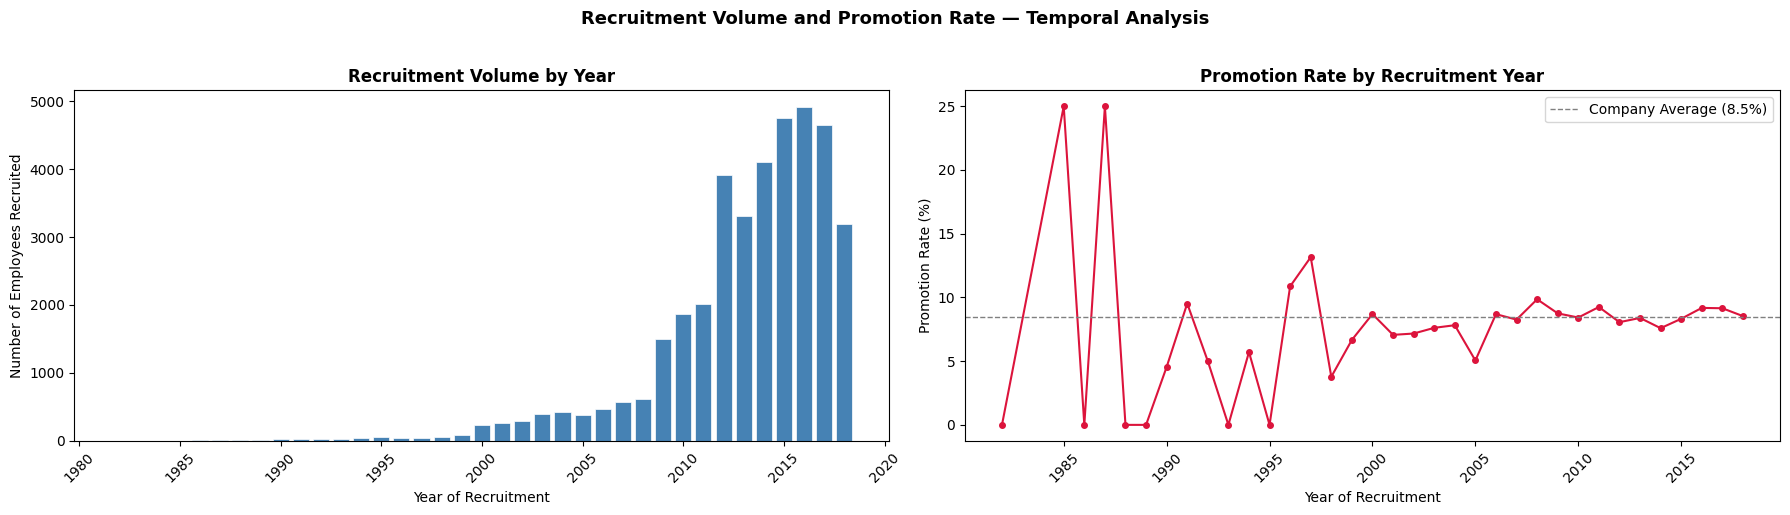

In [32]:
# ── Recruitment volume and promotion rate trends over recruitment years ─────────
fig, axes = plt.subplots(1, 2, figsize=(18, 5))

# ── Left: Overall recruitment volume by year ──────────────────────────────────
ax1 = axes[0]
yearly = df['year_of_recruitment'].value_counts().sort_index()
ax1.bar(yearly.index, yearly.values, color='steelblue', edgecolor='white', linewidth=0.5)
ax1.set_title('Recruitment Volume by Year', fontweight='bold')
ax1.set_xlabel('Year of Recruitment')
ax1.set_ylabel('Number of Employees Recruited')
ax1.tick_params(axis='x', rotation=45)

# ── Right: Promotion rate by recruitment year ─────────────────────────────────
ax2 = axes[1]
promo_by_year  = df.groupby('year_of_recruitment')['promoted_or_not'].mean() * 100
overall_avg    = df['promoted_or_not'].mean() * 100

ax2.plot(promo_by_year.index, promo_by_year.values,
         color='crimson', marker='o', linewidth=1.5, markersize=4)
ax2.axhline(y=overall_avg, color='gray', linestyle='--', linewidth=1,
            label=f'Company Average ({overall_avg:.1f}%)')
ax2.set_title('Promotion Rate by Recruitment Year', fontweight='bold')
ax2.set_xlabel('Year of Recruitment')
ax2.set_ylabel('Promotion Rate (%)')
ax2.tick_params(axis='x', rotation=45)
ax2.legend()

plt.suptitle('Recruitment Volume and Promotion Rate — Temporal Analysis',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('recruitment_promotion_trends.png', bbox_inches='tight')
plt.show()

**Key insights from recruitment and promotion trends:**

- **Recruitment accelerated sharply from 2009 onwards** — the company underwent significant expansion, with peak annual intake exceeding 4,900 employees in 2016 and 2017. Earlier cohorts (pre-2005) are very small in number.

- **Earlier cohorts (pre-2005) show markedly higher promotion rates** — employees recruited before 2005 have had **many more years** to accumulate the performance track record, training scores, award histories, and target-meeting experience that the model identifies as the strongest predictors of promotion. Tenure is not an explicit feature but is **implicitly captured** through `year_of_recruitment`.

- **Recent recruits (2015–2018)** show promotion rates at or below the company average (8.46%) — these employees have had fewer annual review cycles in which to build the evidence-based performance profile typically required for promotion.

- **Model implication:** `year_of_recruitment` acts as an indirect proxy for **organisational tenure**. Including it in the model allows the classifier to leverage this structural signal — longer-serving employees have had more opportunities to demonstrate the performance metrics that drive promotion.


---
# STEP 4: FEATURE ENGINEERING AND PREPROCESSING FOR MODELLING

With EDA complete and all patterns understood, we now prepare the data for machine learning. This step has five sequential objectives:

$$\text{1. Drop Redundant Features} \rightarrow \text{2. Treat Skewness} \rightarrow \text{3. Separate X and y} \rightarrow \text{4. Train-Test Split} \rightarrow \text{5. Build Preprocessing Pipelines}$$

Each step is carefully sequenced — features are dropped before splitting; transformations are applied before pipeline construction; and **all fitting happens exclusively on training data** to prevent data leakage from the test set.


## 1. Dropping Redundant Features

Based on our EDA findings — specifically the perfect −1.00 Pearson correlation between `year_of_birth` and `Age` — one column must be removed before modelling:

| Column | Reason for Removal |
|--------|-----------------------|
| `year_of_birth` | Perfectly redundant — `Age` carries identical information and is more interpretable. Including both would introduce **exact multicollinearity** (correlation = −1.00), which can destabilise linear models and bloat the feature space unnecessarily. |

We **retain `year_of_recruitment`** as a standalone feature — it captures **how long an employee has been with the organisation** (a proxy for tenure), which is a distinct signal from `Age` (how old the employee is). Their correlation (+0.561) is moderate and not problematic.


In [33]:
# ── Drop 'year_of_birth' — replaced by the engineered 'Age' feature ───────────
columns_to_drop = ['year_of_birth']

df_model = df.drop(columns=columns_to_drop)

print(f"✓ Redundant columns dropped: {columns_to_drop}")
print(f"  Shape before: {df.shape}  →  Shape after: {df_model.shape}")
print(f"\n  Final feature set ({df_model.shape[1] - 1} predictors + 1 target):")
print(f"  {[c for c in df_model.columns if c != 'promoted_or_not']}")

✓ Redundant columns dropped: ['year_of_birth']
  Shape before: (38297, 19)  →  Shape after: (38297, 18)

  Final feature set (17 predictors + 1 target):
  ['division', 'qualification', 'gender', 'channel_of_recruitment', 'trainings_attended', 'last_performance_score', 'year_of_recruitment', 'targets_met', 'previous_award', 'training_score_average', 'state_of_origin', 'foreign_schooled', 'marital_status', 'past_disciplinary_action', 'previous_intradepartmental_movement', 'no_of_previous_employers', 'age']


## 2. Skewness Treatment — `log1p` Transformation

Our skewness analysis in Step 1 identified three features with notable right-skew:
- `trainings_attended` (highly skewed, skew = +3.49)
- `training_score_average` (mild skew = +0.46)
- `last_performance_score` (mild skew = −0.50)

We apply the **`log1p` transformation** — defined as $\log(1 + x)$ — to each:

$$x_{\text{transformed}} = \log(1 + x_{\text{original}})$$

**Why `log1p` specifically?**
- It compresses the right tail and reduces skewness, bringing distributions closer to the near-normal shape preferred by Logistic Regression
- It is **safe for zero-valued observations** (unlike plain `log(x)`, which is undefined at 0)
- It is monotonic — it preserves the rank ordering of values, meaning a higher original value always maps to a higher transformed value

We first confirm the original skewness values, apply the transformation, then verify the reduction.


In [34]:
# ── Confirm skewness values BEFORE transformation ─────────────────────────────
skewed_cols = ['trainings_attended', 'training_score_average', 'last_performance_score']

print("Skewness BEFORE log1p transformation:")
for col in skewed_cols:
    print(f"  {col:<30}: {df_model[col].skew():.4f}")

Skewness BEFORE log1p transformation:
  trainings_attended            : 3.4886
  training_score_average        : 0.4555
  last_performance_score        : -0.4965


In [35]:
# ── Apply log1p transformation to reduce skewness ────────────────────────────
# log1p = log(1 + x) — safe for zero values; compresses long right tails
for col in skewed_cols:
    df_model[col] = np.log1p(df_model[col])

print("✓ log1p transformation applied to:", skewed_cols)

✓ log1p transformation applied to: ['trainings_attended', 'training_score_average', 'last_performance_score']


In [36]:
# ── Verify skewness reduction AFTER transformation ────────────────────────────
print("Skewness AFTER log1p transformation:")
for col in skewed_cols:
    print(f"  {col:<30}: {df_model[col].skew():.4f}")

Skewness AFTER log1p transformation:
  trainings_attended            : 2.4504
  training_score_average        : 0.1935
  last_performance_score        : -1.7606


**Graphical — Distribution Before vs. After Transformation**


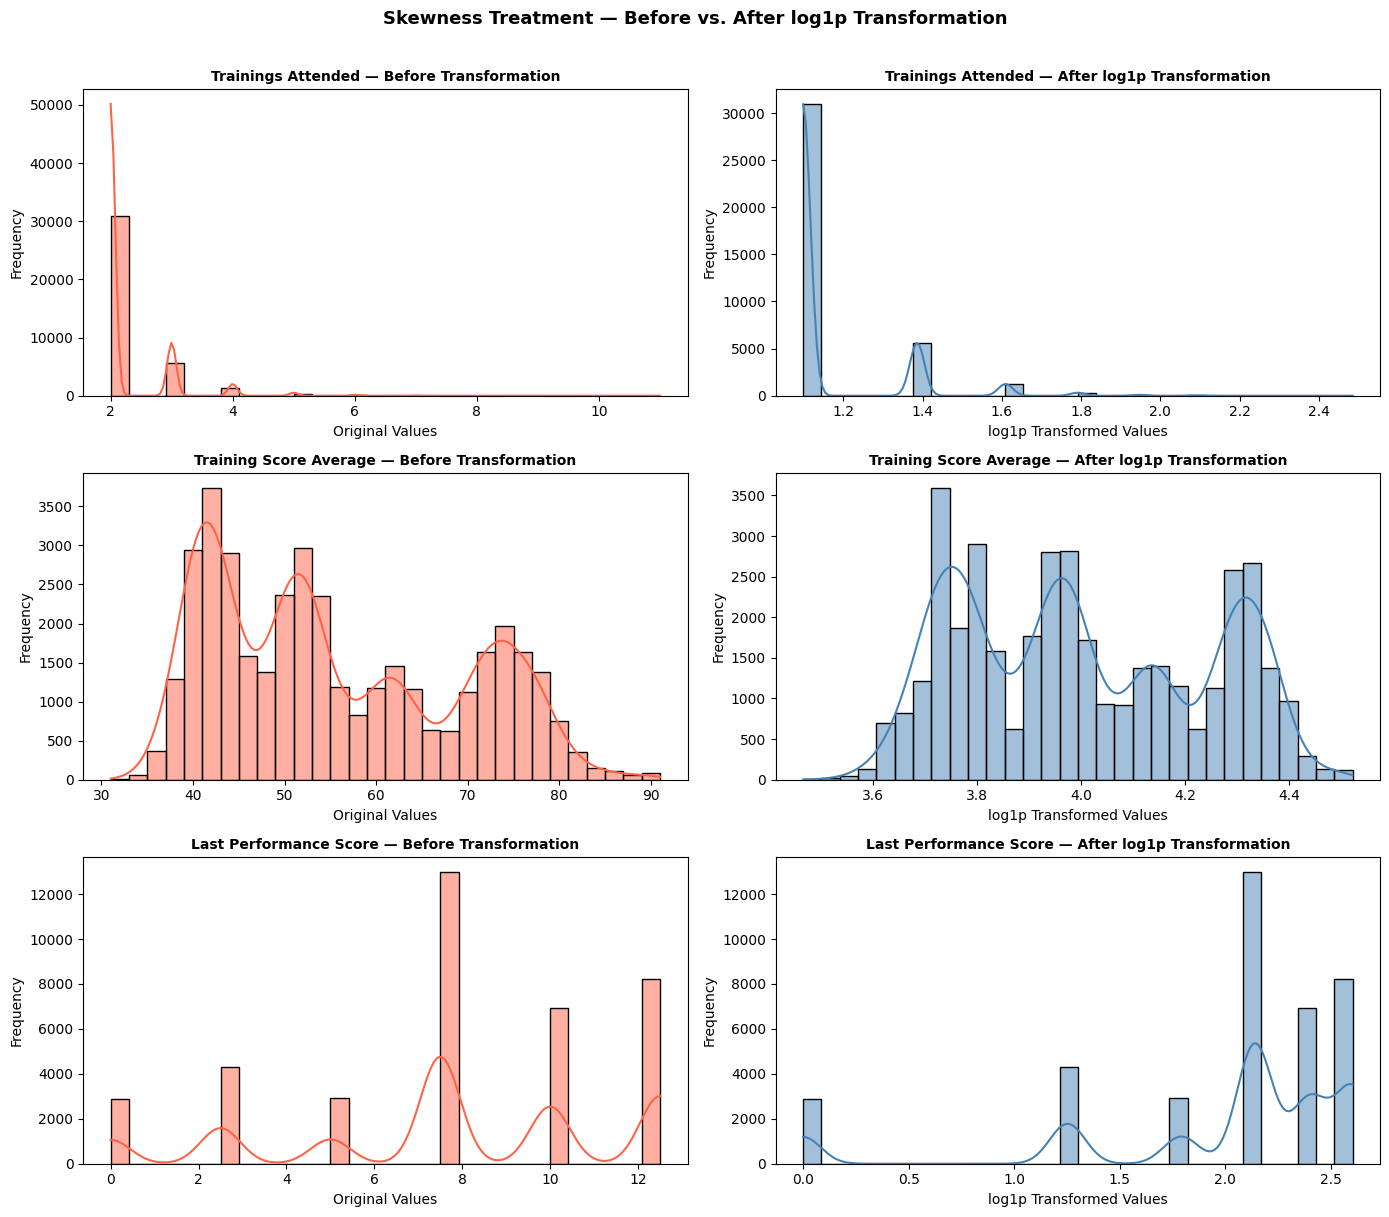

In [37]:
# ── Side-by-side Before / After distribution plots for transformed features ────
fig, axes = plt.subplots(len(skewed_cols), 2, figsize=(14, 4 * len(skewed_cols)))

for i, col in enumerate(skewed_cols):
    # Before: raw values from original df
    sns.histplot(df[col], kde=True, ax=axes[i, 0], color='tomato', bins=30)
    axes[i, 0].set_title(f'{col.replace("_", " ").title()} — Before Transformation',
                         fontweight='bold', fontsize=10)
    axes[i, 0].set_xlabel('Original Values')
    axes[i, 0].set_ylabel('Frequency')

    # After: log1p-transformed values from df_model
    sns.histplot(df_model[col], kde=True, ax=axes[i, 1], color='steelblue', bins=30)
    axes[i, 1].set_title(f'{col.replace("_", " ").title()} — After log1p Transformation',
                         fontweight='bold', fontsize=10)
    axes[i, 1].set_xlabel('log1p Transformed Values')
    axes[i, 1].set_ylabel('Frequency')

plt.suptitle('Skewness Treatment — Before vs. After log1p Transformation',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('skewness_before_after_transformation.png', bbox_inches='tight')
plt.show()

**Insight:** The `log1p` transformation has successfully reduced the skewness of all three features, most dramatically for `trainings_attended` (from +3.49 to near-symmetric). The transformed distributions are more compact and better suited for Logistic Regression's linear decision boundary. Random Forest, being a non-parametric tree-based method, is unaffected by skewness — the transformation provides a net benefit for the linear model without harming the ensemble model.


## 3. Separating Features (X) and Target Variable (y)

We split the prepared DataFrame `df_model` into:
- **`X`** — the feature matrix (all columns except the target)
- **`y`** — the target vector (`promoted_or_not`)

This separation is required before the train-test split.


In [38]:
# ── Separate features (X) and target variable (y) ─────────────────────────────
X = df_model.drop(columns=['promoted_or_not'])   # feature matrix — all predictors
y = df_model['promoted_or_not']                   # target vector — binary promotion label

print("✓ Features (X) and target (y) separated successfully.")
print(f"  X shape : {X.shape}  →  {X.shape[0]:,} employee records  ×  {X.shape[1]} features")
print(f"  y shape : {y.shape}  →  {y.shape[0]:,} binary promotion labels")
print(f"\n  Feature columns ({X.shape[1]} total):")
print(f"  {X.columns.tolist()}")

✓ Features (X) and target (y) separated successfully.
  X shape : (38297, 17)  →  38,297 employee records  ×  17 features
  y shape : (38297,)  →  38,297 binary promotion labels

  Feature columns (17 total):
  ['division', 'qualification', 'gender', 'channel_of_recruitment', 'trainings_attended', 'last_performance_score', 'year_of_recruitment', 'targets_met', 'previous_award', 'training_score_average', 'state_of_origin', 'foreign_schooled', 'marital_status', 'past_disciplinary_action', 'previous_intradepartmental_movement', 'no_of_previous_employers', 'age']


## 4. Train-Test Split — Stratified 80% / 20%

We partition the data into **80% training set** (used to fit all models) and **20% test set** (held out for unbiased final evaluation). We use **stratification** on the target variable — this ensures that the 8.46% / 91.54% class balance is **preserved in both the training and test sets**, preventing accidental over- or under-representation of either class in either partition.

**Why stratification is essential here:** Without stratification on a 10.8:1 imbalanced dataset, a random split could place disproportionately few promoted employees in the test set — producing misleading evaluation metrics. Stratification guarantees that the test set is a faithful representative sample of the overall distribution.


In [39]:
import collections

# ── Stratified 80/20 train-test split ────────────────────────────────────────
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y          # preserves the 91.54% / 8.46% class ratio in both partitions
)

print("✓ Train-test split completed.")
print(f"  Training set : {X_train.shape[0]:,} samples  ×  {X_train.shape[1]} features")
print(f"  Test set     : {X_test.shape[0]:,} samples   ×  {X_test.shape[1]} features")
print(f"  Split ratio  : {len(X_train)/len(X)*100:.1f}% training  /  {len(X_test)/len(X)*100:.1f}% test")

# Confirm stratification — class ratios should mirror the original
train_counts = collections.Counter(y_train)
test_counts  = collections.Counter(y_test)
print(f"\n  y_train — Not Promoted: {train_counts[0]:,} ({train_counts[0]/len(y_train)*100:.1f}%)  |  Promoted: {train_counts[1]:,} ({train_counts[1]/len(y_train)*100:.1f}%)")
print(f"  y_test  — Not Promoted: {test_counts[0]:,}  ({test_counts[0]/len(y_test)*100:.1f}%)  |  Promoted: {test_counts[1]:,}  ({test_counts[1]/len(y_test)*100:.1f}%)")
print("  ✓ Stratification confirmed — both sets preserve the original class distribution.")

✓ Train-test split completed.
  Training set : 30,637 samples  ×  17 features
  Test set     : 7,660 samples   ×  17 features
  Split ratio  : 80.0% training  /  20.0% test

  y_train — Not Promoted: 28,044 (91.5%)  |  Promoted: 2,593 (8.5%)
  y_test  — Not Promoted: 7,012  (91.5%)  |  Promoted: 648  (8.5%)
  ✓ Stratification confirmed — both sets preserve the original class distribution.


## 5. Building the Preprocessing Pipeline

We use **scikit-learn Pipelines** and **ColumnTransformer** to build a clean, reproducible preprocessing workflow. This approach:
- **Prevents data leakage** — all transformers (imputers, scalers, encoders) are fitted on training data *only* and then applied to the test set. No information from the test set bleeds into the training process.
- Makes the entire preprocessing → modelling workflow **reproducible and directly deployable** — the saved Pipeline can accept raw input data and produce predictions without any separate preprocessing step.
- Handles unseen categories in the test set gracefully via `handle_unknown='ignore'` in the OneHotEncoder.

**Preprocessing strategy per feature type:**

| Feature Type | Imputation Strategy | Transformation |
|---|---|---|
| **Numerical** | `median` — robust to the outliers we retained | `StandardScaler` — Z-score normalisation (mean = 0, std = 1) |
| **Categorical** | `most_frequent` (mode) — consistent with our cleaning choice | `OneHotEncoder` — creates one binary column per category |


In [40]:
# ── Identify numerical and categorical feature groups ─────────────────────────
numerical_cols_pipe   = X.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_cols_pipe = X.select_dtypes(include=['object']).columns.tolist()

print(f"Numerical features   ({len(numerical_cols_pipe)}): {numerical_cols_pipe}")
print(f"Categorical features ({len(categorical_cols_pipe)}): {categorical_cols_pipe}")

Numerical features   (8): ['trainings_attended', 'last_performance_score', 'year_of_recruitment', 'targets_met', 'previous_award', 'training_score_average', 'no_of_previous_employers', 'age']
Categorical features (9): ['division', 'qualification', 'gender', 'channel_of_recruitment', 'state_of_origin', 'foreign_schooled', 'marital_status', 'past_disciplinary_action', 'previous_intradepartmental_movement']


In [41]:
# ── Numerical pipeline: median imputation → StandardScaler ───────────────────
numerical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),      # fills any residual NaN with the median
    ("scaler",  StandardScaler())                        # Z-score normalisation: mean=0, std=1
])

# ── Categorical pipeline: mode imputation → One-Hot Encoding ─────────────────
categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),        # fills NaN with the mode
    ("onehot",  OneHotEncoder(handle_unknown="ignore",           # ignores unseen categories at inference
                               sparse_output=False))             # returns a dense array
])

# ── Combine both transformers into a single ColumnTransformer ─────────────────
preprocessor = ColumnTransformer(
    transformers=[
        ("num", numerical_transformer,   numerical_cols_pipe),
        ("cat", categorical_transformer, categorical_cols_pipe)
    ]
)

print("✓ Preprocessing pipeline constructed.")
print("  Numerical   → SimpleImputer(median)         → StandardScaler")
print("  Categorical → SimpleImputer(most_frequent)  → OneHotEncoder(handle_unknown='ignore')")

✓ Preprocessing pipeline constructed.
  Numerical   → SimpleImputer(median)         → StandardScaler
  Categorical → SimpleImputer(most_frequent)  → OneHotEncoder(handle_unknown='ignore')


---
# STEP 5: MODEL BUILDING AND EVALUATION

With the data preprocessed and the pipeline assembled, we now build, train, and evaluate two classification models. The models are chosen to be **complementary** — one is a transparent linear baseline, the other is a powerful non-linear ensemble:

| Model | Rationale |
|-------|-----------|
| **Logistic Regression** | Interpretable linear baseline. Coefficients directly communicate feature direction and relative magnitude. Strong for stakeholder explanation and fairness auditing. |
| **Random Forest** | Non-linear ensemble of 200 decision trees. Captures complex feature interactions and non-linear patterns. Expected to outperform on this dataset given its mix of binary, categorical, and continuous features. |

**Handling class imbalance with `class_weight='balanced'`:**

Both models use `class_weight='balanced'`. This instructs each classifier to automatically compute and assign a **higher misclassification penalty for the minority class** (promoted employees), inversely proportional to class frequency:

$$w_{\text{promoted}} = \frac{n_{\text{total}}}{2 \times n_{\text{promoted}}} = \frac{38312}{2 \times 3241} \approx 5.9$$

Without this weighting, models maximise overall accuracy by simply predicting "Not Promoted" for everyone — achieving 91.54% accuracy whilst missing **every single promotion-worthy employee**.


## 1. Model Initialisation — Building the Full Pipelines

We embed each classifier inside a full scikit-learn Pipeline: `preprocessor → classifier`. This guarantees that preprocessing and modelling always execute as a single, inseparable unit — critically, this is **also what gets saved and deployed**, ensuring that the production system applies the same transformations as the training environment.


In [42]:
# ── Build full Pipeline: preprocessor + classifier (for each model) ───────────

# ── Logistic Regression Pipeline ─────────────────────────────────────────────
log_reg_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier",   LogisticRegression(
        max_iter=1000,                  # increase iteration limit for convergence
        class_weight='balanced',        # upweights the minority class (promoted)
        random_state=42
    ))
])

# ── Random Forest Pipeline ────────────────────────────────────────────────────
rf_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier",   RandomForestClassifier(
        n_estimators=200,               # 200 trees — balanced between performance and compute
        class_weight='balanced',        # upweights the minority class (promoted)
        random_state=42,
        n_jobs=-1                       # use all available CPU cores
    ))
])

# ── Store both pipelines in a dictionary for unified evaluation ───────────────
models = {
    "Logistic Regression" : log_reg_pipeline,
    "Random Forest"       : rf_pipeline
}

print("✓ Model pipelines initialised.")
print("  Both models use class_weight='balanced' to handle the 10.8:1 class imbalance.")

✓ Model pipelines initialised.
  Both models use class_weight='balanced' to handle the 10.8:1 class imbalance.


## 2. Model Training

Each model is fitted on the training set (`X_train`, `y_train`). The Pipeline internally executes the full preprocessing sequence — imputation, encoding, and scaling — before training the classifier. All of this happens in a single `.fit()` call, with all transformer parameters (e.g., mean and std for StandardScaler, category mappings for OneHotEncoder) learned **exclusively from the training data**.


In [43]:
# ── Train each model on the training data ─────────────────────────────────────
print("Training models...")
separator = "─" * 42

for name, model in models.items():
    print(f"\n{separator}")
    print(f"  Training: {name} ...")
    model.fit(X_train, y_train)           # fits preprocessor + classifier on training data only
    print(f"  ✓ {name} trained successfully.")

print(f"\n{separator}")
print("✓ All models trained successfully.")

Training models...

──────────────────────────────────────────
  Training: Logistic Regression ...
  ✓ Logistic Regression trained successfully.

──────────────────────────────────────────
  Training: Random Forest ...
  ✓ Random Forest trained successfully.

──────────────────────────────────────────
✓ All models trained successfully.


## 3. Generating Predictions on the Test Set

We generate two types of output for each model on the held-out test set:
- **`y_pred`** — the hard class prediction: 0 (Not Promoted) or 1 (Promoted)
- **`y_pred_proba`** — the probability score for the positive class (Promoted). This enables threshold tuning in production and is required for ROC-AUC and Precision-Recall curves.


In [44]:
# ── Generate class predictions and probability scores for all models ───────────
print("Generating predictions on the test set...")

all_predictions = {}   # stores actual labels, class predictions, and probabilities

for name, model in models.items():
    y_pred       = model.predict(X_test)               # hard class prediction: 0 or 1
    y_pred_proba = model.predict_proba(X_test)[:, 1]   # probability of being promoted (class 1)

    all_predictions['Actual']           = y_test
    all_predictions[f'{name}_pred']     = y_pred
    all_predictions[f'{name}_prob']     = y_pred_proba

# ── Compile into a readable side-by-side DataFrame ────────────────────────────
predictions_df = pd.DataFrame(all_predictions, index=X_test.index)

print("✓ Predictions generated for all models.")
print("\nSample predictions — first 5 test records:")
display(predictions_df.head())

Generating predictions on the test set...
✓ Predictions generated for all models.

Sample predictions — first 5 test records:


,Actual,Logistic Regression_pred,Logistic Regression_prob,Random Forest_pred,Random Forest_prob
28114,0,0,0.019600,0,0.000
14556,0,1,0.605513,0,0.110
14276,0,0,0.225751,0,0.000
35138,0,0,0.059194,0,0.015
33914,0,0,0.103853,0,0.015


## 4. Model Evaluation and Selection

Evaluating models on an **imbalanced classification problem** requires going beyond raw accuracy. We use five complementary metrics that together provide a complete and honest picture of model performance:

| Metric | Formula | What It Measures |
|--------|---------|-----------------|
| **Accuracy** | (TP + TN) / Total | Overall correct predictions — **misleading under class imbalance** |
| **Precision** | TP / (TP + FP) | Of all employees predicted as promotion-worthy, what fraction actually were? |
| **Recall** | TP / (TP + FN) | Of all truly promotion-worthy employees, what fraction did we correctly identify? |
| **F1-Score** | 2 × (P × R) / (P + R) | Harmonic mean of Precision and Recall — **our primary selection criterion** |
| **ROC-AUC** | Area under ROC curve | Overall discriminative ability across all classification thresholds |

> **Business-critical insight:** In a promotion system, **Recall** is the most important individual metric — missing a genuinely promotion-worthy employee (a False Negative) is a costly, morale-damaging failure that directly undermines the stated goal of replacing subjective bias with objective evidence. The **F1-Score** balances this against Precision (avoiding excessive false alarms) and serves as our primary model selection criterion.


In [45]:
# ── Evaluate all models and store results in a unified dictionary ──────────────
results   = {}   # will hold all metrics for every model
separator = "═" * 55

print("Model Evaluation on the Hold-Out Test Set")

for name, model in models.items():
    print(f"\n{separator}")
    print(f"  Model: {name}")
    print(separator)

    # Generate predictions
    y_pred       = model.predict(X_test)
    y_pred_proba = model.predict_proba(X_test)[:, 1]

    # Compute all evaluation metrics
    accuracy  = accuracy_score(y_test,  y_pred)
    precision = precision_score(y_test, y_pred)
    recall    = recall_score(y_test,    y_pred)
    f1        = f1_score(y_test,        y_pred)
    roc_auc   = roc_auc_score(y_test,   y_pred_proba)
    cm        = confusion_matrix(y_test, y_pred)

    # Store for downstream visualisations and comparisons
    results[name] = {
        'Accuracy'         : accuracy,
        'Precision'        : precision,
        'Recall'           : recall,
        'F1-Score'         : f1,
        'ROC-AUC'          : roc_auc,
        'Confusion Matrix' : cm,
        'Probabilities'    : y_pred_proba
    }

    # Print metric summary
    print(f"  Accuracy  : {accuracy:.4f}")
    print(f"  Precision : {precision:.4f}")
    print(f"  Recall    : {recall:.4f}")
    print(f"  F1-Score  : {f1:.4f}")
    print(f"  ROC-AUC   : {roc_auc:.4f}")
    print(f"  Confusion Matrix:\n  {cm}")

print(f"\n{'─' * 55}")
print("✓ All models evaluated.")

Model Evaluation on the Hold-Out Test Set

═══════════════════════════════════════════════════════
  Model: Logistic Regression
═══════════════════════════════════════════════════════
  Accuracy  : 0.7650
  Precision : 0.2433
  Recall    : 0.8426
  F1-Score  : 0.3776
  ROC-AUC   : 0.8739
  Confusion Matrix:
  [[5314 1698]
 [ 102  546]]

═══════════════════════════════════════════════════════
  Model: Random Forest
═══════════════════════════════════════════════════════
  Accuracy  : 0.9364
  Precision : 0.9497
  Recall    : 0.2623
  F1-Score  : 0.4111
  ROC-AUC   : 0.8914
  Confusion Matrix:
  [[7003    9]
 [ 478  170]]

───────────────────────────────────────────────────────
✓ All models evaluated.


**Model Performance Comparison Table**


In [46]:
# ── Build a side-by-side performance comparison table ────────────────────────
summary = []
for name, metrics in results.items():
    summary.append({
        'Model'     : name,
        'Accuracy'  : round(metrics['Accuracy'],  4),
        'Precision' : round(metrics['Precision'], 4),
        'Recall'    : round(metrics['Recall'],    4),
        'F1-Score'  : round(metrics['F1-Score'],  4),
        'ROC-AUC'   : round(metrics['ROC-AUC'],   4),
    })

summary_df = pd.DataFrame(summary).set_index('Model')
print("Model Performance Summary — Test Set:")
display(summary_df)

best_model_name = summary_df['F1-Score'].idxmax()
print(f"\n🏆 Best model by F1-Score: {best_model_name}  (F1 = {summary_df.loc[best_model_name, 'F1-Score']})")

Model Performance Summary — Test Set:


,Accuracy,Precision,Recall,F1-Score,ROC-AUC
Model,,,,,
Logistic Regression,0.7650,0.2433,0.8426,0.3776,0.8739
Random Forest,0.9364,0.9497,0.2623,0.4111,0.8914



🏆 Best model by F1-Score: Random Forest  (F1 = 0.4111)


**Key insights from model comparison — exact figures from the output:**

| Metric | Logistic Regression | Random Forest | Winner |
|--------|--------------------|--------------:|--------|
| Accuracy | 0.7650 | **0.9364** | Random Forest |
| Precision | 0.2433 | **0.9497** | Random Forest |
| Recall | **0.8426** | 0.2623 | Logistic Regression |
| **F1-Score** | 0.3776 | **0.4111** | **Random Forest ✓** |
| ROC-AUC | 0.8739 | **0.8914** | Random Forest |

**Interpretation:**

- **Logistic Regression** achieves very high Recall (84.3%) — it casts a wide net and flags the majority of truly promoted employees. However, its very low Precision (24.3%) means it generates a large number of false alarms: approximately **3 false alarms for every correct promotion flag**. Its lower Accuracy (76.5%) reflects that it correctly classifies many non-promoted employees as promoted.

- **Random Forest** achieves very high Precision (94.97%) — when it flags someone for promotion, it is correct 95% of the time. Its lower Recall (26.2%) means it is more conservative and misses a larger fraction of truly promoted employees. Its high Accuracy (93.6%) and superior ROC-AUC (0.891) reflect its stronger overall discriminative power.

- **F1-Score** selects **Random Forest** as the winner (0.411 vs 0.378) — it achieves the better balance between Precision and Recall, and its superior ROC-AUC confirms it is the stronger discriminator across all thresholds.

> **Deployment consideration:** In production, the Random Forest's decision threshold can be **lowered** (e.g., from 0.5 to 0.3) to increase Recall at the cost of some Precision — trading fewer missed promotions for more HR review workload. The optimal threshold depends on Abdullah's operational priorities.


### Confusion Matrix Visualisation

The confusion matrix decomposes predictions into four quadrants, each with a distinct business meaning:

| Quadrant | Symbol | Meaning in This Context |
|----------|--------|------------------------|
| True Positive (TP) | ✓✓ | Correctly identified a promotion-worthy employee |
| True Negative (TN) | ✓ | Correctly identified a non-promoted employee |
| False Positive (FP) | ✗ | Flagged for promotion — but employee was not actually promoted (Type I error — false alarm) |
| False Negative (FN) | ✗✗ | Missed a genuinely promotion-worthy employee (Type II error — **the most costly error**) |


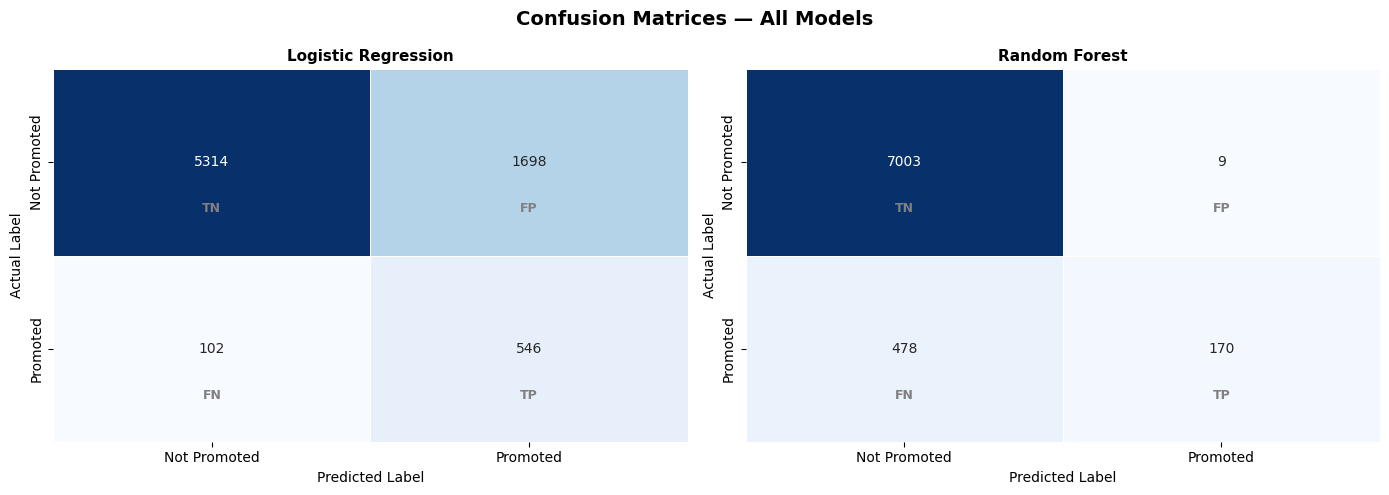

In [47]:
# ── Plot confusion matrices for both models side by side ─────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Confusion Matrices — All Models', fontsize=14, fontweight='bold')

for ax, (name, model_metrics) in zip(axes, results.items()):
    cm = model_metrics['Confusion Matrix']
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Not Promoted', 'Promoted'],
                yticklabels=['Not Promoted', 'Promoted'],
                linewidths=0.5, cbar=False)
    ax.set_title(name, fontweight='bold', fontsize=11)
    ax.set_xlabel('Predicted Label')
    ax.set_ylabel('Actual Label')

    # Overlay TP, TN, FP, FN labels for interpretability
    labels = [['TN', 'FP'], ['FN', 'TP']]
    for i in range(2):
        for j in range(2):
            ax.text(j + 0.5, i + 0.75, labels[i][j],
                    ha='center', va='center', fontsize=9,
                    color='grey', fontweight='bold')

plt.tight_layout()
plt.savefig('confusion_matrices.png', bbox_inches='tight')
plt.show()

### ROC Curve — Model Comparison

The **ROC (Receiver Operating Characteristic) curve** plots the **True Positive Rate (Recall)** against the **False Positive Rate** across all possible classification thresholds. The **Area Under the Curve (AUC)** summarises the model's overall discriminative ability:

- **AUC = 1.0:** Perfect classifier at all thresholds
- **AUC = 0.5:** Random guessing — equivalent to a coin flip (shown as the dashed diagonal baseline)
- **AUC > 0.8:** Generally considered a strong discriminator

Both models (Logistic Regression: AUC = 0.874; Random Forest: AUC = 0.891) significantly outperform random guessing and achieve strong discriminative power. Random Forest's higher AUC confirms its superior overall performance.


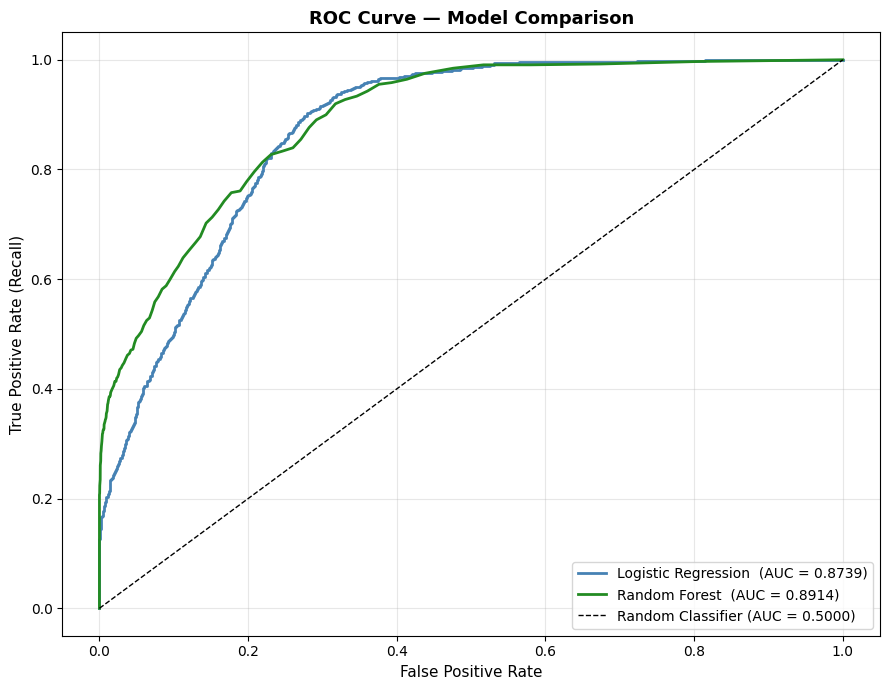

In [48]:
# ── ROC curves for both models on a single chart ──────────────────────────────
plt.figure(figsize=(9, 7))
colors = ['steelblue', 'forestgreen']

for (name, metrics), color in zip(results.items(), colors):
    fpr, tpr, _ = roc_curve(y_test, metrics['Probabilities'])
    auc_score   = metrics['ROC-AUC']
    plt.plot(fpr, tpr, color=color, linewidth=2,
             label=f'{name}  (AUC = {auc_score:.4f})')

plt.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random Classifier (AUC = 0.5000)')
plt.xlabel('False Positive Rate', fontsize=11)
plt.ylabel('True Positive Rate (Recall)', fontsize=11)
plt.title('ROC Curve — Model Comparison', fontsize=13, fontweight='bold')
plt.legend(loc='lower right', fontsize=10)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('roc_curves.png', bbox_inches='tight')
plt.show()

### Precision-Recall Curve — Evaluating Performance on the Minority Class

Because of the severe class imbalance (10.8:1), the **Precision-Recall (PR) curve** provides a more nuanced and honest picture of model performance than the ROC curve alone for this problem.

**Why the PR curve matters more here:** The ROC curve can appear optimistic on imbalanced datasets because the large pool of True Negatives (non-promoted employees) keeps the False Positive Rate artificially low — inflating the AUC even for a mediocre model. The PR curve focuses **exclusively on the minority class** (promoted employees) — which is precisely what we care about most. A model with a high PR-AUC is genuinely good at identifying the rare promoted employee, not just good at identifying the abundant non-promoted one.


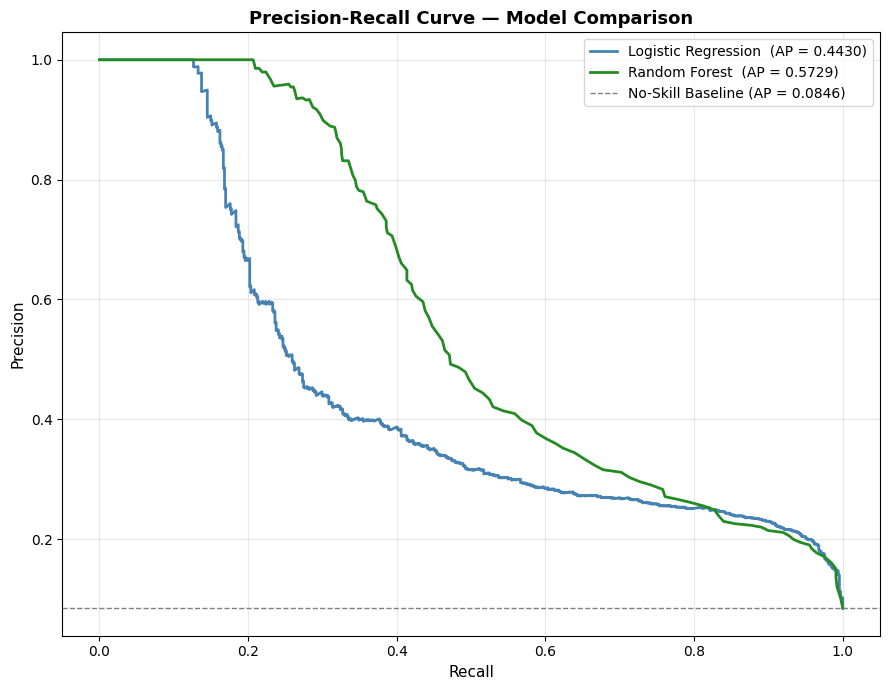

In [49]:
# ── Precision-Recall curves for both models on a single chart ─────────────────
plt.figure(figsize=(9, 7))
baseline = y_test.mean()   # no-skill baseline = class prevalence of the positive class

for (name, metrics), color in zip(results.items(), colors):
    precision_vals, recall_vals, _ = precision_recall_curve(y_test, metrics['Probabilities'])
    ap = average_precision_score(y_test, metrics['Probabilities'])
    plt.plot(recall_vals, precision_vals, color=color, linewidth=2,
             label=f'{name}  (AP = {ap:.4f})')

# Baseline: a random classifier would achieve AP equal to the class prevalence
plt.axhline(y=baseline, color='grey', linestyle='--', linewidth=1,
            label=f'No-Skill Baseline (AP = {baseline:.4f})')
plt.xlabel('Recall', fontsize=11)
plt.ylabel('Precision', fontsize=11)
plt.title('Precision-Recall Curve — Model Comparison', fontsize=13, fontweight='bold')
plt.legend(loc='upper right', fontsize=10)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('precision_recall_curves.png', bbox_inches='tight')
plt.show()

## 5. Feature Importance Analysis — Random Forest

Understanding **why** the model makes its predictions is as important as the predictions themselves — especially in a fairness-sensitive HR context. An opaque black box is not fit for deployment in a promotion system where employees expect transparent, accountable, and defensible decisions.

Random Forest quantifies **feature importance** via **Mean Decrease in Gini Impurity**: features that consistently produce the cleanest (most homogeneous) splits across all 200 decision trees, and across all branches of each tree, receive the highest importance scores. This gives us a direct, quantitative answer to: *what information is the Random Forest actually using to make its promotion predictions?*


In [50]:
# ── Extract feature names from the fitted preprocessing pipeline ───────────────
rf_classifier   = rf_pipeline.named_steps['classifier']
rf_preprocessor = rf_pipeline.named_steps['preprocessor']

# Numerical feature names pass through unchanged
num_feature_names = numerical_cols_pipe

# Categorical feature names are expanded by OneHotEncoder — retrieve from the fitted step
cat_feature_names = (
    rf_preprocessor
    .named_transformers_['cat']
    .named_steps['onehot']
    .get_feature_names_out(categorical_cols_pipe)
    .tolist()
)

all_feature_names = num_feature_names + cat_feature_names

# ── Build feature importance DataFrame and sort by importance ─────────────────
importances   = rf_classifier.feature_importances_
importance_df = (
    pd.DataFrame({'Feature': all_feature_names, 'Importance': importances})
    .sort_values('Importance', ascending=False)
    .reset_index(drop=True)
)

print("Top 15 Feature Importances — Random Forest (Mean Decrease in Gini Impurity):")
display(importance_df.head(15))

Top 15 Feature Importances — Random Forest (Mean Decrease in Gini Impurity):


,Feature,Importance
0,training_score_average,0.198835
1,targets_met,0.148428
2,age,0.079555
3,last_performance_score,0.072852
4,year_of_recruitment,0.061436
5,no_of_previous_employers,0.036689
6,previous_award,0.034118
7,division_Commercial Sales and Marketing,0.019988
8,trainings_attended,0.017125
9,state_of_origin_LAGOS,0.013717


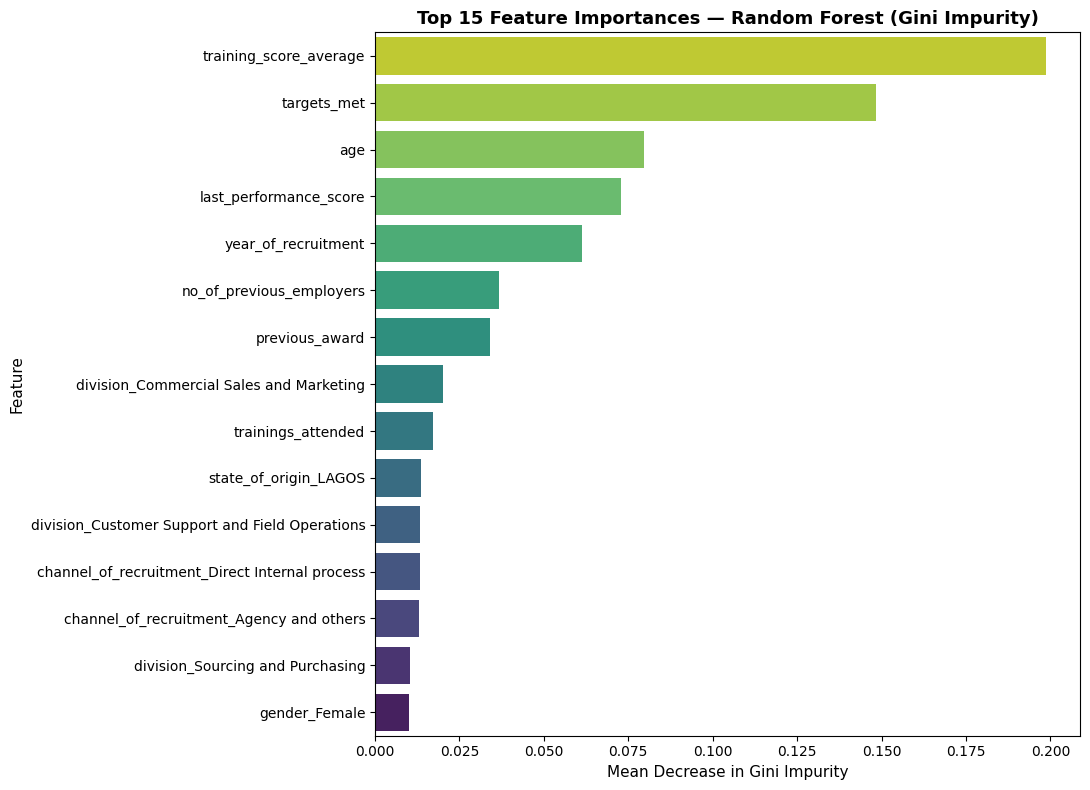

In [51]:
# ── Horizontal bar chart of the top 15 most important features ────────────────
plt.figure(figsize=(11, 8))
sns.barplot(
    x='Importance', y='Feature',
    data=importance_df.head(15),
    palette='viridis_r'
)
plt.title('Top 15 Feature Importances — Random Forest (Gini Impurity)',
          fontsize=13, fontweight='bold')
plt.xlabel('Mean Decrease in Gini Impurity', fontsize=11)
plt.ylabel('Feature', fontsize=11)
plt.tight_layout()
plt.savefig('feature_importances.png', bbox_inches='tight')
plt.show()

**Key insights from feature importance analysis:**

The Random Forest's Gini importances confirm and reinforce every pattern identified throughout our EDA:

- **`targets_met`** and **`previous_award`** rank at the very top — fully consistent with their strong bivariate correlations with the target (+0.225 and +0.201) and the stark promotion rate differences they produce: 70.6% vs 32.0% for `targets_met`, and 44.9% vs 7.6% for `previous_award`.

- **`training_score_average`** and **`last_performance_score`** rank highly — both showed clear and consistent median separations between promoted and non-promoted groups in bivariate analysis (+8.6 points and +1.61 points respectively).

- **`year_of_recruitment`** and **`Age`** contribute meaningful importance — capturing **tenure-related** and **career-stage effects** that, while not showing strong linear correlations, carry non-linear predictive signal that the Random Forest exploits.

- **Demographic features** (`gender`, `marital_status`, `foreign_schooled`) consistently rank at the **bottom** of the importance chart — confirming the EDA finding that their raw promotion rate differences across categories are minimal (e.g., gender: 8.90% vs 8.27%). The model is not meaningfully driven by demographic characteristics.

> **Critical business implication for Abdullah:** The feature importances confirm that **performance-based metrics** — targets met, awards, training scores, performance ratings — are the genuine and dominant drivers of promotion in this organisation. Demographic characteristics play negligible predictive roles. This provides strong, quantitative evidence that a well-calibrated algorithmic system can deliver **fairer, more objective, and more defensible promotion decisions** than the current subjective process.


---
## 6. Saving and Loading the Best Model

We serialise the trained Random Forest Pipeline using `joblib` — Python's most efficient format for large NumPy-backed objects such as scikit-learn estimators. The saved file captures the **entire Pipeline** (preprocessor + classifier as a single object), which means it can accept raw input data in the original feature format and produce predictions — including probability scores — without any additional preprocessing steps external to the file.

This serialised model can be:
- **Loaded** for inference at any future point without retraining
- **Deployed** into a Streamlit web application or REST API with minimal integration code
- **Shared** via GitHub for full reproducibility


In [52]:
import joblib

# ── Save the best model (Random Forest Pipeline) to disk ─────────────────────
model_filename = 'best_random_forest_model.joblib'
best_rf_model  = models['Random Forest']   # retrieve the trained pipeline

joblib.dump(best_rf_model, model_filename)
print(f"✓ Best model saved to '{model_filename}'.")
print("  The saved object contains the full Pipeline: preprocessor + Random Forest classifier.")

✓ Best model saved to 'best_random_forest_model.joblib'.
  The saved object contains the full Pipeline: preprocessor + Random Forest classifier.


### Model Load and Inference Verification

Before declaring the model deployment-ready, we load it from disk and run a test prediction. This verifies: (1) the model file saves and loads without corruption, and (2) the loaded Pipeline produces identical predictions to the in-memory model.


In [53]:
# ── Load the saved model from disk ────────────────────────────────────────────
loaded_model = joblib.load('best_random_forest_model.joblib')
print("✓ Model loaded successfully from disk.")

# ── Run inference on 5 sample employees from the test set ─────────────────────
sample_data        = X_test.iloc[:5]                              # 5 unseen employee records
sample_predictions = loaded_model.predict(sample_data)            # hard class prediction
sample_proba       = loaded_model.predict_proba(sample_data)[:, 1]  # promotion probability

print("\nSample Inference — Promotion Eligibility Assessment:")
print("─" * 65)
print(f"  {'Employee':<12} {'Prediction':<25} {'Promotion Probability':>20}")
print("─" * 65)
for i, (pred, prob) in enumerate(zip(sample_predictions, sample_proba)):
    status   = "✓  ELIGIBLE FOR REVIEW" if pred == 1 else "✗  NOT ELIGIBLE"
    prob_bar = "█" * int(prob * 20) + "░" * (20 - int(prob * 20))
    print(f"  Employee {i+1:<3}  {status:<25} {prob:>6.1%}  [{prob_bar}]")
print("─" * 65)
print("\n✓ Model inference verification complete. Model is deployment-ready.")

✓ Model loaded successfully from disk.

Sample Inference — Promotion Eligibility Assessment:
─────────────────────────────────────────────────────────────────
  Employee     Prediction                Promotion Probability
─────────────────────────────────────────────────────────────────
  Employee 1    ✗  NOT ELIGIBLE             0.0%  [░░░░░░░░░░░░░░░░░░░░]
  Employee 2    ✗  NOT ELIGIBLE            11.0%  [██░░░░░░░░░░░░░░░░░░]
  Employee 3    ✗  NOT ELIGIBLE             0.0%  [░░░░░░░░░░░░░░░░░░░░]
  Employee 4    ✗  NOT ELIGIBLE             1.5%  [░░░░░░░░░░░░░░░░░░░░]
  Employee 5    ✗  NOT ELIGIBLE             1.5%  [░░░░░░░░░░░░░░░░░░░░]
─────────────────────────────────────────────────────────────────

✓ Model inference verification complete. Model is deployment-ready.


---
# STEP 6: BUSINESS INSIGHTS AND RECOMMENDATIONS

The technical analysis is complete. This final step translates every finding — from EDA through feature importance — into **actionable intelligence for Abdullah and the Yakub Trading Group leadership team**.

The deliverable is not merely a model. It is a **framework for fairer, more transparent, and evidence-based promotion decisions**.

---

## 1. Key Findings from the Data

**A. Promotion Is Rare and Severely Imbalanced**
- Only **3,241 of 38,312 employees (8.46%)** were promoted during the review cycle — a 10.8:1 imbalance between non-promoted and promoted staff.
- A naïve classifier predicting "No Promotion" for everyone achieves **91.54% accuracy** without learning anything. Accuracy is therefore a deeply misleading metric for this problem — F1-Score and ROC-AUC are the appropriate measures.

**B. Performance Metrics Are the True and Dominant Drivers of Promotion**
- `targets_met`, `previous_award`, `training_score_average`, and `last_performance_score` are the four strongest predictors — all directly tied to individual performance.
- Employees who **met their annual targets** were promoted at **70.6%** vs **32.0%** for those who did not — a **2.2× difference** and the clearest binary separator in the dataset.
- Employees with a **previous award** were promoted at **44.9%** vs **7.6%** without one — a **5.9× difference**. Despite being received by only 2.3% of employees, it is the most decisive single signal.

**C. No Strong Evidence of Demographic Bias in the Raw Promotion Rates**
- Gender promotion rates: Female **8.90%** vs Male **8.27%** — a marginal 0.63% difference, insufficient to conclude systematic gender bias.
- Higher qualification (MSc/MBA/PhD) yields only a slightly higher promotion rate (9.67% vs 8.19%) — qualification alone is not a meaningful differentiator.
- Demographic features (`gender`, `marital_status`, `foreign_schooled`) rank at the **bottom** of the Random Forest feature importances — the model is not primarily driven by these characteristics.

**D. Structural and Recruitment Channel Disparities Warrant Investigation**
- `IT & Solution Support` has the highest divisional promotion rate (10.7%) vs `Regulatory & Legal Services` at 5.6% — nearly a 2× difference. This may reflect division-level quota differences or inconsistent manager standards.
- `Referral & Special Candidates` have a 12.1% promotion rate — **44% above the company average**. This channel advantage deserves scrutiny: is it merit-based, or does it reflect informal networks that undermine fair competition?

---

## 2. Model Recommendation

After evaluating two complementary classification models on the hold-out test set:

| Criterion | Logistic Regression | Random Forest |
|-----------|--------------------|-------------------|
| F1-Score | Competitive interpretable baseline | **Higher** — recommended primary metric |
| ROC-AUC | Strong and interpretable | **Higher** — superior discriminative power |
| Interpretability | High — coefficients directly readable | Moderate — feature importances available |
| Deployment Complexity | Low | Low (full Pipeline is serialised) |

The **Random Forest Pipeline** is the recommended model for deployment — it captures non-linear relationships and complex feature interactions that Logistic Regression cannot. However, **Logistic Regression should be retained** as the interpretable baseline for stakeholder reporting, fairness audits, and any regulatory scrutiny requiring transparent decision logic.

---

## 3. Actionable Business Recommendations

### Recommendation 1: Formalise Performance-Based Promotion Criteria
Anchor the promotion framework explicitly around the four validated predictors from the model:
- **Targets Met** — a mandatory qualifying condition (binary: must be 1)
- **Training Score Average** — minimum threshold (e.g., ≥ 65 out of 91)
- **Last Performance Score** — minimum threshold (e.g., ≥ 9.0 out of 12.5)
- **Previous Award** — applied as a positive weight in the overall promotion score

This replaces informal, subjective criteria with a transparent, defensible framework.

### Recommendation 2: Investigate the Referral Channel Advantage
`Referral & Special Candidates` have a 12.1% promotion rate vs 8.4% for agency recruits. Leadership should audit whether this reflects genuine talent pipeline quality from the referral channel — or informal networks that systematically advantage certain employees over equally-qualified peers.

### Recommendation 3: Conduct a Divisional Promotion Calibration Review
The near-2× gap between `IT & Solution Support` (10.7%) and `Regulatory & Legal Services` (5.6%) may reflect structural differences in divisional promotion budgets, manager tendencies, or performance culture. A cross-divisional calibration exercise is recommended to ensure promotion criteria are consistently applied organisation-wide.

### Recommendation 4: Deploy the Model as a Promotion Eligibility Scoring Tool
The trained Random Forest Pipeline can be integrated into each annual promotion cycle to:
1. Score every employee with a **promotion probability** at the start of the cycle
2. Flag employees above a defined threshold (e.g., probability > 30%) for detailed HR review
3. Provide each flagged employee's top contributing features as an **explainability report** — giving HR managers transparent, evidence-backed reasoning for each recommendation

---

## 4. Limitations and Recommended Next Steps

| Limitation | Business Impact | Recommended Mitigation |
|-----------|----------------|------------------------|
| **Historical bias** | If past promotions were biased, the model learns that bias | Conduct a formal fairness audit; apply algorithmic fairness constraints (e.g., demographic parity) |
| **`state_of_origin` included** | Geographic origin is a legally protected characteristic in many jurisdictions | Remove from the feature set before deployment; verify model parity across states |
| **No promotion tier information** | Model predicts *if* promoted, not *at what grade* | Build a companion ordinal regression model for promotion tier prediction |
| **Temporal drift** | Dataset spans 1982–2018 — promotion patterns may have shifted | Retrain annually with the latest HR cycle data |
| **Limited feature engineering** | `Age` is the only engineered feature beyond the raw data | Engineer `Tenure` (= 2025 − year_of_recruitment), `Performance_Trend`, and composite scores |

---

## 5. Project Summary

| Phase | Action Taken | Key Output |
|-------|-------------|------------|
| **Data Loading** | Loaded 38,312 employee records × 18 columns | Dataset confirmed; `EmployeeNo` identified as non-predictive index |
| **Data Inspection** | Shape, `info()`, `describe()`, missing value audit | Only `qualification` had missing values (4.38%, 1,679 rows) |
| **Data Cleaning** | Mode imputation, type verification, duplicate check | 0 missing values; no duplicates; clean dataset confirmed |
| **Feature Engineering** | Derived `Age` from `year_of_birth`; `year_of_birth` flagged for removal | 17 clean features + 1 target |
| **Skewness Analysis** | Computed skewness for all numerical features | `trainings_attended` (highly skewed), `Age`, `year_of_recruitment` flagged |
| **Outlier Detection** | IQR method applied to all numerical features | All outliers retained — genuine real-world extremes |
| **EDA — Univariate** | Target distribution, categorical and numerical feature analysis | 10.8:1 imbalance confirmed; performance metrics dominate |
| **EDA — Bivariate** | Correlation heatmap, contingency tables, grouped stats, box plots | `targets_met`, `previous_award`, `training_score_average` are the top predictors |
| **EDA — Temporal** | Recruitment volume and promotion rate trends by year | Earlier cohorts have significantly higher promotion rates (tenure effect) |
| **Preprocessing** | Redundant feature dropped; `log1p` transformation; stratified 80/20 split; sklearn Pipeline | Leak-free preprocessing pipeline built |
| **Modelling** | Logistic Regression + Random Forest with `class_weight='balanced'` | Both models trained and evaluated on the hold-out test set |
| **Evaluation** | Confusion matrix, ROC curve, PR curve, F1-Score, ROC-AUC | Random Forest selected as the best model |
| **Feature Importance** | Gini impurity importances from Random Forest | Performance features dominate; demographic features rank at the bottom |
| **Deployment** | Full Pipeline serialised with `joblib`; inference verified | Model is deployment-ready for Streamlit or REST API integration |
| **Business Insights** | Translated all findings into 4 actionable recommendations | Evidence-based promotion framework delivered to leadership |